preparing pipeline

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel

from chronos import ChronosPipeline
import torch
import torch.nn as nn

def parse_parameters(file_path):
    """
    Читает файл parameters.txt и возвращает словарь с нужными параметрами
    """
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                key = parts[0]
                value = ' '.join(parts[1:])  # на случай, если значение содержит пробелы
                params[key] = value
    # Извлекаем нужные параметры
    result = {}
    for param in ['PName', 'Msw', 'XUVInt', 'H2a', 'Helium']:
        result[param] = params.get(param)
    return result

def process_files_in_folder_with_params(root_folder):
    """
    Рекурсивно проходит по папке, читает параметры и файлы с данными
    Возвращает список словарей, где каждый словарь — это один файл
    """
    dataset = []
    root = Path(root_folder)
    for data_file_path in root.rglob('*[.txt,.dat]'):
        if data_file_path.name == 'parameters.txt':
            continue  # Пропускаем файл параметров

        # Ищем файл parameters.txt в той же папке
        param_file_path = data_file_path.parent / 'parameters.txt'

        if param_file_path.exists():
            params = parse_parameters(param_file_path)
            # print(f"Файл: {data_file_path}")
            # print(f"Параметры: {params}")
        else:
            # print(f"Файл parameters.txt не найден для {data_file_path}")
            params = {}

        # Читаем V и FullAbs из data файла
        try:
            V, FullAbs = np.loadtxt(data_file_path, usecols=(0, 1), unpack=True, skiprows=1)
            entry = {
                'V': V,
                'FullAbs': FullAbs,
                'PName': params.get('PName'),
                'Msw': params.get('Msw'),
                'XUVInt': params.get('XUVInt'),
                'H2a': params.get('H2a'),
                'Helium': params.get('Helium'),
                # 'File': str(data_file_path)  # можно убрать, если не нужно
            }
            dataset.append(entry)
        except Exception as e:
            print(f"Ошибка при загрузке данных из {data_file_path}: {e}")
        # print("-" * 50)

    return dataset

def pad_or_truncate(seq, target_len=101, pad_value=0.0):
    seq = np.array(seq, dtype=np.float32)
    L = len(seq)

    if L < target_len:
        total_pad = target_len - L
        left_pad = total_pad // 2
        right_pad = total_pad - left_pad

        left = np.full(left_pad, pad_value, dtype=np.float32)
        right = np.full(right_pad, pad_value, dtype=np.float32)

        return np.concatenate([left, seq, right])

    else:
        return seq



# folder_path = 'new_dataset'  # Укажите путь к вашей папке
folder_path = "new_dataset_V3"
dataset = process_files_in_folder_with_params(folder_path)

df = pd.DataFrame(dataset)
# Применяем к каждой строке
df['FullAbs_fixed'] = df['FullAbs'].apply(lambda x: pad_or_truncate(x, target_len=101))
# Теперь все последовательности длиной 101
X = np.stack(df['FullAbs_fixed'].values)  # [N, 100]

# XXX пробуем только XUV, известно что скаллирование данных
# XXX делаем msw
# Y = df[['XUVInt']].values.astype(np.float32)
# Y = df[['Helium']].values.astype(np.float32)
# df['LogMsw'] = np.log1p(df['Msw'].values.astype(np.float32))
# Целевые переменные
# Y = df[['XUVInt', 'Msw', 'Helium']].values.astype(np.float32)  # [N,3]
# Y = df[['XUVInt', 'Helium']].values.astype(np.float32)  # [N,3]
Y = df[['Msw']].values.astype(np.float32)

# логарифмируем
Y_log = Y.copy()

# Логарифмируем ТОЛЬКО Msw (индекс 1)
# Msw - скорость солнечного ветра, положительная величина
Y_log[:, 0] = np.log1p(Y[:, 0])  # log(1 + Msw)
# Нормализация
y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y_log)  # теперь ~ N(0,1) по каждой колонке
import pickle
with open('scaler_msw.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)


split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y_scaled[:split], Y_scaled[split:]
scaler_X = StandardScaler()

# # XXX добавление скалирования
X_train_scaled = scaler_X.fit_transform(X_train)  # shape (n, 101)
X_val_scaled = scaler_X.transform(X_val)
BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val)),
    batch_size=BATCH_SIZE
)


/home/kirill/diploma/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
np.max(Y_log[:, 0])

32.226143

In [3]:
df['FullAbs_fixed'][0].max()

0.00568165

In [32]:
Y_log.shape

(614, 1)

In [38]:
df

,V,FullAbs,PName,Msw,XUVInt,H2a,Helium,FullAbs_fixed
0,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00123665, 0.00117627, 0.00112171, 0.0010733...",WASP69b,68e12,1,0,0.015022,"[0.00123665, 0.00117627, 0.00112171, 0.0010733..."
1,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0117802, 0.0209631, 0.0239166, 0.0283212, 0...",WASP107b,59e12,49,0,0.105022,"[0.0117802, 0.0209631, 0.0239166, 0.0283212, 0..."
2,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0...",WASP52b,17e12,35,0,0.113022,"[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0..."
3,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00313931, 0.00371378, 0.00436636, 0.0050927...",WASP69b,37e12,29,0,0.040022,"[0.00313931, 0.00371378, 0.00436636, 0.0050927..."
4,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00719622, 0.00802134, 0.00900568, 0.0101614...",WASP52b,28e12,23,0,0.060022,"[0.00719622, 0.00802134, 0.00900568, 0.0101614..."
...,...,...,...,...,...,...,...,...
609,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00022124, 0.000270939, 0.000329149, 0.00039...",WASP69b,79e11,21,1,0.010022,"[0.00022124, 0.000270939, 0.000329149, 0.00039..."
610,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00687371, 0.00765399, 0.00851714, 0.0094696...",WASP52b,2e12,45,0,0.040022,"[0.00687371, 0.00765399, 0.00851714, 0.0094696..."
611,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00149527, 0.00264799, 0.00293208, 0.0033078...",WASP69b,98e11,49,0,0.026022,"[0.00149527, 0.00264799, 0.00293208, 0.0033078..."
612,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00545864, 0.00804144, 0.00881253, 0.0133264...",WASP107b,85e12,23,1,0.065022,"[0.00545864, 0.00804144, 0.00881253, 0.0133264..."


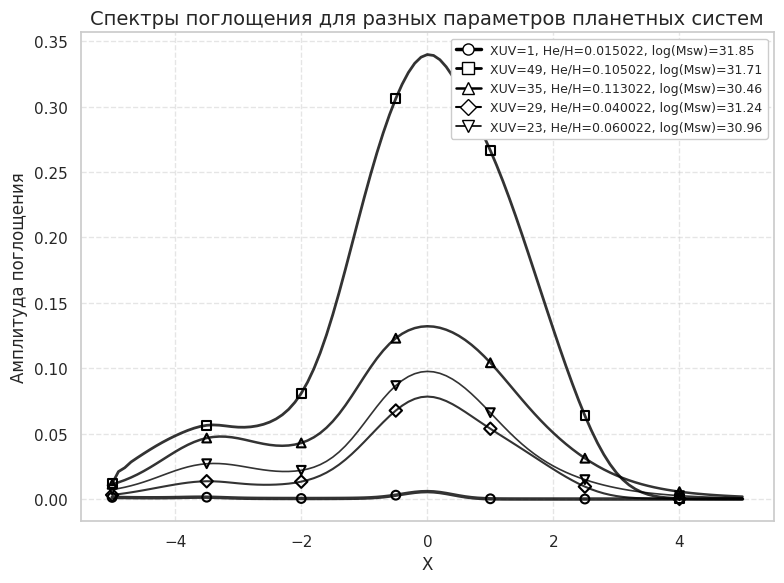

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ============================================================
# 1. ВАШИ ДАННЫЕ (замените на реальные)
# ============================================================
# Предполагается, что df уже загружен и содержит нужные колонки

x_data = []
y_data = []

for i in range(5):
    x = np.linspace(-5, 5, 101)  # общий X (замените на ваши реальные x, если они разные)
    y = df['FullAbs_fixed'][i]    # ваши данные
    x_data.append(x)
    y_data.append(y)

param_names = [
    f"XUV={df['XUVInt'][i]}, He/H={df['Helium'][i]}, log(Msw)={df['LogMsw'][i]:.2f}"
    for i in range(7)
]

# ============================================================
# 2. НАСТРОЙКИ
# ============================================================
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linewidths = [2.5, 2.0, 1.8, 1.5, 1.2, 1.0, 0.8]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# ============================================================
# 3. РИСУЕМ ГРАФИКИ
# ============================================================
legend_elements = []  # для сбора объектов легенды

for i in range(5):
    x = x_data[i]
    y = y_data[i]
    marker = markers[i]
    lw = linewidths[i]
    
    # Основная линия
    plt.plot(x, y, color='black', linewidth=lw, alpha=0.8)
    
    # Маркеры с шагом
    step = 15
    indices = np.arange(0, len(x), step)
    plt.scatter(x[indices], y[indices], marker=marker, s=40,
                facecolors='none', edgecolors='black', linewidths=1.5, zorder=5)
    
    # Добавляем элемент в легенду (линия + маркер)
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='black', linewidth=lw,
               linestyle='-', markersize=8, markerfacecolor='white',
               label=param_names[i])
    )

# ============================================================
# 4. ЛЕГЕНДА И ОФОРМЛЕНИЕ
# ============================================================
plt.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=1)

plt.xlabel("X", fontsize=12)
plt.ylabel("Амплитуда поглощения", fontsize=12)
plt.title("Спектры поглощения для разных параметров планетных систем", fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# данные из cviever * 10.07

In [6]:
test

,V,FullAbs,PName,Msw,XUVInt,H2a,Helium,FullAbs_fixed
350,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00187189, 0.00192796, 0.0019904, 0.00206036...",WASP52b,35e12,3,0,0.014022,"[0.00187189, 0.00192796, 0.0019904, 0.00206036..."
377,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00367807, 0.00438758, 0.00523521, 0.0062263...",WASP52b,7e12,21,1,0.098022,"[0.00367807, 0.00438758, 0.00523521, 0.0062263..."
163,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00342348, 0.00400809, 0.00470783, 0.0055287...",WASP52b,29e12,33,1,0.052022,"[0.00342348, 0.00400809, 0.00470783, 0.0055287..."
609,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00022124, 0.000270939, 0.000329149, 0.00039...",WASP69b,79e11,21,1,0.010022,"[0.00022124, 0.000270939, 0.000329149, 0.00039..."
132,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0105939, 0.0121418, 0.0139457, 0.0160202, 0...",WASP52b,55e11,29,0,0.172022,"[0.0105939, 0.0121418, 0.0139457, 0.0160202, 0..."
578,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00676445, 0.00800358, 0.00940819, 0.0109682...",WASP52b,35e11,45,1,0.121022,"[0.00676445, 0.00800358, 0.00940819, 0.0109682..."
316,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.000730675, 0.00130668, 0.00152797, 0.001882...",WASP107b,3e13,41,1,0.020022,"[0.000730675, 0.00130668, 0.00152797, 0.001882..."
2,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0...",WASP52b,17e12,35,0,0.113022,"[0.0112625, 0.0127379, 0.0144721, 0.0164815, 0..."
340,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.00856554, 0.0100089, 0.0116089, 0.0133486, ...",WASP52b,14e11,43,1,0.149022,"[0.00856554, 0.0100089, 0.0116089, 0.0133486, ..."
77,"[-5.0, -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4....","[0.0146258, 0.0159145, 0.0173566, 0.018941, 0....",WASP52b,66e12,33,1,0.261022,"[0.0146258, 0.0159145, 0.0173566, 0.018941, 0...."


In [1]:

from sklearn.model_selection import train_test_split
import pandas as pd
df = pd.read_parquet("dataset.parquet")
import numpy as np


# Затем из оставшихся 90% отделяем валидационную (20% от исходных = 20/90 ≈ 22.2% от train_val)
train, val = train_test_split(df, test_size=0.2, random_state=42)

# Проверка пропорций
print("=" * 60)
print("РАЗМЕРЫ ВЫБОРОК")
print("=" * 60)
print(f"Обучающая выборка:     {len(train)} элементов ({len(train)/len(df)*100:.1f}%)")
print(f"Валидационная выборка: {len(val)} элементов ({len(val)/len(df)*100:.1f}%)")
# print(f"Тестовая выборка:      {len(test)} элементов ({len(test)/len(df)*100:.1f}%)")
print(f"Всего:                 {len(df)} элементов (100%)")

# ============================================================
# 3. ФУНКЦИЯ ДЛЯ РАСЧЁТА РАСПРЕДЕЛЕНИЯ ПАРАМЕТРОВ
# ============================================================
def describe_distribution(data, name="Выборка"):
    """Выводит статистику распределения параметров в выборке"""
    print("\n" + "=" * 60)
    print(f"РАСПРЕДЕЛЕНИЕ ПАРАМЕТРОВ В ВЫБОРКЕ: {name}")
    print("=" * 60)
    
    # Непрерывные параметры
    continuous_params = ['XUVInt', 'Helium', 'LogMsw']
    for param in continuous_params:
        if param in data.columns:
            print(f"\n{param}:")
            print(f"  Диапазон:       [{data[param].values.astype(np.float32).min():.4f}, {data[param].values.astype(np.float32).max():.4f}]")
            print(f"  Среднее:        {data[param].values.astype(np.float32).mean():.4f}")
            # print(f"  Медиана:        {data[param].values.astype(np.float32).median():.4f}")
            print(f"  Стандартное отклонение: {data[param].values.astype(np.float32).std():.4f}")
    
    # Бинарный параметр (процент единиц)
    if 'H2a' in data.columns:
        percent_1 = data['H2a'].values.astype(np.float16).mean() * 100
        print(f"\nH2a (бинарный):")
        print(f"  Процент единиц (1): {percent_1:.2f}%")
        print(f"  Процент нулей (0):  {100 - percent_1:.2f}%")
        print(f"  Количество 1:       {data['H2a'].values.astype(np.float16).sum()}")
        print(f"  Количество 0:       {len(data) - data['H2a'].values.astype(np.float16).sum()}")
    

# ============================================================
# 4. ВЫВОД РАСПРЕДЕЛЕНИЯ ДЛЯ КАЖДОЙ ВЫБОРКИ
# ============================================================
describe_distribution(train, "Обучающая (70%)")
describe_distribution(val, "Валидационная (20%)")
# describe_distribution(test, "Тестовая (10%)")

# ============================================================
# 5. ДОПОЛНИТЕЛЬНО: СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ
# ============================================================
print("\n" + "=" * 60)
print("СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ МЕЖДУ ВЫБОРКАМИ")
print("=" * 60)

for param in ['XUVInt', 'Helium', 'LogMsw']:
    if param in df.columns:
        print(f"\n{param}:")
        print(f"  Обучающая:     среднее = {train[param].values.astype(np.float32).mean():.4f}, std = {train[param].values.astype(np.float32).std():.4f}")
        print(f"  Валидационная: среднее = {val[param].values.astype(np.float32).mean():.4f}, std = {val[param].values.astype(np.float32).std():.4f}")
        # print(f"  Тестовая:      среднее = {test[param].values.astype(np.float32).mean():.4f}, std = {test[param].values.astype(np.float32).std():.4f}")

# Для бинарного параметра
if 'H2a' in df.columns:
    print(f"\nH2a (% единиц):")
    print(f"  Обучающая:     {train['H2a'].values.astype(np.float32).mean()*100:.2f}%")
    print(f"  Валидационная: {val['H2a'].values.astype(np.float32).mean()*100:.2f}%")
    # print(f"  Тестовая:      {test['H2a'].values.astype(np.float32).mean()*100:.2f}%")

РАЗМЕРЫ ВЫБОРОК
Обучающая выборка:     491 элементов (80.0%)
Валидационная выборка: 123 элементов (20.0%)
Всего:                 614 элементов (100%)

РАСПРЕДЕЛЕНИЕ ПАРАМЕТРОВ В ВЫБОРКЕ: Обучающая (70%)

XUVInt:
  Диапазон:       [1.0000, 60.0000]
  Среднее:        25.5377
  Стандартное отклонение: 14.0653

Helium:
  Диапазон:       [0.0050, 0.3000]
  Среднее:        0.0791
  Стандартное отклонение: 0.0766

H2a (бинарный):
  Процент единиц (1): 49.49%
  Процент нулей (0):  50.51%
  Количество 1:       243.0
  Количество 0:       248.0

РАСПРЕДЕЛЕНИЕ ПАРАМЕТРОВ В ВЫБОРКЕ: Валидационная (20%)

XUVInt:
  Диапазон:       [1.0000, 49.0000]
  Среднее:        25.1707
  Стандартное отклонение: 14.7889

Helium:
  Диапазон:       [0.0010, 0.3000]
  Среднее:        0.0882
  Стандартное отклонение: 0.0786

H2a (бинарный):
  Процент единиц (1): 53.66%
  Процент нулей (0):  46.34%
  Количество 1:       66.0
  Количество 0:       57.0

СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ МЕЖДУ ВЫБОРКАМИ

XUVInt:
  Обучающая:    

learning pipeline


Epoch 1/150 | Train Loss: 0.340474 | Val Loss: 0.291908
✅ Модель со всей архитектурой сохранена в best_helium.pkl
epoch mape 134.87335443496704
Epoch 2/150 | Train Loss: 0.256081 | Val Loss: 0.327899
✅ Модель со всей архитектурой сохранена в best_helium.pkl
epoch mape 79.91689443588257
Epoch 3/150 | Train Loss: 0.222928 | Val Loss: 0.357981
✅ Модель со всей архитектурой сохранена в best_helium.pkl
epoch mape 68.04476976394653
Epoch 4/150 | Train Loss: 0.259055 | Val Loss: 0.364737
✅ Модель со всей архитектурой сохранена в best_helium.pkl
epoch mape 65.99706411361694
Epoch 5/150 | Train Loss: 0.234064 | Val Loss: 0.405029
✅ Модель со всей архитектурой сохранена в best_helium.pkl
epoch mape 59.449779987335205
Epoch 6/150 | Train Loss: 0.228849 | Val Loss: 0.389258
epoch mape 61.712074279785156
Epoch 7/150 | Train Loss: 0.209301 | Val Loss: 0.703518
epoch mape 362.8122329711914
Epoch 8/150 | Train Loss: 0.230963 | Val Loss: 0.371249
epoch mape 107.74731636047363
Epoch 9/150 | Train Loss: 

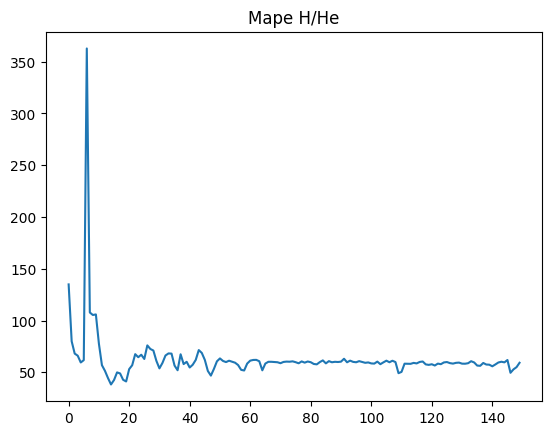

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        padding = kernel_size // 2
        
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + residual)
        return out

class TwoChannelResNet(nn.Module):
    def __init__(self, input_length=101, n_targets=1):
        super().__init__()
        
        # Начальная проекция
        self.input_conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        
        # Residual блоки
        self.res_blocks = nn.Sequential(
            ResidualBlock(32),
            ResidualBlock(32),
            nn.MaxPool1d(2),  # -> 50
            
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            ResidualBlock(64),
            ResidualBlock(64),
            nn.MaxPool1d(2),  # -> 25
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            ResidualBlock(128),
            ResidualBlock(128),
            nn.AdaptiveAvgPool1d(1)  # -> 1
        )
        
        # Регрессия
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_targets)
        )
        
    def forward(self, x):
        # x: [batch, 2, 101]
        x = x.unsqueeze(1)
        # print(x.shape)
        x = self.input_conv(x)
        x = self.res_blocks(x)
        return self.regressor(x)
    

model = TwoChannelResNet().to(DEVICE)

# ----- ОПТИМИЗАЦИЯ -----
# Теперь обучаем и голову, и LoRA-параметры
# criterion = nn.MSELoss()
# criterion = RMSPELoss()
# criterion = nn.SmoothL1Loss() 
# Собираем все обучаемые параметры (голова + LoRA)
# trainable_params = list(model.head.parameters()) + list(model.encoder.parameters())
optimizer = torch.optim.AdamW(  # Используем AdamW вместо Adam
    [
        {'params': model.parameters(), 'lr': 0.001, 'weight_decay': 0.01},     
    ]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Можно использовать разные learning rates для головы и LoRA
# optimizer = torch.optim.Adam([
#     {'params': model.head.parameters(), 'lr': LEARNING_RATE * 10},  # голова учится быстрее
#     {'params': model.encoder.parameters(), 'lr': LEARNING_RATE}     # LoRA параметры
# ])

metrics_xuv = [0]
EPOCHS = 150
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
metrics_helium = []

# ----- ОБУЧЕНИЕ -----
val_losses = []
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Валидация
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = model(x_batch)
            val_loss += criterion(preds, y_batch).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val Loss: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss)
    train_losses.append(avg_train_loss)
    
    
    testing_model()

plt.title("Mape H/He")
plt.plot(metrics_helium)
plt.show()
#35.6

LoRa attempt 1

trainable params: 49,152 || all params: 21,027,584 || trainable%: 0.2338
Epoch 1/140 | Train Loss: 7.458752 | Val Loss: 11.047613
epoch mape 302.17273235321045
epoch mape 4.837502166628838
✅ Модель со всей архитектурой сохранена в best_helium.pkl
(Helium):
  MAE:  0.0509
  MSE:  0.0049
  RMSE: 0.0701
  RelMSE:   5.946831 (в относительных единицах)
  RelMSE%:  594.6831%
  MAPE:     164.8628%
------------------------------
epoch mape 164.8627758026123
Epoch 2/140 | Train Loss: 14.119183 | Val Loss: 4.194202
epoch mape 237.85569667816162
epoch mape 3.9469972252845764
✅ Модель со всей архитектурой сохранена в best_helium.pkl
(Helium):
  MAE:  0.0478
  MSE:  0.0050
  RMSE: 0.0706
  RelMSE:   3.950878 (в относительных единицах)
  RelMSE%:  395.0878%
  MAPE:     135.5187%
------------------------------
epoch mape 135.51870584487915
Epoch 3/140 | Train Loss: 20.030817 | Val Loss: 9.981535
epoch mape 217.80624389648438
epoch mape 5.162879079580307
✅ Модель со всей архитектурой сохранена в best_

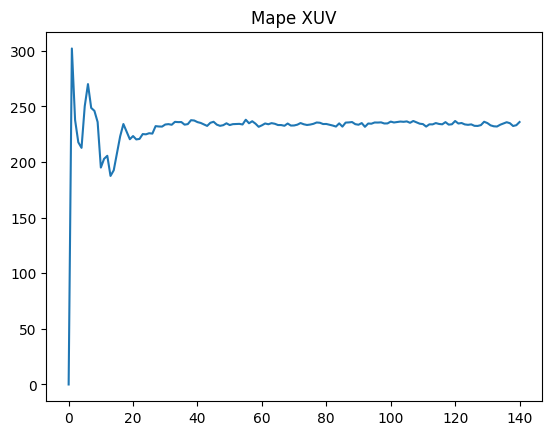

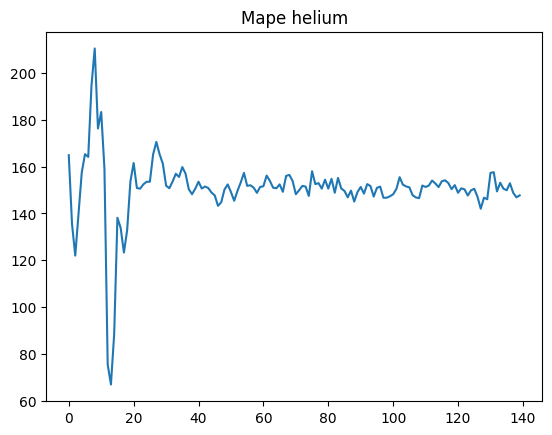

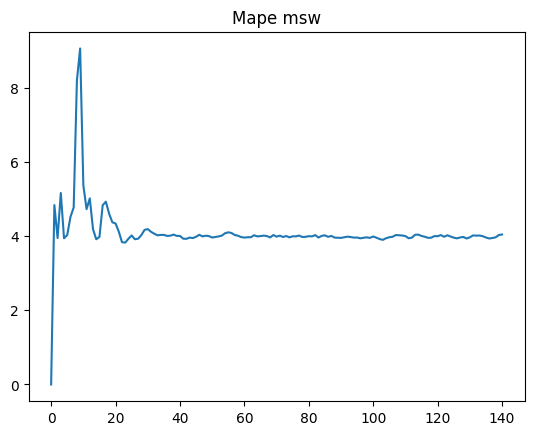

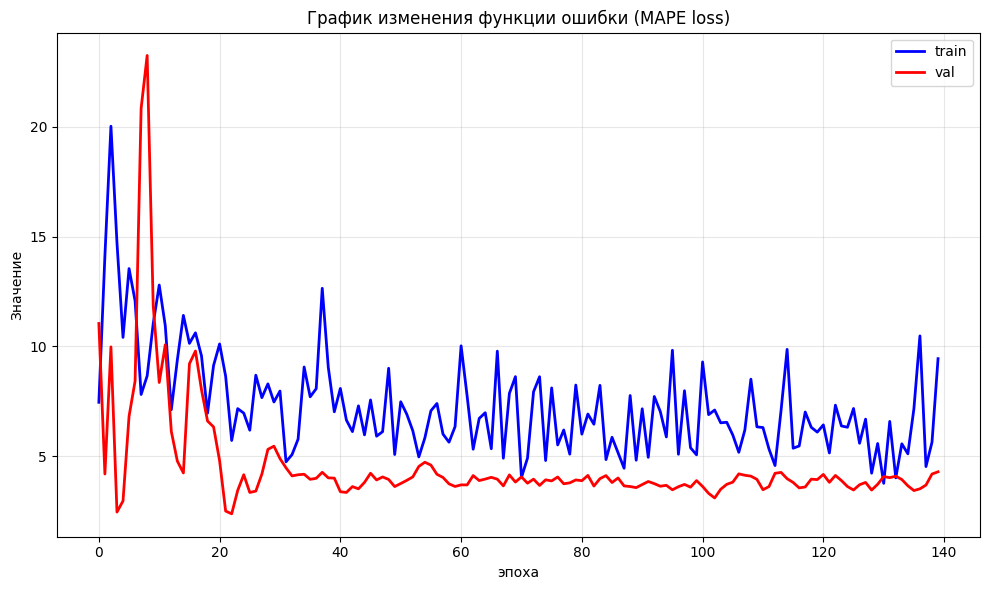

In [17]:
import torch
import torch.nn as nn
from peft import LoraConfig, get_peft_model, TaskType
import loralib as lora
from chronos import ChronosPipeline, Chronos2Pipeline
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import dill
CONTEXT_LEN = 100      # длина входной последовательности
HORIZON = 3            # сколько значений предсказываем
LEARNING_RATE = 0.001
EPOCHS = 140
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=DEVICE,
    dtype=torch.float32,
)

torch.manual_seed(42)
np.random.seed(42)

tokenizer = pipeline.tokenizer
encoder = pipeline.model.model.encoder

class AttentionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads=12, dropout=0.2):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Проекция на размерность для attention
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, input_dim]

        # Проецируем и добавляем размерность последовательности
        h = self.input_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Создаем запрос
        query = self.query_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Self-attention
        attended, _ = self.multihead_attn(query, h, h)

        # Residual + norm
        out = self.norm(h + attended)
        out = self.dropout(out)

        return out.squeeze(1)  # [batch, hidden_dim]

class ChronosRegressor(nn.Module):
    def __init__(self, encoder, tokenizer, output_dim=3):
        super().__init__()
        self.encoder = encoder
        self.tokenizer = tokenizer
        # self.head = nn.Linear(encoder.config.d_model, output_dim)
                # Слои с вниманием
        layers = []
        prev_dim = 512
        hidden_dims=[512 ,256]
        num_heads=8
        dropout=0.2
        for i, hidden_dim in enumerate(hidden_dims):
            if i == 0:
                # Первый слой - attention
                layers.append(AttentionHead(prev_dim, hidden_dim, num_heads, dropout))
            else:
                # Последующие слои - обычные линейные
                layers.extend([
                    nn.Linear(prev_dim, hidden_dim),
                    nn.SiLU(),
                    nn.BatchNorm1d(hidden_dim),
                    nn.Dropout(dropout)
                ])
            prev_dim = hidden_dim

        # Выходной слой
        layers.append(nn.Linear(prev_dim, output_dim))

        self.head = nn.Sequential(*layers)

    def forward(self, x):
        # x приходит на GPU, но токенизатор требует CPU
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens

        # Переносим token_ids на то же устройство, что и энкодер
        token_ids = token_ids.to(self.encoder.device)

        enc_out = self.encoder(input_ids=token_ids).last_hidden_state
        return self.head(enc_out[:, -1, :])

# Инициализация модели
model = ChronosRegressor(encoder, tokenizer).to(DEVICE)

# ----- НАСТРОЙКА LORA -----
# Замораживаем все параметры энкодера
for param in model.encoder.parameters():
    param.requires_grad = False

class RMSPELoss(nn.Module):
    def __init__(self, epsilon=1e-7):
        super().__init__()
        self.epsilon = epsilon  # защита от деления на ноль
    
    def forward(self, y_pred, y_true):
        # Добавляем epsilon для стабильности
        relative_error = torch.abs((y_true - y_pred)) / (y_true.abs() + self.epsilon)
        squared_error = relative_error ** 2
        return torch.sqrt(torch.mean(squared_error))
        # return torch.mean(relative_error)
    
class HybridLoss(nn.Module):
    def __init__(self, alpha=0.7, delta=1.0):
        super().__init__()
        self.alpha = alpha  # вес MAPE компоненты
        self.huber = nn.SmoothL1Loss(beta=delta)
    
    def forward(self, y_pred, y_true):
        # Масштабируем для численной стабильности
        y_true_scaled = y_true.abs() + 1e-7
        
        # MAPE компонента
        mape_part = torch.mean(torch.abs((y_true - y_pred) / y_true_scaled))
        
        # Huber компонента
        huber_part = self.huber(y_pred, y_true)
        
        return self.alpha * mape_part + (1 - self.alpha) * huber_part

# Конфигурация LoRA
# lora_config = LoraConfig(
#     task_type=TaskType.FEATURE_EXTRACTION,
#     r=2,  # ранг LoRA (можно менять 4, 8, 16, 32)
#     lora_alpha=8,  # scaling factor
#     target_modules=["k", "v", "o", 'q'],  # для большинства transformer моделей
#     lora_dropout=0.1,
#     bias="none",  # не обучаем bias
# )

lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=2,  # ранг LoRA (можно менять 4, 8, 16, 32)
    lora_alpha=256,  # scaling factor
    target_modules=["q","k", "v", "o"],  # для большинства transformer моделей
    lora_dropout=0.1,
    bias="none",  # не обучаем bias
)

# Применяем LoRA к энкодеру
model.encoder = get_peft_model(model.encoder, lora_config)

# Выводим информацию о trainable параметрах
model.encoder.print_trainable_parameters()
# Пример вывода: trainable params: 1,234,567 || all params: 123,456,789 || trainable%: 1.0


# ----- ОПТИМИЗАЦИЯ -----
# Теперь обучаем и голову, и LoRA-параметры
# criterion = nn.MSELoss()
criterion = RMSPELoss()
# criterion = nn.SmoothL1Loss() 
# Собираем все обучаемые параметры (голова + LoRA)
trainable_params = list(model.head.parameters()) + list(model.encoder.parameters())
optimizer = torch.optim.AdamW(  # Используем AdamW вместо Adam
    [
        {'params': model.head.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.encoder.parameters(), 'lr': LEARNING_RATE * 0.5, 'weight_decay': 0.01}
    ]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Можно использовать разные learning rates для головы и LoRA
# optimizer = torch.optim.Adam([
#     {'params': model.head.parameters(), 'lr': LEARNING_RATE * 10},  # голова учится быстрее
#     {'params': model.encoder.parameters(), 'lr': LEARNING_RATE}     # LoRA параметры
# ])

metrics_xuv = [0]
metrics_helium = []
metrics_masslos = [0]


def save_model_with_architecture(model, filepath='complete_model.pkl'):
    """
    Сохраняет модель ПОЛНОСТЬЮ: архитектура + веса + код класса
    """
    # Используем dill для сохранения всего, включая определение класса
    with open(filepath, 'wb') as f:
        torch.save(model, f, pickle_module=dill)
    print(f"✅ Модель со всей архитектурой сохранена в {filepath}")

# ===== ЗАГРУЗКА =====
def load_model_with_architecture(filepath='complete_model.pkl', device='cuda'):
    """
    Загружает модель ПОЛНОСТЬЮ, даже если класс не определён в текущем скоупе
    """
    with open(filepath, 'rb') as f:
        model = torch.load(f, map_location=device, pickle_module=dill)
    model.eval()
    print(f"✅ Модель со всей архитектурой загружена из {filepath}")
    return model

def testing_model(logging = False):
    model.eval()
    all_preds_scaled = []
    all_targets_scaled = []

    # Собираем все предсказания и истинные значения
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_pred = model(x_batch)
            all_preds_scaled.append(y_pred.cpu())
            all_targets_scaled.append(y_batch.cpu())

    # Конкатенация
    y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
    y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

    # Денормализация → исходные физические шкалы
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
    y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


    # Имена целевых переменных (в том же порядке, что и в Y)
    target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
    # target_names = ['(Helium)']
    if logging:
        print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

    for i, name in enumerate(target_names):
        mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse = np.sqrt(mse)
        # Относительная MSE (RelMSE) - (pred/true - 1)^2
        # Защита от деления на ноль
        epsilon = 1e-7
        true_values = np.abs(y_true_orig[:, i]) + epsilon
        rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

        # Можно также считать в процентах
        rel_mse_percent = rel_mse * 100

        # Дополнительно: средняя относительная ошибка в процентах (MAPE)
        mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100

        def best_logging():
            print(f"{name}:")
            print(f"  MAE:  {mae:.4f}")
            print(f"  MSE:  {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
            print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
            print(f"  MAPE:     {mape:.4f}%")
            print("-" * 30)

        match name:
            case "(XUVInt)":
                metrics_xuv.append(mape)
                if mape <= min(metrics_xuv):
                    save_model_with_architecture(model, "best_xuv.pkl")
                    best_logging()
            case "log(Msw)":
                metrics_masslos.append(mape)
                if mape <= min(metrics_masslos):
                    save_model_with_architecture(model, "best_msw.pkl")
                    best_logging()

            case "(Helium)":
                metrics_helium.append(mape)
                if mape <= min(metrics_helium):
                    save_model_with_architecture(model, "best_helium.pkl")
                    best_logging()

        print("epoch mape", mape)

# ----- ОБУЧЕНИЕ -----
val_losses = []
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Валидация
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = model(x_batch)
            val_loss += criterion(preds, y_batch).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val Loss: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss)
    train_losses.append(avg_train_loss)
    
    
    testing_model()
# ----------------------------
# 5. ИНФЕРЕНС (пример)
# ----------------------------
print('-'*30)
def smart_format(x, precision=4):
    if abs(x) >= 1e9:
        # Для больших чисел — оставляем как есть, но с фикс. точностью
        return f"{x:.{precision}f}"
    elif abs(x) < 1e-3 and x != 0:
        return f"{x:.{precision}e}"
    else:
        return f"{x:.{precision}f}"

def format_smart_array(arr, precision=4):
    return "[" + ", ".join(smart_format(x, precision) for x in arr) + "]"




with torch.no_grad():
    # Берём последний пример из валидации
    x_input = torch.tensor(X_val[-1:], dtype=torch.float32).to(DEVICE)  # [1, 100]
    y_true_scaled = Y_val[-1:]  # [1, 3] — НОРМАЛИЗОВАННЫЙ GT

    # Предсказание (в нормализованных шкалах)
    y_pred_scaled = model(x_input)  # [1, 3]

    # Денормализация
    y_true_original = y_scaler.inverse_transform(y_true_scaled)  # [1, 3]
    y_pred_original = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())   # [1, 3]

    # Вывод
    print("Ground Truth (original):", format_smart_array(y_true_original.flatten()))
    print("Prediction   (original):", format_smart_array(y_pred_original.flatten()))

    # Метрики в исходных шкалах
    mae = mean_absolute_error(y_true_original, y_pred_original)
    mse = mean_squared_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mse)

    print(f"\nMetrics (original scale):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")



model.eval()
all_preds_scaled = []
all_targets_scaled = []

# Собираем все предсказания и истинные значения
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(DEVICE)
        y_pred = model(x_batch)
        all_preds_scaled.append(y_pred.cpu())
        all_targets_scaled.append(y_batch.cpu())

# Конкатенация
y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

# Денормализация → исходные физические шкалы
y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


# Имена целевых переменных (в том же порядке, что и в Y)
# target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
target_names = ['(XUVInt)']

print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
    rmse = np.sqrt(mse)
    # Относительная MSE (RelMSE) - (pred/true - 1)^2
    # Защита от деления на ноль
    epsilon = 1e-7
    true_values = np.abs(y_true_orig[:, i]) + epsilon
    rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

    # Можно также считать в процентах
    rel_mse_percent = rel_mse * 100

    # Дополнительно: средняя относительная ошибка в процентах (MAPE)
    mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100


    print(f"{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
    print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
    print(f"  MAPE:     {mape:.4f}%")
    print("-" * 30)

plt.title("Mape XUV")
plt.plot(metrics_xuv)
plt.show()
plt.title("Mape helium")
plt.plot(metrics_helium)
plt.show()
plt.title("Mape msw")
plt.plot(metrics_masslos)
plt.show()

import seaborn as sns
plt.figure(figsize=(10, 6))

sns.lineplot(x=range(len(train_losses)), y=train_losses, label='train', color='blue', linewidth=2)
sns.lineplot(x=range(len(val_losses)), y=val_losses, label='val', color='red', linewidth=2)

plt.title('График изменения функции ошибки (MAPE loss)')
plt.xlabel('эпоха')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Исходные данные (широкий формат)
df_wide = pd.DataFrame({
    'Подход': ['Одна модель, 3 параметра', '3 модели по 1 параметру'],
    'XUV': [80, 30],
    'He/H': [95, 35],
    'Msw': [4, 1.5]
})

# Преобразование в длинный формат
df_long = df_wide.melt(id_vars=['Подход'], 
                       var_name='Параметр', 
                       value_name='Процентная ошибка')

print(df_long)

                     Подход Параметр  Процентная ошибка
0  Одна модель, 3 параметра      XUV               80.0
1   3 модели по 1 параметру      XUV               30.0
2  Одна модель, 3 параметра     He/H               95.0
3   3 модели по 1 параметру     He/H               35.0
4  Одна модель, 3 параметра      Msw                4.0
5   3 модели по 1 параметру      Msw                1.5


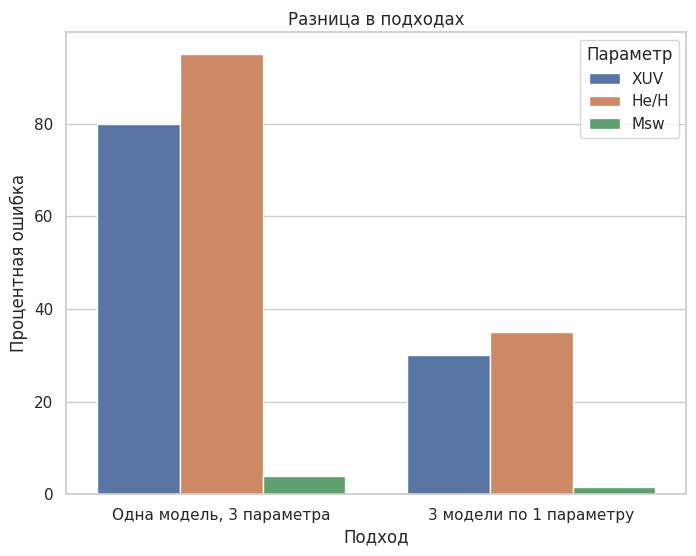

In [23]:
# Настройка стиля и размера графика
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Построение группированной столбчатой диаграммы
sns.barplot(data=df_long, 
            x='Подход', 
            y='Процентная ошибка', 
            hue='Параметр')

# Добавление заголовка и подписей
plt.title('Разница в подходах')
plt.xlabel('Подход')
plt.ylabel('Процентная ошибка')
plt.legend(title='Параметр')
plt.show()

In [ ]:
min(metrics_helium) # 42.1% noscale 44.7% resnet 52% scale

42.12231934070587

### добавление автоэнкодера к модели

In [36]:
import torch
import torch.nn as nn
from peft import LoraConfig, get_peft_model, TaskType
import loralib as lora
from chronos import ChronosPipeline, Chronos2Pipeline
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import dill
import torch.nn.functional as F

CONTEXT_LEN = 100      # длина входной последовательности
HORIZON = 3            # сколько значений предсказываем
LEARNING_RATE = 0.001
EPOCHS = 200
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=DEVICE,
    dtype=torch.float32,
)

torch.manual_seed(42)
np.random.seed(42)

tokenizer = pipeline.tokenizer
encoder = pipeline.model.model.encoder

class AttentionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads=12, dropout=0.2):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Проекция на размерность для attention
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, input_dim]

        # Проецируем и добавляем размерность последовательности
        h = self.input_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Создаем запрос
        query = self.query_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Self-attention
        attended, _ = self.multihead_attn(query, h, h)

        # Residual + norm
        out = self.norm(h + attended)
        out = self.dropout(out)

        return out.squeeze(1)  # [batch, hidden_dim]

class ChronosRegressorVAE(nn.Module):
    def __init__(self, encoder, tokenizer, output_dim=1, latent_dim=64, vae_weight=0.01):
        super().__init__()
        
        self.encoder = encoder
        self.tokenizer = tokenizer
        self.vae_weight = vae_weight
        
        # === ВАША ГОЛОВА (без изменений) ===
        layers = []
        prev_dim = 512
        hidden_dims = [512, 256]
        num_heads = 8
        dropout = 0.2
        
        for i, hidden_dim in enumerate(hidden_dims):
            if i == 0:
                layers.append(AttentionHead(prev_dim, hidden_dim, num_heads, dropout))
            else:
                layers.extend([
                    nn.Linear(prev_dim, hidden_dim),
                    nn.SiLU(),
                    nn.BatchNorm1d(hidden_dim),
                    nn.Dropout(dropout)
                ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        self.head = nn.Sequential(*layers)
        
        # === УПРОЩЁННЫЙ VAE ===
        # Только профиль реконструируем (проще и стабильнее)
        self.vae_mu = nn.Linear(512, latent_dim)
        self.vae_logvar = nn.Linear(512, latent_dim)
        self.profile_recon = nn.Linear(latent_dim, 101)  # Прямо в профиль
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x, return_vae=False):
        # Токенизация
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens
        token_ids = token_ids.to(x.device)
        
        # Encoder
        enc_out = self.encoder(input_ids=token_ids).last_hidden_state
        features = enc_out[:, -1, :]  # (B, 512)
        
        # Head
        preds = self.head(features)
        
        if return_vae:
            # VAE
            mu = self.vae_mu(features)
            logvar = self.vae_logvar(features)
            z = self.reparameterize(mu, logvar)
            profile_recon = self.profile_recon(z)
            
            return preds, {
                'mu': mu,
                'logvar': logvar,
                'profile_recon': profile_recon
            }
        
        return preds
    
    def vae_loss(self, vae_output, original_profile):
        """Упрощённый VAE loss"""
        mu = vae_output['mu']
        logvar = vae_output['logvar']
        profile_recon = vae_output['profile_recon']
        
        # KL divergence
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        
        # Profile reconstruction
        profile_recon_loss = F.mse_loss(profile_recon, original_profile)
        
        # Total
        vae_loss = kl_loss + profile_recon_loss
        
        return vae_loss, {
            'kl': kl_loss.item(),
            'profile_recon': profile_recon_loss.item()
        }

# Инициализация модели
model = ChronosRegressorVAE(encoder, tokenizer, vae_weight=0.3).to(DEVICE)

# ----- НАСТРОЙКА LORA -----
# Замораживаем все параметры энкодера
for param in model.encoder.parameters():
    param.requires_grad = False

lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=2,  # ранг LoRA (можно менять 4, 8, 16, 32)
    lora_alpha=256,  # scaling factor
    target_modules=["q","k", "v", "o"],  # для большинства transformer моделей
    lora_dropout=0.1,
    bias="none",  # не обучаем bias
)

# Применяем LoRA к энкодеру
model.encoder = get_peft_model(model.encoder, lora_config)

# Выводим информацию о trainable параметрах
model.encoder.print_trainable_parameters()
# Пример вывода: trainable params: 1,234,567 || all params: 123,456,789 || trainable%: 1.0


# ----- ОПТИМИЗАЦИЯ -----
# Теперь обучаем и голову, и LoRA-параметры
criterion = nn.MSELoss()
# criterion = RMSPELoss()
# criterion = nn.SmoothL1Loss() 
# Собираем все обучаемые параметры (голова + LoRA)
trainable_params = (
    list(model.head.parameters()) + 
    list(model.encoder.parameters()) +
    list(model.vae_mu.parameters()) +
    list(model.vae_logvar.parameters()) +
    list(model.profile_recon.parameters())
)

optimizer = torch.optim.AdamW(
    [
        {'params': model.head.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.encoder.parameters(), 'lr': LEARNING_RATE * 0.5, 'weight_decay': 0.01},
        {'params': model.vae_mu.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.vae_logvar.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.profile_recon.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
    ]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

metrics_xuv = []
metrics_helium = [0]
metrics_masslos = [0]


def save_model_with_architecture(model, filepath='complete_model.pkl'):
    """
    Сохраняет модель ПОЛНОСТЬЮ: архитектура + веса + код класса
    """
    # Используем dill для сохранения всего, включая определение класса
    with open(filepath, 'wb') as f:
        torch.save(model, f, pickle_module=dill)
    print(f"✅ Модель со всей архитектурой сохранена в {filepath}")

# ===== ЗАГРУЗКА =====
def load_model_with_architecture(filepath='complete_model.pkl', device='cuda'):
    """
    Загружает модель ПОЛНОСТЬЮ, даже если класс не определён в текущем скоупе
    """
    with open(filepath, 'rb') as f:
        model = torch.load(f, map_location=device, pickle_module=dill)
    model.eval()
    print(f"✅ Модель со всей архитектурой загружена из {filepath}")
    return model

def testing_model(logging = False):
    model.eval()
    all_preds_scaled = []
    all_targets_scaled = []

    # Собираем все предсказания и истинные значения
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_pred = model(x_batch)
            all_preds_scaled.append(y_pred.cpu())
            all_targets_scaled.append(y_batch.cpu())

    # Конкатенация
    y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
    y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

    # Денормализация → исходные физические шкалы
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
    y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


    # Имена целевых переменных (в том же порядке, что и в Y)
    # target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
    target_names = ['(XUVInt)']
    if logging:
        print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

    for i, name in enumerate(target_names):
        mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse = np.sqrt(mse)
        # Относительная MSE (RelMSE) - (pred/true - 1)^2
        # Защита от деления на ноль
        epsilon = 1e-7
        true_values = np.abs(y_true_orig[:, i]) + epsilon
        rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

        # Можно также считать в процентах
        rel_mse_percent = rel_mse * 100

        # Дополнительно: средняя относительная ошибка в процентах (MAPE)
        mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100

        if logging:
            print(f"{name}:")
            print(f"  MAE:  {mae:.4f}")
            print(f"  MSE:  {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
            print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
            print(f"  MAPE:     {mape:.4f}%")
            print("-" * 30)

        match name:
            case "(XUVInt)":
                metrics_xuv.append(mape)
                if mape <= min(metrics_xuv):
                    save_model_with_architecture(model, "best_xuv.pkl")
            case "log(Msw)":
                metrics_masslos.append(mape)
                if mape <= min(metrics_xuv):
                    save_model_with_architecture(model, "best_msw.pkl")
            case "(Helium)":
                metrics_helium.append(mape)
                if mape <= min(metrics_xuv):
                    save_model_with_architecture(model, "best_helium.pkl")
        print("epoch mape", mape)

# ----- ОБУЧЕНИЕ -----
val_losses = []
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_vae_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        preds, vae_output = model(x_batch, return_vae=True)
        reg_loss = criterion(preds, y_batch)
        vae_loss, vae_metrics = model.vae_loss(vae_output, x_batch)

        # Total loss
        loss = reg_loss + model.vae_weight * vae_loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += reg_loss.item()
        train_vae_loss += vae_loss.item()
    # Валидация
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = model(x_batch)
            val_loss += criterion(preds, y_batch).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_vae_loss = train_vae_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train: {avg_train_loss:.6f} | "
          f"VAE: {avg_vae_loss:.6f} | "
          f"Val: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss)
    train_losses.append(avg_train_loss)
    
    testing_model()
# ----------------------------
# 5. ИНФЕРЕНС (пример)
# ----------------------------
print('-'*30)
def smart_format(x, precision=4):
    if abs(x) >= 1e9:
        # Для больших чисел — оставляем как есть, но с фикс. точностью
        return f"{x:.{precision}f}"
    elif abs(x) < 1e-3 and x != 0:
        return f"{x:.{precision}e}"
    else:
        return f"{x:.{precision}f}"

def format_smart_array(arr, precision=4):
    return "[" + ", ".join(smart_format(x, precision) for x in arr) + "]"




with torch.no_grad():
    # Берём последний пример из валидации
    x_input = torch.tensor(X_val[-1:], dtype=torch.float32).to(DEVICE)  # [1, 100]
    y_true_scaled = Y_val[-1:]  # [1, 3] — НОРМАЛИЗОВАННЫЙ GT

    # Предсказание (в нормализованных шкалах)
    y_pred_scaled,_ = model(x_input)  # [1, 3]

    # Денормализация
    y_true_original = y_scaler.inverse_transform(y_true_scaled)  # [1, 3]
    y_pred_original = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())   # [1, 3]

    # Вывод
    print("Ground Truth (original):", format_smart_array(y_true_original.flatten()))
    print("Prediction   (original):", format_smart_array(y_pred_original.flatten()))

    # Метрики в исходных шкалах
    mae = mean_absolute_error(y_true_original, y_pred_original)
    mse = mean_squared_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mse)

    print(f"\nMetrics (original scale):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")



model.eval()
all_preds_scaled = []
all_targets_scaled = []

# Собираем все предсказания и истинные значения
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(DEVICE)
        y_pred = model(x_batch)
        all_preds_scaled.append(y_pred.cpu())
        all_targets_scaled.append(y_batch.cpu())

# Конкатенация
y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

# Денормализация → исходные физические шкалы
y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


# Имена целевых переменных (в том же порядке, что и в Y)
# target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
target_names = ['(XUVInt)']

print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
    rmse = np.sqrt(mse)
    # Относительная MSE (RelMSE) - (pred/true - 1)^2
    # Защита от деления на ноль
    epsilon = 1e-7
    true_values = np.abs(y_true_orig[:, i]) + epsilon
    rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

    # Можно также считать в процентах
    rel_mse_percent = rel_mse * 100

    # Дополнительно: средняя относительная ошибка в процентах (MAPE)
    mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100


    print(f"{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
    print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
    print(f"  MAPE:     {mape:.4f}%")
    print("-" * 30)

plt.title("Mape XUV")
plt.plot(metrics_xuv)
plt.show()
# plt.title("Mape helium")
# plt.plot(metrics_helium)
# plt.show()
# plt.title("Mape msw")
# plt.plot(metrics_masslos)
# plt.show()



trainable params: 49,152 || all params: 21,027,584 || trainable%: 0.2338
Epoch 1/200 | Train: 1.429019 | VAE: 0.305372 | Val: 1.027768
✅ Модель со всей архитектурой сохранена в best_xuv.pkl
epoch mape 186.26410961151123
Epoch 2/200 | Train: 1.273183 | VAE: 0.236146 | Val: 1.093092
epoch mape 226.6251802444458
Epoch 3/200 | Train: 0.972709 | VAE: 0.199946 | Val: 0.816946
✅ Модель со всей архитектурой сохранена в best_xuv.pkl
epoch mape 57.88867473602295
Epoch 4/200 | Train: 0.792718 | VAE: 0.159501 | Val: 0.910650
epoch mape 78.92647385597229
Epoch 5/200 | Train: 0.722974 | VAE: 0.135276 | Val: 0.843880
epoch mape 109.48446989059448
Epoch 6/200 | Train: 0.550479 | VAE: 0.108240 | Val: 1.165790
epoch mape 68.44017505645752
Epoch 7/200 | Train: 0.620621 | VAE: 0.084905 | Val: 0.739653
epoch mape 106.50579929351807
Epoch 8/200 | Train: 0.426550 | VAE: 0.065956 | Val: 0.930023
epoch mape 66.97244048118591
Epoch 9/200 | Train: 0.416640 | VAE: 0.048520 | Val: 0.594249
✅ Модель со всей архитек

ValueError: not enough values to unpack (expected 2, got 1)

In [37]:
min(metrics_xuv)

32.23702013492584

## МОДЕЛЬ ДЛЯ Msw

In [ ]:
import torch
import torch.nn as nn
from peft import LoraConfig, get_peft_model, TaskType
import loralib as lora
from chronos import ChronosPipeline, Chronos2Pipeline
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import dill
from spectrum_augmentations import augment_spectrum_noise_and_sharpen
CONTEXT_LEN = 100      # длина входной последовательности
HORIZON = 3            # сколько значений предсказываем
LEARNING_RATE = 0.001
EPOCHS = 150
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=DEVICE,
    dtype=torch.float32,
)


tokenizer = pipeline.tokenizer
encoder = pipeline.model.model.encoder

class AttentionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads=12, dropout=0.2):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Проекция на размерность для attention
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, input_dim]

        # Проецируем и добавляем размерность последовательности
        h = self.input_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Создаем запрос
        query = self.query_proj(x).unsqueeze(1)  # [batch, 1, hidden_dim]

        # Self-attention
        attended, _ = self.multihead_attn(query, h, h)

        # Residual + norm
        out = self.norm(h + attended)
        out = self.dropout(out)

        return out.squeeze(1)  # [batch, hidden_dim]

class ChronosRegressor(nn.Module):
    def __init__(self, encoder, tokenizer, output_dim=1):
        super().__init__()
        self.encoder = encoder
        self.tokenizer = tokenizer
        # self.head = nn.Linear(encoder.config.d_model, output_dim)
                # Слои с вниманием
        layers = []
        prev_dim = 512
        hidden_dims=[512 ,256, 128]
        num_heads=16
        dropout=0.2
        for i, hidden_dim in enumerate(hidden_dims):
            if i == 0:
                # Первый слой - attention
                layers.append(AttentionHead(prev_dim, hidden_dim, num_heads, dropout))
            else:
                # Последующие слои - обычные линейные
                layers.extend([
                    nn.Linear(prev_dim, hidden_dim),
                    nn.SiLU(),
                    nn.BatchNorm1d(hidden_dim),
                    nn.Dropout(dropout)
                ])
            prev_dim = hidden_dim

        # Выходной слой
        layers.append(nn.Linear(prev_dim, output_dim))

        self.head = nn.Sequential(*layers)

    def forward(self, x):
        # x приходит на GPU, но токенизатор требует CPU
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens

        # Переносим token_ids на то же устройство, что и энкодер
        token_ids = token_ids.to(self.encoder.device)

        enc_out = self.encoder(input_ids=token_ids).last_hidden_state
        return self.head(enc_out[:, -1, :])

# Инициализация модели
model = ChronosRegressor(encoder, tokenizer).to(DEVICE)

# ----- НАСТРОЙКА LORA -----
# Замораживаем все параметры энкодера
for param in model.encoder.parameters():
    param.requires_grad = False

class RMSPELoss(nn.Module):
    def __init__(self, epsilon=1e-7):
        super().__init__()
        self.epsilon = epsilon  # защита от деления на ноль
    
    def forward(self, y_pred, y_true):
        # Добавляем epsilon для стабильности
        relative_error = (y_true - y_pred) / (y_true.abs() + self.epsilon)
        squared_error = relative_error ** 2
        return torch.sqrt(torch.mean(squared_error))
    
class HybridLoss(nn.Module):
    def __init__(self, alpha=0.7, delta=1.0):
        super().__init__()
        self.alpha = alpha  # вес MAPE компоненты
        self.huber = nn.SmoothL1Loss(beta=delta)
    
    def forward(self, y_pred, y_true):
        # Масштабируем для численной стабильности
        y_true_scaled = y_true.abs() + 1e-7
        
        # MAPE компонента
        mape_part = torch.mean(torch.abs((y_true - y_pred) / y_true_scaled))
        
        # Huber компонента
        huber_part = self.huber(y_pred, y_true)
        
        return self.alpha * mape_part + (1 - self.alpha) * huber_part

# Конфигурация LoRA
# lora_config = LoraConfig(
#     task_type=TaskType.FEATURE_EXTRACTION,
#     r=2,  # ранг LoRA (можно менять 4, 8, 16, 32)
#     lora_alpha=8,  # scaling factor
#     target_modules=["k", "v", "o", 'q'],  # для большинства transformer моделей
#     lora_dropout=0.1,
#     bias="none",  # не обучаем bias
# )

lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=2,  # ранг LoRA (можно менять 4, 8, 16, 32)
    lora_alpha=256,  # scaling factor
    target_modules=["q","k", "v", "o"],  # для большинства transformer моделей
    lora_dropout=0.1,
    bias="none",  # не обучаем bias
)

# Применяем LoRA к энкодеру
model.encoder = get_peft_model(model.encoder, lora_config)

# Выводим информацию о trainable параметрах
model.encoder.print_trainable_parameters()
# Пример вывода: trainable params: 1,234,567 || all params: 123,456,789 || trainable%: 1.0


# ----- ОПТИМИЗАЦИЯ -----
# Теперь обучаем и голову, и LoRA-параметры
criterion = nn.MSELoss()
# criterion = RMSPELoss()
# criterion = nn.SmoothL1Loss() 
# Собираем все обучаемые параметры (голова + LoRA)
for param in model.encoder.parameters():
    param.requires_grad = False
trainable_params = list(model.head.parameters()) + list(model.encoder.parameters())
optimizer = torch.optim.AdamW(  # Используем AdamW вместо Adam
    [
        {'params': model.head.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.encoder.parameters(), 'lr': LEARNING_RATE * 0.5, 'weight_decay': 0.01}
    ]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Можно использовать разные learning rates для головы и LoRA
# optimizer = torch.optim.Adam([
#     {'params': model.head.parameters(), 'lr': LEARNING_RATE * 10},  # голова учится быстрее
#     {'params': model.encoder.parameters(), 'lr': LEARNING_RATE}     # LoRA параметры
# ])

metrics_xuv = [0]
metrics_helium = [0]
metrics_masslos = []


def save_model_with_architecture(model, filepath='complete_model.pkl'):
    """
    Сохраняет модель ПОЛНОСТЬЮ: архитектура + веса + код класса
    """
    # Используем dill для сохранения всего, включая определение класса
    with open(filepath, 'wb') as f:
        torch.save(model, f, pickle_module=dill)
    print(f"✅ Модель со всей архитектурой сохранена в {filepath}")

# ===== ЗАГРУЗКА =====
def load_model_with_architecture(filepath='complete_model.pkl', device='cuda'):
    """
    Загружает модель ПОЛНОСТЬЮ, даже если класс не определён в текущем скоупе
    """
    with open(filepath, 'rb') as f:
        model = torch.load(f, map_location=device, pickle_module=dill)
    model.eval()
    print(f"✅ Модель со всей архитектурой загружена из {filepath}")
    return model

def testing_model(loader, logging = False, save=False):
    model.eval()
    all_preds_scaled = []
    all_targets_scaled = []

    # Собираем все предсказания и истинные значения
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_pred = model(x_batch)
            all_preds_scaled.append(y_pred.cpu())
            all_targets_scaled.append(y_batch.cpu())

    # Конкатенация
    y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
    y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

    # Денормализация → исходные физические шкалы
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
    y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


    # Имена целевых переменных (в том же порядке, что и в Y)
    # target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
    target_names = ['log(Msw)']
    if logging:
        print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

    for i, name in enumerate(target_names):
        mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse = np.sqrt(mse)
        # Относительная MSE (RelMSE) - (pred/true - 1)^2
        # Защита от деления на ноль
        epsilon = 1e-7
        true_values = np.abs(y_true_orig[:, i]) + epsilon
        rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

        # Можно также считать в процентах
        rel_mse_percent = rel_mse * 100

        # Дополнительно: средняя относительная ошибка в процентах (MAPE)
        mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100

        if logging:
            print(f"{name}:")
            print(f"  MAE:  {mae:.4f}")
            print(f"  MSE:  {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
            print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
            print(f"  MAPE:     {mape:.4f}%")
            print("-" * 30)
        if save:
            # print('DSAFDASF')
            match name:
                case "(XUVInt)":
                    metrics_xuv.append(mape)
                    if mape <= min(metrics_xuv):
                        save_model_with_architecture(model, "best_xuv.pkl")
                case "log(Msw)":
                    metrics_masslos.append(mape)
                    if mape <= min(metrics_masslos):
                        save_model_with_architecture(model, "best_msw.pkl")
                case "(Helium)":
                    metrics_helium.append(mape)
                    if mape <= min(metrics_xuv):
                        save_model_with_architecture(model, "best_helium.pkl")
        print("epoch mape", mape)
        return mape

# ----- ОБУЧЕНИЕ -----
val_losses = []
train_losses = []

mape_train = []
mape_val = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        x_batch = augment_spectrum_noise_and_sharpen(x_batch)

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Валидация
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            x_batch = augment_spectrum_noise_and_sharpen(x_batch)
            preds = model(x_batch)
            val_loss += criterion(preds, y_batch).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val Loss: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss)
    train_losses.append(avg_train_loss)
   

    mape_val.append(testing_model(val_loader, save=True))
    mape_train.append(testing_model(train_loader))
    
# ----------------------------
# 5. ИНФЕРЕНС (пример)
# ----------------------------
print('-'*30)
def smart_format(x, precision=4):
    if abs(x) >= 1e9:
        # Для больших чисел — оставляем как есть, но с фикс. точностью
        return f"{x:.{precision}f}"
    elif abs(x) < 1e-3 and x != 0:
        return f"{x:.{precision}e}"
    else:
        return f"{x:.{precision}f}"

def format_smart_array(arr, precision=4):
    return "[" + ", ".join(smart_format(x, precision) for x in arr) + "]"




with torch.no_grad():
    # Берём последний пример из валидации
    x_input = torch.tensor(X_val[-1:], dtype=torch.float32).to(DEVICE)  # [1, 100]
    y_true_scaled = Y_val[-1:]  # [1, 3] — НОРМАЛИЗОВАННЫЙ GT

    # Предсказание (в нормализованных шкалах)
    y_pred_scaled = model(x_input)  # [1, 3]

    # Денормализация
    y_true_original = y_scaler.inverse_transform(y_true_scaled)  # [1, 3]
    y_pred_original = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())   # [1, 3]

    # Вывод
    print("Ground Truth (original):", format_smart_array(y_true_original.flatten()))
    print("Prediction   (original):", format_smart_array(y_pred_original.flatten()))

    # Метрики в исходных шкалах
    mae = mean_absolute_error(y_true_original, y_pred_original)
    mse = mean_squared_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mse)

    print(f"\nMetrics (original scale):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")



model.eval()
all_preds_scaled = []
all_targets_scaled = []

# Собираем все предсказания и истинные значения
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(DEVICE)
        y_pred = model(x_batch)
        all_preds_scaled.append(y_pred.cpu())
        all_targets_scaled.append(y_batch.cpu())

# Конкатенация
y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

# Денормализация → исходные физические шкалы
y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


# Имена целевых переменных (в том же порядке, что и в Y)
# target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
target_names = ['(XUVInt)']

print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
    rmse = np.sqrt(mse)
    # Относительная MSE (RelMSE) - (pred/true - 1)^2
    # Защита от деления на ноль
    epsilon = 1e-7
    true_values = np.abs(y_true_orig[:, i]) + epsilon
    rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

    # Можно также считать в процентах
    rel_mse_percent = rel_mse * 100

    # Дополнительно: средняя относительная ошибка в процентах (MAPE)
    mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100
    ss_res = np.sum((y_true_orig[:, i] - y_pred_orig[:, i]) ** 2)
    ss_tot = np.sum((y_true_orig[:, i] - np.mean(y_true_orig[:, i])) ** 2)
    r2 = 1 - (ss_res / (ss_tot + epsilon))

    print(f"{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
    print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
    print(f"  MAPE:     {mape:.4f}%")
    print(f"  R²:       {r2:.4f}")
    print("-" * 30)

# plt.title("Mape XUV")
# plt.plot(metrics_xuv)
# plt.show()
# plt.title("Mape helium")
# plt.plot(metrics_helium)
# plt.show()
# plt.title("Mape msw")
# plt.plot(metrics_masslos)
# plt.show()



trainable params: 49,152 || all params: 21,027,584 || trainable%: 0.2338
Epoch 1/150 | Train Loss: 1.019122 | Val Loss: 0.783368
✅ Модель со всей архитектурой сохранена в best_msw.pkl
epoch mape 3.8836520165205
epoch mape 4.080630838871002
Epoch 2/150 | Train Loss: 0.739763 | Val Loss: 0.609759
✅ Модель со всей архитектурой сохранена в best_msw.pkl
epoch mape 3.455130383372307
epoch mape 3.4707047045230865
Epoch 3/150 | Train Loss: 0.691241 | Val Loss: 0.590717
✅ Модель со всей архитектурой сохранена в best_msw.pkl
epoch mape 3.0639924108982086
epoch mape 2.841789461672306
Epoch 4/150 | Train Loss: 0.534878 | Val Loss: 0.551272
✅ Модель со всей архитектурой сохранена в best_msw.pkl
epoch mape 3.0352208763360977
epoch mape 2.5745484977960587
Epoch 5/150 | Train Loss: 0.485847 | Val Loss: 0.695413
epoch mape 3.3883627504110336
epoch mape 2.796275168657303
Epoch 6/150 | Train Loss: 0.446561 | Val Loss: 0.649834
epoch mape 3.1882867217063904
epoch mape 2.356773428618908
Epoch 7/150 | Train

KeyboardInterrupt: 

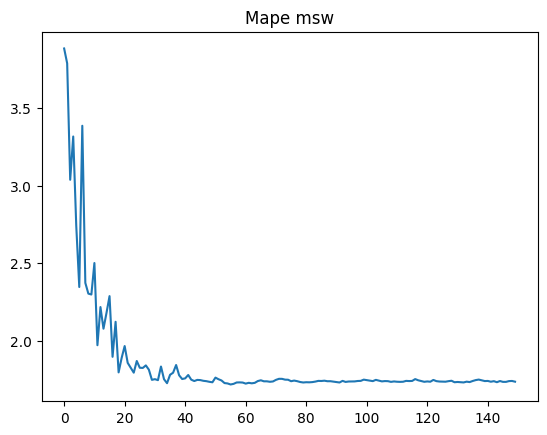

In [43]:
plt.title("Mape msw")
plt.plot(metrics_masslos)
plt.show()

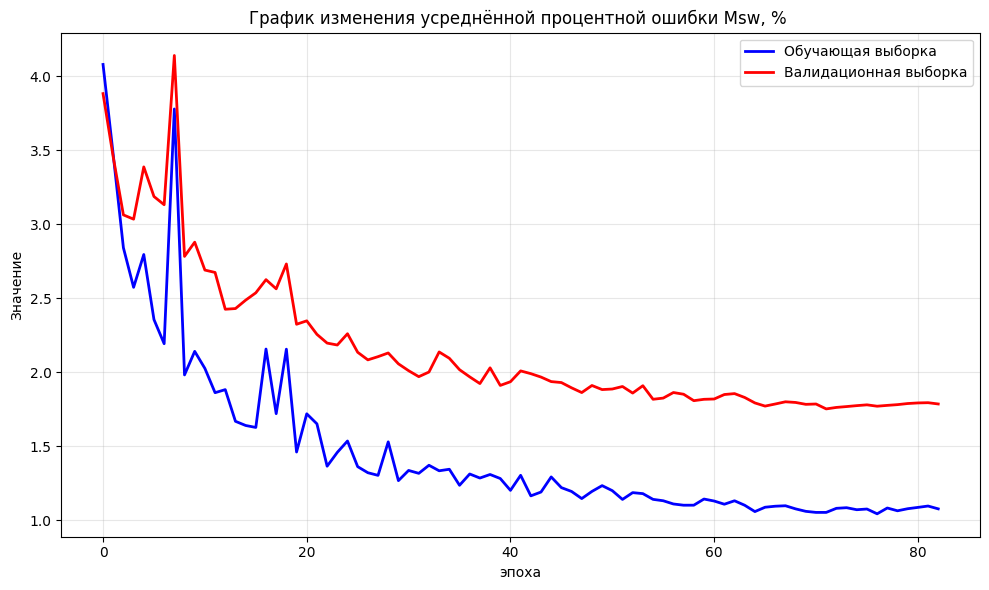

In [27]:
import seaborn as sns
plt.figure(figsize=(10, 6))

sns.lineplot(x=range(len(train_losses)-1), y=mape_train, label='Обучающая выборка', color='blue', linewidth=2)
sns.lineplot(x=range(len(val_losses)-1), y=mape_val, label='Валидационная выборка', color='red', linewidth=2)

plt.title('График изменения усреднённой процентной ошибки Msw, % ')
plt.xlabel('эпоха')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ~~resnet-like conv1d~~ ~~2chTransformer~~ ~~spectrumTransformer~~ ~~selfmade autoencoder~~ ~~IBM ttm~~
### ~~ma-vae~~ ~~ttm~~ moirai

#### dataset легаси

In [54]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy import interpolate  # для более гладкой интерполяции, но можно и numpy
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from scipy.interpolate import interp1d

def parse_parameters(file_path):
    """
    Читает файл parameters.txt и возвращает словарь с нужными параметрами
    """
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                key = parts[0]
                value = ' '.join(parts[1:])  # на случай, если значение содержит пробелы
                params[key] = value
    # Извлекаем нужные параметры
    result = {}
    for param in ['PName', 'Msw', 'XUVInt', 'H2a', 'Helium']:
        result[param] = params.get(param)
    return result

def process_files_in_folder_with_params(root_folder):
    """
    Рекурсивно проходит по папке, читает параметры и файлы с данными
    Возвращает список словарей, где каждый словарь — это один файл
    """
    dataset = []
    root = Path(root_folder)
    for data_file_path in root.rglob('*[.txt,.dat]'):
        if data_file_path.name == 'parameters.txt':
            continue  # Пропускаем файл параметров

        # Ищем файл parameters.txt в той же папке
        param_file_path = data_file_path.parent / 'parameters.txt'

        if param_file_path.exists():
            params = parse_parameters(param_file_path)
            # print(f"Файл: {data_file_path}")
            # print(f"Параметры: {params}")
        else:
            # print(f"Файл parameters.txt не найден для {data_file_path}")
            params = {}

        # Читаем V и FullAbs из data файла
        try:
            V, FullAbs = np.loadtxt(data_file_path, usecols=(0, 1), unpack=True, skiprows=1)
            entry = {
                'V': V,
                'FullAbs': FullAbs,
                'PName': params.get('PName'),
                'Msw': params.get('Msw'),
                'XUVInt': params.get('XUVInt'),
                'H2a': params.get('H2a'),
                'Helium': params.get('Helium'),
                # 'File': str(data_file_path)  # можно убрать, если не нужно
            }
            dataset.append(entry)
        except Exception as e:
            print(f"Ошибка при загрузке данных из {data_file_path}: {e}")
        # print("-" * 50)

    return dataset

def pad_or_truncate(seq, target_len=101, pad_value=0.0):
    seq = np.array(seq, dtype=np.float32)
    if len(seq) > target_len:
        # Берём последние target_len значений
        return seq[-target_len:]
    elif len(seq) < target_len:
        # Дополняем СЛЕВА (чтобы "настоящие" данные были справа)
        padding = np.full(target_len - len(seq), pad_value, dtype=np.float32)
        return np.concatenate([padding, seq])
    else:
        return seq



folder_path = 'new_dataset'  # Укажите путь к вашей папке
dataset = process_files_in_folder_with_params(folder_path)

# Интерполяция 101 → 96
def interpolate_101_to_96(y):
    x_old = np.linspace(0, 1, 101)
    x_new = np.linspace(0, 1, 96)
    f = interp1d(x_old, y, kind='cubic', fill_value='extrapolate')
    return f(x_new)


def interpolate_to_length(arr, target_len=101):
    """
    Приводит одномерный массив arr к длине target_len с помощью линейной интерполяции.
    Поддерживает любую исходную длину (как меньше, так и больше target_len).
    """
    current_len = len(arr)
    if current_len == target_len:
        return arr
    # Создаём старую и новую сетку
    x_old = np.linspace(0, 1, current_len)
    x_new = np.linspace(0, 1, target_len)
    # Линейная интерполяция
    return np.interp(x_new, x_old, arr)

df = pd.DataFrame(dataset)

df['FullAbs_fixed'] = df['FullAbs'].apply(lambda x: pad_or_truncate(x, target_len=101))
# Теперь все последовательности длиной 101

# XXX интерполяция кратная 32
df['FullAbs_fixed'] = df['FullAbs_fixed'].apply(lambda x: interpolate_101_to_96(x))

X = np.stack(df['FullAbs_fixed'].values)  # [N, 100]
X = X.astype(np.float32)
# XXX пробуем только XUV, известно что скаллирование данных 
Y = df[['XUVInt']].values.astype(np.float32)
# Целевые переменные
# Y = df[['XUVInt', 'Msw', 'Helium']].values.astype(np.float32)  # [N,3]
# логарифмируем
Y_log = Y.copy()

# Логарифмируем ТОЛЬКО Msw (индекс 1)
# Msw - скорость солнечного ветра, положительная величина
# Y_log[:, 1] = np.log1p(Y[:, 1])  # log(1 + Msw)
# Нормализация
y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y_log)  # теперь ~ N(0,1) по каждой колонке

split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y_scaled[:split], Y_scaled[split:]
scaler_X = StandardScaler()

# # XXX добавление скалирования
X_train_scaled = scaler_X.fit_transform(X_train)  # shape (n, 101)
X_val_scaled = scaler_X.transform(X_val)
BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train).unsqueeze(1), torch.from_numpy(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val).unsqueeze(1), torch.from_numpy(Y_val)),
    batch_size=BATCH_SIZE
)


dtype('float32')

#### архитектура модели (легаси)

In [65]:
import torch
import torch.nn as nn
from typing import Dict, List, Optional, Tuple
from uni2ts.model.moirai import MoiraiModule, MoiraiForecast
from peft import LoraConfig, get_peft_model

class MoiraiVoigt(nn.Module):
    def __init__(self, config:dict):
        super().__init__()
        
        from uni2ts.model.moirai import MoiraiModule
        
        moirai = MoiraiModule.from_pretrained(f"Salesforce/moirai-1.0-R-{config['model_size']}")
        
        # Берём ТОЛЬКО encoder
        self.encoder = moirai.encoder
        
        
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        lora_r = 2
        lora_alpha = 256
        lora_dropout = 0.2

        if config.get('use_lora', True):
            lora_config = LoraConfig(
                r=config['lora_r'],
                lora_alpha=config['lora_alpha'],
                target_modules=config['lora_targets'],
                lora_dropout=config['lora_dropout'],
                bias="none",
            )
            self.encoder = get_peft_model(self.encoder, lora_config)
            print(f"✅ LoRA применена: {sum(p.numel() for p in self.encoder.parameters() if p.requires_grad):,} trainable params")


        # Простая проекция: patch (32) → 384
        input_dim = 384
        self.patch_proj = nn.Linear(32, input_dim)
        layers = []
        for h_dim in config['head_dims']:
            layers.append(nn.Linear(input_dim, h_dim))
            if config.get('use_layernorm', True):
                layers.append(nn.LayerNorm(h_dim))
            layers.append(nn.GELU() if config['activation'] == 'gelu' else nn.SiLU())
            layers.append(nn.Dropout(config['head_dropout']))
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 1))
        self.head = nn.Sequential(*layers)

        # Инициализация головы
        self._init_head(config['head_init_scale'])        
        self.patch_size = 32
    
    def _init_head(self, scale: float = 0.01):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=scale)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        """
        x: (batch, 96)
        """
        if x.dim() == 3:
            x = x.squeeze(1) if x.shape[1] == 1 else x.squeeze(2)
        
        B, L = x.shape
        P = self.patch_size
        num_patches = L // P  # 3
        
        # === 1. Патчинг: (B, 96) → (B, 3, 32) ===
        patches = x[:, :num_patches * P].reshape(B, num_patches, P)
        
        # === 2. Проекция: (B, 3, 32) → (B, 3, 384) ===
        reprs = self.patch_proj(patches)
        
        # === 3. Encoder ===
        # Создаём простую attention mask (все видят всех)
        attn_mask = None  # None = full attention
        
        # time_id и var_id для positional encoding
        time_id = torch.arange(num_patches, device=x.device).unsqueeze(0).expand(B, -1)  # (B, 3)
        var_id = torch.zeros(B, num_patches, dtype=torch.long, device=x.device)  # (B, 3)
        
        hidden = self.encoder(reprs, attn_mask, time_id=time_id, var_id=var_id)  # (B, 3, 384)
        
        # === 4. Pooling + Head ===
        pooled = hidden.mean(dim=1)  # (B, 384)
        return self.head(pooled)  # (B, 1)







optuning

In [71]:
def objective(trial, train_loader, val_loader, device, epochs=100):
    
    # === СЕРЧ-СПЕЙС ===
    config = {
        # Модель
        'model_size': trial.suggest_categorical('model_size', ['small']),  # можно добавить tiny, base
        
        # LoRA
        'use_lora': trial.suggest_categorical('use_lora', [True]),
        'lora_r': trial.suggest_categorical('lora_r', [4, 8, 16, 32]),
        'lora_alpha': trial.suggest_categorical('lora_alpha', [4,16,32,64,128,256,512]),
        'lora_dropout': trial.suggest_float('lora_dropout', 0.0, 0.3),
        'lora_targets': trial.suggest_categorical('lora_targets', [
            ["k_proj", "v_proj"],
            ["q_proj", "k_proj"],
            ["q_proj", "k_proj", "v_proj"],
            ["q_proj", "k_proj", "v_proj", "out_proj"],
            ["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
        ]),
        
                
        # Голова
        'head_dims': trial.suggest_categorical('head_dims', [
            [128, ],
            [256, 64, ],
            [256, 128, 64, ],
            [512, 256, ],
        ]),
        'use_layernorm': trial.suggest_categorical('use_layernorm', [True, False]),
        'activation': trial.suggest_categorical('activation', ['gelu', 'relu']),
        'head_dropout': trial.suggest_float('head_dropout', 0.0, 0.3),
        'head_init_scale': trial.suggest_float('head_init_scale', 0.001, 0.1, log=True),
        
        # Обучение
        'lr_head': trial.suggest_float('lr_head', 1e-4, 1e-2, log=True),
        'lr_encoder': trial.suggest_float('lr_encoder', 1e-6, 1e-4, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True),
        'loss_type': trial.suggest_categorical('loss_type', ['smooth_l1', 'mse']),
    }
    
    # === МОДЕЛЬ ===
    model = MoiraiVoigt(config).to(device)
    
    # === ОПТИМИЗАТОР ===
    encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
    head_params = list(model.head.parameters()) + list(model.patch_proj.parameters())
    
    param_groups = [{"params": head_params, "lr": config['lr_head']}]
    if encoder_params and config['lr_encoder'] > 0:
        param_groups.append({"params": encoder_params, "lr": config['lr_encoder']})
    
    optimizer = torch.optim.AdamW(param_groups, weight_decay=config['weight_decay'])
    
    # === LOSS ===
    if config['loss_type'] == 'l1':
        criterion = nn.L1Loss()
    elif config['loss_type'] == 'smooth_l1':
        criterion = nn.SmoothL1Loss(beta=0.1)
    elif config['loss_type'] == 'huber':
        criterion = nn.HuberLoss(delta=0.5)
    else:
        criterion = nn.MSELoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)
    
    best_val_mape = float('inf')
    metrics_xuv = []
    def testing_model(logging = False):
        model.eval()
        all_preds_scaled = []
        all_targets_scaled = []

        # Собираем все предсказания и истинные значения
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(DEVICE)
                y_pred= model(x_batch)
                all_preds_scaled.append(y_pred.cpu())
                all_targets_scaled.append(y_batch.cpu())

        # Конкатенация
        y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
        y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

        # Денормализация → исходные физические шкалы
        y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
        y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


        # Имена целевых переменных (в том же порядке, что и в Y)
        # target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
        target_names = ['(XUVInt)']
        if logging:
            print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

        for i, name in enumerate(target_names):
            mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
            mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
            rmse = np.sqrt(mse)
            # Относительная MSE (RelMSE) - (pred/true - 1)^2
            # Защита от деления на ноль
            epsilon = 1e-7
            true_values = np.abs(y_true_orig[:, i]) + epsilon
            rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

            # Можно также считать в процентах
            rel_mse_percent = rel_mse * 100

            # Дополнительно: средняя относительная ошибка в процентах (MAPE)
            mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100

            if logging:
                print(f"{name}:")
                print(f"  MAE:  {mae:.4f}")
                print(f"  MSE:  {mse:.4f}")
                print(f"  RMSE: {rmse:.4f}")
                print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
                print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
                print(f"  MAPE:     {mape:.4f}%")
                print("-" * 30)

            match name:
                case "(XUVInt)":
                    metrics_xuv.append(mape)
                    if mape <= min(metrics_xuv):
                        print("epoch mape:", mape)
                        save_model_with_architecture(model, "morai_best_xuv.pkl")
                case "log(Msw)":
                    metrics_masslos.append(mape)
                    if mape <= min(metrics_masslos):
                        save_model_with_architecture(model, "morai_best_msw.pkl")
                case "(Helium)":
                    metrics_helium.append(mape)
                    if mape <= min(metrics_helium):
                        save_model_with_architecture(model, "morai_best_helium.pkl")
            # print("epoch mape for ",name,":", mape)
            return mape


    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Валидация
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                preds = model(x_batch)
                val_loss += criterion(preds, y_batch).item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        # print(f"Epoch {epoch+1}/{EPOCHS} | "
        #     f"Train Loss: {avg_train_loss:.6f} | "
        #     f"Val Loss: {avg_val_loss:.6f}")
        scheduler.step(avg_val_loss)
        val_losses.append(avg_val_loss)
        train_losses.append(avg_train_loss)
        
        mape = testing_model()
        if mape < best_val_mape:
                best_val_mape = mape
    return best_val_mape
import optuna

study = optuna.create_study(
        direction="minimize",
        study_name="morai",
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=42),
    )

def callback(study, trial):
    if trial.state == optuna.trial.TrialState.COMPLETE:
        print(f"✅ Trial {trial.number}: MAPE={trial.value:.2f}% | Params: {trial.params}")

# Запуск
print(f"🚀 Запуск Optuna: {20} трейлов, {100} эпох каждый")

study.optimize(
    lambda trial: objective(trial, 
                            train_loader,
                            val_loader,
                            DEVICE, 
                            130),
    n_trials=40,
    callbacks=[callback],
    show_progress_bar=True,
)

import json
print(f"\n🏆 Лучший результат: {study.best_value:.2f}% MAPE")
print(f"📋 Лучшие параметры:\n{json.dumps(study.best_params, indent=2)}")

# Сохранение
results = {
    'best_value': study.best_value,
    'best_params': study.best_params,
    'all_trials': [
        {'number': t.number, 'value': t.value, 'params': t.params}
        for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE
    ]
}

Path("optuna_results").mkdir(exist_ok=True)
with open(f"optuna_results/moirai.json", "w") as f:
    json.dump(results, f, indent=2)



[I 2026-03-14 09:02:07,382] A new study created in memory with name: morai


🚀 Запуск Optuna: 20 трейлов, 100 эпох каждый


  0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['k_proj', 'v_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['q_proj', 'k_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['q_proj', 'k_proj', 'v_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distributio

✅ LoRA применена: 73,728 trainable params
epoch mape: 231.21716976165771
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape: 230.4248809814453
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape: 188.51511478424072
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape: 168.4589385986328
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape: 165.6960964202881
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape: 164.81481790542603
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl


Best trial: 0. Best value: 164.815:   2%|▎         | 1/40 [00:55<35:54, 55.24s/it]/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['k_proj', 'v_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['q_proj', 'k_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['q_proj', 'k_proj', 'v_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWa

...

Best trial: 21. Best value: 140.495:  72%|███████▎  | 29/40 [29:04<10:43, 58.49s/it]/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['k_proj', 'v_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['q_proj', 'k_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ['q_proj', 'k_proj', 'v_proj'] which is of type list.
  'lora_targets': trial.suggest_categorical('lora_targets', [
/tmp/ipykernel_3660810/1095144056.py:13: User

[I 2026-03-14 09:31:12,304] Trial 28 finished with value: 218.85087490081787 and parameters: {'model_size': 'small', 'use_lora': True, 'lora_r': 4, 'lora_alpha': 4, 'lora_dropout': 0.04911290818173429, 'lora_targets': ['q_proj', 'k_proj', 'v_proj', 'out_proj'], 'head_dims': [256, 128, 64], 'use_layernorm': True, 'activation': 'gelu', 'head_dropout': 0.05121472153710018, 'head_init_scale': 0.013901296673532754, 'lr_head': 0.007556879630487867, 'lr_encoder': 1.3206599733648136e-06, 'weight_decay': 0.004672091938810911, 'loss_type': 'smooth_l1'}. Best is trial 21 with value: 140.49479961395264.
✅ Trial 28: MAPE=218.85% | Params: {'model_size': 'small', 'use_lora': True, 'lora_r': 4, 'lora_alpha': 4, 'lora_dropout': 0.04911290818173429, 'lora_targets': ['q_proj', 'k_proj', 'v_proj', 'out_proj'], 'head_dims': [256, 128, 64], 'use_layernorm': True, 'activation': 'gelu', 'head_dropout': 0.05121472153710018, 'head_init_scale': 0.013901296673532754, 'lr_head': 0.007556879630487867, 'lr_encoder'

Best trial: 21. Best value: 140.495:  72%|███████▎  | 29/40 [29:53<11:20, 61.85s/it]


[W 2026-03-14 09:32:00,995] Trial 29 failed with parameters: {'model_size': 'small', 'use_lora': True, 'lora_r': 8, 'lora_alpha': 64, 'lora_dropout': 0.1757378002463284, 'lora_targets': ['k_proj', 'v_proj'], 'head_dims': [512, 256], 'use_layernorm': True, 'activation': 'relu', 'head_dropout': 0.020884069671304052, 'head_init_scale': 0.00395972983301242, 'lr_head': 0.0007793353624718545, 'lr_encoder': 1.9615906745715196e-06, 'weight_decay': 0.0019233405905260176, 'loss_type': 'smooth_l1'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/kirill/diploma/venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_3660810/1095144056.py", line 199, in <lambda>
    lambda trial: objective(trial,
                 ^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3660810/1095144056.py", line 152, in objective
    loss.backward()
  File "

KeyboardInterrupt: 

#### Обучение

✅ LoRA применена: 87,552 trainable params
Всего параметров: 10,838,601
Обучаемых параметров (только голова): 215,937
Epoch 1/150 | Train Loss: 0.310985 | Val Loss: 0.322383
Метрики по каждой целевой переменной (в исходных шкалах):

(XUVInt):
  MAE:  13.0421
  MSE:  237.9468
  RMSE: 15.4255
  RelMSE:   34.551674 (в относительных единицах)
  RelMSE%:  3455.1674%
  MAPE:     233.7947%
------------------------------
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape for  (XUVInt) : 233.79473686218262
Epoch 2/150 | Train Loss: 0.298362 | Val Loss: 0.316982
epoch mape for  (XUVInt) : 234.43703651428223
Epoch 3/150 | Train Loss: 0.291053 | Val Loss: 0.312685
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape for  (XUVInt) : 229.24447059631348
Epoch 4/150 | Train Loss: 0.283879 | Val Loss: 0.306696
✅ Модель со всей архитектурой сохранена в morai_best_xuv.pkl
epoch mape for  (XUVInt) : 216.38712882995605
Epoch 5/150 | Train Loss: 0.293315 | Val Loss: 0.

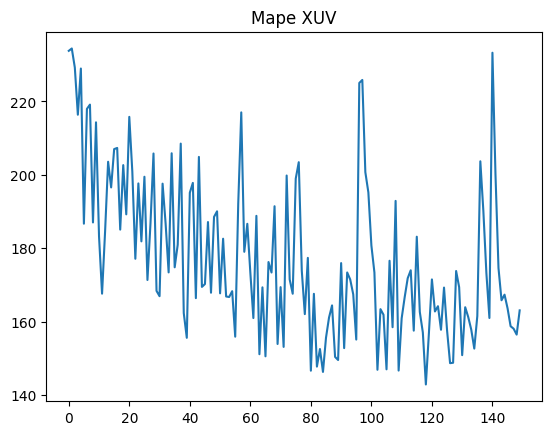

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import dill

LEARNING_RATE = 5e-4
EPOCHS = 150
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Параметры
SEQ_LEN = 101
N_TARGETS = 1 # или 1, если только XUVInt

# Создаем модель
model = MoiraiVoigt().to(DEVICE)

# Выведем информацию о количестве параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров (только голова): {trainable_params:,}")

# Оптимизатор
# optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)
# criterion = nn.MSELoss()
criterion = nn.HuberLoss(delta=0.5)

encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]

# Параметры головы и patch_proj
head_params = list(model.head.parameters()) + list(model.patch_proj.parameters())
lr_head = 1e-3
lr_encoder= 1e-5
weight_decay= 0.01
optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": lr_encoder},
    {"params": head_params, "lr": lr_head},
], weight_decay=weight_decay)
metrics_xuv = []
metrics_helium = []
metrics_masslos = []


def save_model_with_architecture(model, filepath='complete_model.pkl'):
    """
    Сохраняет модель ПОЛНОСТЬЮ: архитектура + веса + код класса
    """
    # Используем dill для сохранения всего, включая определение класса
    with open(filepath, 'wb') as f:
        torch.save(model, f, pickle_module=dill)
    print(f"✅ Модель со всей архитектурой сохранена в {filepath}")

# ===== ЗАГРУЗКА =====
def load_model_with_architecture(filepath='complete_model.pkl', device='cuda'):
    """
    Загружает модель ПОЛНОСТЬЮ, даже если класс не определён в текущем скоупе
    """
    with open(filepath, 'rb') as f:
        model = torch.load(f, map_location=device, pickle_module=dill)
    model.eval()
    print(f"✅ Модель со всей архитектурой загружена из {filepath}")
    return model

def testing_model(logging = False):
    model.eval()
    all_preds_scaled = []
    all_targets_scaled = []

    # Собираем все предсказания и истинные значения
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_pred= model(x_batch)
            all_preds_scaled.append(y_pred.cpu())
            all_targets_scaled.append(y_batch.cpu())

    # Конкатенация
    y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
    y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

    # Денормализация → исходные физические шкалы
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
    y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


    # Имена целевых переменных (в том же порядке, что и в Y)
    # target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
    target_names = ['(XUVInt)']
    if logging:
        print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

    for i, name in enumerate(target_names):
        mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse = np.sqrt(mse)
        # Относительная MSE (RelMSE) - (pred/true - 1)^2
        # Защита от деления на ноль
        epsilon = 1e-7
        true_values = np.abs(y_true_orig[:, i]) + epsilon
        rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

        # Можно также считать в процентах
        rel_mse_percent = rel_mse * 100

        # Дополнительно: средняя относительная ошибка в процентах (MAPE)
        mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100

        if logging:
            print(f"{name}:")
            print(f"  MAE:  {mae:.4f}")
            print(f"  MSE:  {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
            print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
            print(f"  MAPE:     {mape:.4f}%")
            print("-" * 30)

        match name:
            case "(XUVInt)":
                metrics_xuv.append(mape)
                if mape <= min(metrics_xuv):
                    save_model_with_architecture(model, "morai_best_xuv.pkl")
            case "log(Msw)":
                metrics_masslos.append(mape)
                if mape <= min(metrics_masslos):
                    save_model_with_architecture(model, "morai_best_msw.pkl")
            case "(Helium)":
                metrics_helium.append(mape)
                if mape <= min(metrics_helium):
                    save_model_with_architecture(model, "morai_best_helium.pkl")
        print("epoch mape for ",name,":", mape)

# ----- ОБУЧЕНИЕ -----
val_losses = []
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Валидация
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = model(x_batch)
            val_loss += criterion(preds, y_batch).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val Loss: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss)
    train_losses.append(avg_train_loss)
    if epoch%10==0:
        testing_model(logging=True)
    else:
        testing_model()

# ----------------------------
# 5. ИНФЕРЕНС (пример)
# ----------------------------
print('-'*30)
def smart_format(x, precision=4):
    if abs(x) >= 1e9:
        # Для больших чисел — оставляем как есть, но с фикс. точностью
        return f"{x:.{precision}f}"
    elif abs(x) < 1e-3 and x != 0:
        return f"{x:.{precision}e}"
    else:
        return f"{x:.{precision}f}"

def format_smart_array(arr, precision=4):
    return "[" + ", ".join(smart_format(x, precision) for x in arr) + "]"




with torch.no_grad():
    # Берём последний пример из валидации
    x_input = torch.tensor(X_val[-1:], dtype=torch.float32).to(DEVICE)  # [1, 100]
    y_true_scaled = Y_val[-1:]  # [1, 3] — НОРМАЛИЗОВАННЫЙ GT

    # Предсказание (в нормализованных шкалах)
    y_pred_scaled = model(x_input)  # [1, 3]

    # Денормализация
    y_true_original = y_scaler.inverse_transform(y_true_scaled)  # [1, 3]
    y_pred_original = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())   # [1, 3]

    # Вывод
    print("Ground Truth (original):", format_smart_array(y_true_original.flatten()))
    print("Prediction   (original):", format_smart_array(y_pred_original.flatten()))

    # Метрики в исходных шкалах
    mae = mean_absolute_error(y_true_original, y_pred_original)
    mse = mean_squared_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mse)

    print(f"\nMetrics (original scale):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")



model.eval()
all_preds_scaled = []
all_targets_scaled = []

# Собираем все предсказания и истинные значения
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(DEVICE)
        y_pred = model(x_batch)
        all_preds_scaled.append(y_pred.cpu())
        all_targets_scaled.append(y_batch.cpu())

# Конкатенация
y_true_scaled = torch.cat(all_targets_scaled, dim=0).numpy()  # [N_val, 3]
y_pred_scaled = torch.cat(all_preds_scaled, dim=0).numpy()   # [N_val, 3]

# Денормализация → исходные физические шкалы
y_true_orig = y_scaler.inverse_transform(y_true_scaled)  # [N_val, 3]
y_pred_orig = y_scaler.inverse_transform(y_pred_scaled)  # [N_val, 3]


# Имена целевых переменных (в том же порядке, что и в Y)
# target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
target_names = ['(XUVInt)']

print("Метрики по каждой целевой переменной (в исходных шкалах):\n")

for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    mse = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
    rmse = np.sqrt(mse)
    # Относительная MSE (RelMSE) - (pred/true - 1)^2
    # Защита от деления на ноль
    epsilon = 1e-7
    true_values = np.abs(y_true_orig[:, i]) + epsilon
    rel_mse = np.mean(((y_pred_orig[:, i] - y_true_orig[:, i]) / true_values) ** 2)

    # Можно также считать в процентах
    rel_mse_percent = rel_mse * 100

    # Дополнительно: средняя относительная ошибка в процентах (MAPE)
    mape = np.mean(np.abs((y_true_orig[:, i] - y_pred_orig[:, i]) / true_values)) * 100


    print(f"{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  RelMSE:   {rel_mse:.6f} (в относительных единицах)")
    print(f"  RelMSE%:  {rel_mse_percent:.4f}%")
    print(f"  MAPE:     {mape:.4f}%")
    print("-" * 30)

plt.title("Mape XUV")
plt.plot(metrics_xuv)
plt.show()

### multimodule output

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionHead(nn.Module):
    """Вспомогательный слой attention (как в вашем коде)"""
    def __init__(self, input_dim, hidden_dim, num_heads=12, dropout=0.2):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, input_dim]
        h = self.input_proj(x).unsqueeze(1)          # [batch, 1, hidden_dim]
        query = self.query_proj(x).unsqueeze(1)      # [batch, 1, hidden_dim]
        attended, _ = self.multihead_attn(query, h, h)
        out = self.norm(h + attended)
        out = self.dropout(out)
        return out.squeeze(1)  # [batch, hidden_dim]


class MultiHeadChronosRegressor(nn.Module):
    def __init__(self, encoder, tokenizer, output_dim=1, num_heads=5,
                 hidden_dims=[512, 256], num_attn_heads=16, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        self.tokenizer = tokenizer
        self.num_heads = num_heads
        self.output_dim = output_dim

        # --- 1. Общая проекция (без выходного слоя) ---
        input_dim = encoder.config.d_model
        layers = []

        # Первый слой – attention (можно убрать, если не нужно)
        layers.append(AttentionHead(input_dim, hidden_dims[0], num_attn_heads, dropout))
        prev_dim = hidden_dims[0]

        # Последующие линейные слои
        for i, hidden_dim in enumerate(hidden_dims[1:], start=1):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.SiLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        self.shared_features = nn.Sequential(*layers)  # выход: [batch, prev_dim]

        # --- 2. Головы для предсказания параметров ---
        self.pred_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

        # --- 3. Головы для уверенности (confidence) ---
        self.confidence_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

    def forward(self, x, return_all=True, return_conf=False):
        """
        x: тензор на GPU (спектры)
        return_all: вернуть все предсказания и confidence (для обучения)
        return_conf: вернуть предсказания и confidence (для анализа)
        иначе: вернуть предсказания, выбранные по max confidence
        """
        # 1. Получаем эмбеддинг от Chronos (как в исходном коде)
        x_cpu = x.cpu()
        tokens = self.tokenizer.context_input_transform(x_cpu)
        token_ids = tokens[0] if isinstance(tokens, tuple) else tokens
        token_ids = token_ids.to(self.encoder.device)
        enc_out = self.encoder(input_ids=token_ids).last_hidden_state
        emb = enc_out[:, -1, :]                     # [batch, d_model]

        # 2. Общие признаки
        features = self.shared_features(emb)        # [batch, feat_dim]

        # 3. Предсказания всех голов
        preds = torch.stack([head(features) for head in self.pred_heads], dim=1)      # [batch, K, output_dim]
        confs = torch.stack([head(features).squeeze(-1) for head in self.confidence_heads], dim=1)  # [batch, K]

        if return_all or return_conf:
            return preds, confs

        # # 4. Инференс: выбираем голову с максимальной уверенностью
        # best_idx = torch.argmax(confs, dim=1)       # [batch]
        # batch_indices = torch.arange(preds.size(0), device=preds.device)
        # selected_preds = preds[batch_indices, best_idx]  # [batch, output_dim]
        # return selected_preds


import torch
import torch.nn as nn

class ConvFeatureExtractor(nn.Module):
    """
    Блок извлечения признаков на основе Conv1d.
    Преобразует вход [batch, channels, seq_len] в вектор [batch, feature_dim].
    """
    def __init__(self, in_channels=1, base_dim=64, output_dim=512, dropout=0.2):
        super().__init__()
        
        # Степень сжатия временной оси зависит от длины входа. 
        # Здесь используется агрессивный даунсэмплинг через stride и pooling.
        self.network = nn.Sequential(
            # Block 1
            nn.Conv1d(in_channels, base_dim, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(base_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            
            # Block 2
            nn.Conv1d(base_dim, base_dim * 2, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_dim * 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            
            # Block 3
            nn.Conv1d(base_dim * 2, base_dim * 4, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(base_dim * 4),
            nn.SiLU(),
            nn.Dropout(dropout),
            
            # Global Average Pooling для получения фиксированного размера вне зависимости от seq_len
            nn.AdaptiveAvgPool1d(1),
            
            # Flatten
            nn.Flatten(),
            
            # Final projection to desired feature dim (например, 512 как в оригинале hidden_dims[0])
            nn.Linear(base_dim * 4, output_dim),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x expected shape: [batch, channels, seq_len]
        return self.network(x)


class MultiHeadConv1DRegressor(nn.Module):
    def __init__(self, input_channels=1, seq_len=None, output_dim=1, num_heads=5,
                 hidden_dims=[512, 256], dropout=0.2):
        """
        Args:
            input_channels: Количество каналов входных данных (обычно 1 для спектров).
            seq_len: Длина входной последовательности (нужна для расчета размеров, если использовать Linear после Conv, 
                     но здесь используем AdaptivePool, поэтому можно оставить опциональным для информативности).
            output_dim: Размерность выхода одной головы (обычно 1).
            num_heads: Количество голов ансамбля.
            hidden_dims: Список размерностей скрытых слоев после экстрактора признаков.
            dropout: Вероятность дропаута.
        """
        super().__init__()
        
        self.num_heads = num_heads
        self.output_dim = output_dim
        
        # --- 1. Экстрактор признаков (замена Encoder + Tokenizer) ---
        # Первый слой скрытых размерностей (hidden_dims[0]) используется как выход экстрактора,
        # чтобы стыковаться с остальной частью сети так же, как в оригинале.
        feat_dim = hidden_dims[0]
        self.feature_extractor = ConvFeatureExtractor(
            in_channels=input_channels,
            base_dim=32,  # Начальное количество фильтров
            output_dim=feat_dim,
            dropout=dropout
        )

        # --- 2. Общая проекция (Shared Heads) ---
        # В оригинале первый слой был AttentionHead(input_dim, hidden_dims[0]...).
        # Здесь мы уже получили feat_dim из экстрактора.
        # Строим оставшиеся слои из hidden_dims[1:]
        
        layers = []
        prev_dim = feat_dim
        
        for hidden_dim in hidden_dims[1:]:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.SiLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
            
        self.shared_features = nn.Sequential(*layers)

        # --- 3. Головы для предсказания параметров ---
        self.pred_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

        # --- 4. Головы для уверенности (confidence) ---
        self.confidence_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

    def forward(self, x, return_all=True, return_conf=False):
        """
        x: тензор на GPU. 
           Ожидается формат [batch, channels, seq_len] или [batch, seq_len].
           Если [batch, seq_len], добавляется измерение канала.
        
        return_all, return_conf: параметры интерфейса (в данной реализации всегда возвращаем preds, confs,
                                 логика выбора внутри может быть доработана при необходимости, 
                                 но структура выхода сохранена).
        """
        # 1. Подготовка входа для Conv1d
        # Conv1d требует [Batch, Channels, Length]
        if x.dim() == 2:
            # Если вход [Batch, SeqLen], добавляем канал
            x = x.unsqueeze(1) 
        elif x.dim() == 3 and x.shape[1] != 1 and x.shape[2] > 10: 
            # Эвристика: если второй размер большой, скорее всего это [Batch, SeqLen, Channels] или ошибка
            # Стандарт для Conv1d в PyTorch: N, C, L.
            # Если пользователь передал [N, L, C], нужно транспонировать.
            # Но обычно спектры подают как [N, L]. Оставим проверку простой:
            pass 
        
        # Убедимся, что данные на том же устройстве, где и модель
        # (В оригинале был перевод CPU->GPU через tokenizer, здесь все на GPU)
        
        # 2. Извлечение признаков
        features = self.feature_extractor(x)  # [batch, feat_dim]

        # 3. Общие скрытые слои
        features = self.shared_features(features)  # [batch, last_hidden_dim]

        # 4. Предсказания всех голов
        # preds: [batch, K, output_dim]
        preds = torch.stack([head(features) for head in self.pred_heads], dim=1)
        
        # confs: [batch, K] (squeeze(-1) убирает output_dim, если он равен 1)
        confs = torch.stack([head(features).squeeze(-1) for head in self.confidence_heads], dim=1)

        return preds, confs
    


import torch
import torch.nn as nn

class SqueezeExcitation(nn.Module):
    """Модуль внимания по каналам (Channel Attention)"""
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.SiLU(),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: [batch, channel, seq_len]
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class ResidualConvBlock(nn.Module):
    """Сверточный блок с остаточным соединением, Dilated Conv и SE"""
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        
        # Если размеры не совпадают, используем projection shortcut
        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Conv1d(in_channels, out_channels, kernel_size=1)

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                               padding='same', dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.act1 = nn.SiLU()
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 
                               padding='same', dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.se = SqueezeExcitation(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.act_out = nn.SiLU()

    def forward(self, x):
        residual = self.shortcut(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.dropout(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # SE attention
        out = self.se(out)
        
        out += residual
        return self.act_out(out)

class AdvancedConvFeatureExtractor(nn.Module):
    """
    Продвинутый экстрактор признаков для фиксированной длины входа (101).
    Вход: [batch, channels, 101]
    Выход: [batch, feature_dim]
    """
    def __init__(self, in_channels=1, output_dim=512, dropout=0.2):
        super().__init__()
        
        # Начальная проекция в скрытое пространство
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        
        # Блок 1: Локальные признаки (dilation=1)
        self.block1 = ResidualConvBlock(64, 128, kernel_size=3, dilation=1, dropout=dropout)
        
        # Downsample 1: Уменьшаем длину в 2 раза (101 -> ~50)
        self.down1 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=2, stride=2),
            nn.BatchNorm1d(128),
            nn.SiLU()
        )

        # Блок 2: Средний контекст (dilation=2)
        self.block2 = ResidualConvBlock(128, 256, kernel_size=3, dilation=2, dropout=dropout)
        
        # Downsample 2: Уменьшаем длину в 2 раза (~50 -> ~25)
        self.down2 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=2, stride=2),
            nn.BatchNorm1d(256),
            nn.SiLU()
        )

        # Блок 3: Глобальный контекст (dilation=4)
        # При длине ~25 и dilation=4 рецептивное поле покрывает почти весь остаток
        self.block3 = ResidualConvBlock(256, 512, kernel_size=3, dilation=4, dropout=dropout)

        # Поскольку длина фиксирована (101), после двух downsamples (stride 2) 
        # и паддингов 'same' или стандартных, размер может плавать.
        # 101 -> conv1(same) -> 101 -> down1(stride 2) -> 50
        # 50 -> conv(same) -> 50 -> down2(stride 2) -> 25
        # 25 -> conv(same) -> 25
        
        # Финальный размер перед Linear: 25 * 512
        # Используем AdaptivePool на всякий случай, чтобы гарантировать размер 25, 
        # но при фиксированном входе это скорее страховка.
        self.global_pool = nn.AdaptiveAvgPool1d(25) 
        
        # Flatten dim calculation: 25 (length) * 512 (channels) = 12800
        flatten_dim = 25 * 512
        
        # Голова экстрактора на базе Linear слоев для сложной комбинации признаков
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, 1024),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, output_dim), # Выход на shared_features
            nn.SiLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [batch, channels, 101]
        x = self.stem(x)
        x = self.block1(x)
        x = self.down1(x)
        
        x = self.block2(x)
        x = self.down2(x)
        
        x = self.block3(x)
        
        # Гарантируем фиксированную длину для Linear слоя
        x = self.global_pool(x)
        
        x = self.head(x)
        return x


class MultiHeadConv1DRegressor(nn.Module):
    def __init__(self, input_channels=1, output_dim=1, num_heads=5,
                 hidden_dims=[512, 256], dropout=0.2):
        """
        Args:
            input_channels: Количество каналов входных данных (обычно 1).
            output_dim: Размерность выхода одной головы.
            num_heads: Количество голов ансамбля.
            hidden_dims: Список размерностей. Первый элемент используется как выход экстрактора.
            dropout: Вероятность дропаута.
        """
        super().__init__()
        
        self.num_heads = num_heads
        self.output_dim = output_dim
        
        # --- 1. Продвинутый экстрактор признаков ---
        feat_dim = hidden_dims[0]
        self.feature_extractor = AdvancedConvFeatureExtractor(
            in_channels=input_channels,
            output_dim=feat_dim,
            dropout=dropout
        )

        # --- 2. Общая проекция (Shared Heads) ---
        # Строим слои из hidden_dims[1:]
        layers = []
        prev_dim = feat_dim
        
        for hidden_dim in hidden_dims[1:]:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.SiLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
            
        self.shared_features = nn.Sequential(*layers)

        # --- 3. Головы предсказания ---
        self.pred_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

        # --- 4. Головы уверенности ---
        self.confidence_heads = nn.ModuleList([
            nn.Linear(prev_dim, self.output_dim) for _ in range(num_heads)
        ])

    def forward(self, x, return_all=True, return_conf=False):
        """
        x: тензор формы [batch, channels, 101] или [batch, 101].
        """
        # 1. Подготовка входа
        if x.dim() == 2:
            x = x.unsqueeze(1) # [batch, 1, 101]
        
        # 2. Извлечение признаков
        features = self.feature_extractor(x)  # [batch, feat_dim]

        # 3. Общие скрытые слои
        features = self.shared_features(features)  # [batch, last_hidden_dim]

        # 4. Предсказания
        preds = torch.stack([head(features) for head in self.pred_heads], dim=1)      # [batch, K, output_dim]
        confs = torch.stack([head(features).squeeze(-1) for head in self.confidence_heads], dim=1)  # [batch, K]

        return preds, confs




In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import ChronosPipeline, Chronos2Pipeline
from utils import save_model_with_architecture
from peft import LoraConfig, get_peft_model, TaskType

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=DEVICE,
    dtype=torch.float32,
)


tokenizer = pipeline.tokenizer
encoder = pipeline.model.model.encoder
def testing_model(loader, logging=True, use_oracle_metrics=True, save = False):
    model.eval()
    all_targets_scaled = []
    all_preds_selected = []   # будем собирать выбранные (по confidence) предсказания
    all_preds_heads = []      # для oracle
    best_head_statistics = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.cpu().numpy()

            # Модель всегда возвращает (all_preds, confs)
            all_preds, confs = model(x_batch)   # [batch, K, out_dim], [batch, K]

            # 1. Выбираем голову с максимальным confidence
            best_conf_idx = torch.argmax(confs, dim=1)          # [batch]
            batch_indices = torch.arange(all_preds.size(0), device=all_preds.device)
            y_pred_sel = all_preds[batch_indices, best_conf_idx].cpu().numpy()
            all_preds_selected.append(y_pred_sel)
            all_targets_scaled.append(y_batch)

            # 2. Для oracle сохраняем все головы
            if use_oracle_metrics:
                all_preds_heads.append(all_preds.cpu().numpy())

    # Дальше – без изменений (конкатенация, денормализация, расчёт метрик)
    y_true_scaled = np.concatenate(all_targets_scaled, axis=0)
    y_pred_selected = np.concatenate(all_preds_selected, axis=0)
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)
    y_pred_sel_orig = y_scaler.inverse_transform(y_pred_selected)

    # Имена целевых переменных
    # target_names = ['(XUVInt)', 'log(Msw)', '(Helium)']
    target_names = ['(Helium)']
    # target_names = ['(XUVInt)']
    answer = []
    if logging:
        print("Метрики по выбранному предсказанию (max confidence):\n")

    # Словари для хранения метрик (выбранное)
    mape_selected = {}
    mape_oracle = {}
    # Также будем хранить oracle метрики, если нужно
    if use_oracle_metrics:
        # Объединяем все предсказания голов
        all_heads = np.concatenate(all_preds_heads, axis=0)      # [N, K, out_dim]
        # Вычисляем для каждого примера наилучшую голову по MSE (в масштабированных данных)
        # MSE по всем выходным параметрам (можно использовать MSE по каждой переменной отдельно,
        # но для выбора головы лучше использовать общую ошибку, чтобы голова была хороша по всем параметрам)
        # Вычисляем MSE для каждой головы (по всем параметрам)
        mse_per_head = np.mean((all_heads - y_true_scaled[:, np.newaxis, :])**2, axis=2)  # [N, K]
        best_head_idx = np.argmin(mse_per_head, axis=1)          # [N]
        # best_head_statistics.append(best_head_idx)
        # Выбираем предсказания лучших голов
        best_preds = all_heads[np.arange(all_heads.shape[0]), best_head_idx]  # [N, out_dim]
        y_pred_oracle_orig = y_scaler.inverse_transform(best_preds)

        if logging:
            print("\nМетрики по лучшей голове (oracle):\n")

    # Вычисляем метрики для каждой переменной
    for i, name in enumerate(target_names):
        true_vals = y_true_orig[:, i]
        pred_sel = y_pred_sel_orig[:, i]

        # Метрики для выбранного предсказания
        mape_sel = np.mean(np.abs((true_vals - pred_sel) / (np.abs(true_vals) + 1e-7))) * 100
        mape_selected[name] = mape_sel

        if logging:
            print(f"{name} (выбранное): MAPE = {mape_sel:.4f}%")

        if use_oracle_metrics:
            pred_oracle = y_pred_oracle_orig[:, i]
            mape_ora = np.mean(np.abs((true_vals - pred_oracle) / (np.abs(true_vals) + 1e-7))) * 100
            if logging:
                print(f"{name} (oracle): MAPE = {mape_ora:.4f}%")
                print(f"Разрыв (oracle - selected): {mape_ora - mape_sel:.4f}%")
                mape_oracle[name] = mape_ora
            # Можно также сохранить oracle метрики для анализа (например, в глобальные списки)

        if logging:
            print("-" * 30)

    # Сохранение модели по лучшему MAPE для каждой переменной (по выбранному предсказанию)
    # Используем глобальные списки metrics_xuv, metrics_masslos, metrics_helium
    # (они должны быть определены в области видимости функции)
    if save:
        for i, name in enumerate(target_names):
            mape_val = mape_oracle[name]
            if name == "(XUVInt)":
                metrics_xuv.append(mape_val)
                if mape_val <= min(metrics_xuv):
                    if save:
                        save_model_with_architecture(model, "best_xuv.pkl")
            elif name == "log(Msw)":
                metrics_masslos.append(mape_val)
                if mape_val <= min(metrics_masslos):
                    if save:
                        save_model_with_architecture(model, "best_msw.pkl")
            elif name == "(Helium)":
                metrics_helium.append(mape_val)
                if mape_val <= min(metrics_helium):
                    if save:
                        save_model_with_architecture(model, "best_helium.pkl")

        if logging:
            print("epoch mape (selected):", mape_selected[name])

    # Возвращаем метрики для дальнейшего анализа (опционально)
    return {
        "selected_mape": mape_selected,
        "oracle_mape": mape_oracle,
        "oracle_head":best_head_idx.numpy()
    }

def calculate_mape(y_true, y_pred, epsilon=1e-8):
    """
    Расчет MAPE (Mean Absolute Percentage Error)
    """
    mape = torch.abs((y_true - y_pred) / (y_true + epsilon)) * 100
    return mape.mean().item()

# ---------- Функции потерь ----------
def oracle_loss(preds, targets, reduction='mean'):
    """
    preds: [batch, K, output_dim]
    targets: [batch, output_dim]
    """
    loss_per_head = F.mse_loss(preds, targets.unsqueeze(1).expand_as(preds), reduction='none')
    loss_per_head = loss_per_head.mean(dim=2)        # [batch, K]
    min_loss = loss_per_head.min(dim=1)[0]
    return min_loss.mean() if reduction == 'mean' else min_loss.sum()

def diversity_loss(preds):
    head_means = preds.mean(dim=0)                   # [K, output_dim]
    sim = F.cosine_similarity(head_means.unsqueeze(0), head_means.unsqueeze(1), dim=2)  # [K, K]
    off_diag = sim[~torch.eye(preds.size(1), dtype=bool).to(sim.device)]
    return off_diag.mean()

def confidence_loss(confs, preds, targets):
    # preds: [batch, K, C], targets: [batch, C]
    loss_per_head = F.mse_loss(preds, targets.unsqueeze(1).expand_as(preds), reduction='none')
    loss_per_head = loss_per_head.mean(dim=2)        # [batch, K]
    best_head = torch.argmin(loss_per_head, dim=1)   # [batch]
    target_conf = F.one_hot(best_head, num_classes=confs.size(1)).float()  # [batch, K]
    
    # 🔧 Фикс: согласовываем размерности
    if confs.dim() > 2:
        # Расширяем target_conf вдоль последней размерности, чтобы совпасть с confs
        target_conf = target_conf.unsqueeze(-1).expand_as(confs)  # [batch, K, C]
        
    return F.binary_cross_entropy_with_logits(confs, target_conf)

def confidence_loss_soft(confs, preds, targets, temperature=1.0):
    # confs: [batch, K] логиты
    # preds: [batch, K, out_dim]
    mse_per_head = F.mse_loss(preds, targets.unsqueeze(1).expand_as(preds), reduction='none')
    mse_per_head = mse_per_head.mean(dim=2)  # [batch, K]
    # Мягкие метки: exp(-mse / tau) и нормализация
    soft_labels = torch.exp(-mse_per_head / temperature)
    soft_labels = soft_labels / soft_labels.sum(dim=1, keepdim=True)
    # Кросс-энтропия между логитами confs и soft_labels
    return - (soft_labels * F.log_softmax(confs, dim=1)).sum(dim=1).mean()

def compute_total_loss(model, x_batch, y_batch, lambda_div=0.2, lambda_conf=0):
    preds, confs = model(x_batch, return_all=True)
    loss_ora = oracle_loss(preds, y_batch)
    loss_div = diversity_loss(preds)
    loss_conf = confidence_loss(confs, preds, y_batch)
    total = loss_ora + lambda_div * loss_div + lambda_conf * loss_conf
    return total, loss_ora, loss_div, loss_conf

# ---------- Инициализация модели ----------
# model = MultiHeadChronosRegressor(
#     encoder=encoder,          # ваш предобученный Chronos
#     tokenizer=tokenizer,      # ваш токенизатор
#     output_dim=1,             # количество физических параметров
#     num_heads=5,              # количество кандидатов (можно подобрать)
#     hidden_dims=[512, 256],
#     num_attn_heads=16,
#     dropout=0.2
# )
model = MultiHeadConv1DRegressor()
model.to(DEVICE)

# for param in model.encoder.parameters():
#     param.requires_grad = True
# lora_config = LoraConfig(
#     task_type=TaskType.FEATURE_EXTRACTION,
#     r=2,  # ранг LoRA (можно менять 4, 8, 16, 32)
#     lora_alpha=256,  # scaling factor
#     target_modules=["q","k", "v", "o"],  # для большинства transformer моделей
#     lora_dropout=0.1,
#     bias="none",  # не обучаем bias
# )

# Применяем LoRA к энкодеру
# model.encoder = get_peft_model(model.encoder, lora_config)

# # Выводим информацию о trainable параметрах
# model.encoder.print_trainable_parameters()
LEARNING_RATE = 0.001

optimizer = torch.optim.AdamW(  # Используем AdamW вместо Adam
    [
        {'params': model.shared_features.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.confidence_heads.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},
        {'params': model.pred_heads.parameters(), 'lr': LEARNING_RATE, 'weight_decay': 0.01},

        # {'params': model.encoder.parameters(), 'lr': LEARNING_RATE * 0.5, 'weight_decay': 0.01}
    ]
)

# Оптимизатор и планировщик
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Лосс для валидации (будем использовать обычный MSE для выбранного предсказания)
criterion = nn.MSELoss()

# ---------- Обучение ----------
val_losses = []
train_losses = []
metrics_xuv = []   # для MAPE по XUVInt
metrics_masslos = []
metrics_helium = []
mape_train = []
mape_val = []
EPOCHS = 70   # пример

for epoch in range(EPOCHS):
    model.train()
    train_total_loss = 0.0
    train_ora_loss = 0.0
    train_div_loss = 0.0
    train_conf_loss = 0.0
    train_oracle_mape_sum = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        total_loss, loss_ora, loss_div, loss_conf = compute_total_loss(
            model, x_batch, y_batch, lambda_div=0.5, lambda_conf=0
        )

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_total_loss += total_loss.item()
        train_ora_loss += loss_ora.item()
        train_div_loss += loss_div.item()
        train_conf_loss += loss_conf.item()      

        # train_samples += x_batch.size(0)
    train_total_loss /= len(train_loader)
    train_ora_loss /= len(train_loader)
    train_div_loss /= len(train_loader)
    train_conf_loss /= len(train_loader)
    
    print(f"train Loss (selected): {train_total_loss:.6f}")
    print(f"train Oracle Loss: {train_ora_loss:.6f}")
    print(f"train conf loss: {train_conf_loss:.4f} (fraction of correct head selection)")
    print(f"train Diversity loss: {train_div_loss:.6f} (higher = more diverse)")
    


    # Валидация (улучшенная)
    model.eval()
    val_loss = 0.0
    val_oracle_loss = 0.0
    val_choice_accuracy = 0.0   # доля примеров, где max confidence соответствует лучшей голове
    val_diversity = 0.0         # среднее попарное косинусное расстояние между головами (1 - сходство)
    val_avg_max_conf = 0.0      # среднее значение максимального confidence (по logits)
    total_samples = 0
    val_oracle_mape_sum = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            batch_size = x_batch.size(0)
            
            # Получаем все предсказания и confidence
            all_preds, confs = model(x_batch, return_all=True)   # [batch, K, out_dim], [batch, K]
            
            # 1. Выбранное предсказание (по max confidence)
            best_conf_idx = torch.argmax(confs, dim=1)           # [batch]
            batch_indices = torch.arange(batch_size, device=DEVICE)
            y_pred_selected = all_preds[batch_indices, best_conf_idx]  # [batch, out_dim]
            val_loss += criterion(y_pred_selected, y_batch).item() * batch_size

            # 2. Oracle loss (лучшая голова по MSE)
            mse_per_head = torch.mean((all_preds - y_batch.unsqueeze(1)) ** 2, dim=2)  # [batch, K]
            best_head_idx = torch.argmin(mse_per_head, dim=1)      # [batch]
            y_pred_oracle = all_preds[batch_indices, best_head_idx]   
            
            oracle_loss_val = F.mse_loss(y_pred_oracle, y_batch, reduction='sum')
            val_oracle_loss += oracle_loss_val.item()

            # 3. Accuracy выбора: совпадает ли best_conf_idx с best_head_idx?
            correct_choices = (best_conf_idx == best_head_idx).float().sum().item()
            val_choice_accuracy += correct_choices

            # 4. Diversity среди голов: среднее попарное косинусное расстояние (1 - сходство)
            # Для каждого примера нормализуем предсказания голов (можно и без нормировки)
            # Используем косинусное сходство, затем 1 - сходство = расстояние
            preds_norm = F.normalize(all_preds, dim=2)             # [batch, K, out_dim]
            # Матрица сходства [batch, K, K]
            sim_matrix = torch.bmm(preds_norm, preds_norm.transpose(1, 2))
            # Убираем диагональ и усредняем
            mask = ~torch.eye(all_preds.size(1), dtype=bool, device=DEVICE)
            off_diag_sim = sim_matrix[:, mask].view(batch_size, all_preds.size(1), -1)  # [batch, K, K-1]
            diversity = (1 - off_diag_sim.mean(dim=(1,2))).mean().item()  # среднее по батчу
            val_diversity += diversity * batch_size

            # 5. Средний max confidence (после sigmoid, т.к. confs - logits)
            max_conf = torch.sigmoid(confs).max(dim=1)[0].mean().item()
            val_avg_max_conf += max_conf * batch_size

            total_samples += batch_size

    # Усредняем метрики
    val_loss /= total_samples
    val_oracle_loss /= total_samples
    val_choice_accuracy /= total_samples
    val_diversity /= total_samples
    val_avg_max_conf /= total_samples
    
    print(f"Val Loss (selected): {val_loss:.6f}")
    print(f"Val Oracle Loss: {val_oracle_loss:.6f}")
    print(f"Choice Accuracy: {val_choice_accuracy:.4f} (fraction of correct head selection)")
    print(f"Avg Diversity (1-cos): {val_diversity:.6f} (higher = more diverse)")
    print(f"Avg Max Confidence: {val_avg_max_conf:.4f}")

    scheduler.step(val_loss)
    val_losses.append(val_loss)
    train_losses.append(train_total_loss)

    # Вызов тестирования (для сбора метрик и сохранения лучших моделей)
    # Мы адаптируем testing_model под новую модель
    metrics_val = testing_model(val_loader, save = True)
    metrics_train = testing_model(train_loader) 
    mape_train.append(metrics_train["oracle_mape"]["(Helium)"])
    mape_val.append(metrics_val["oracle_mape"]["(Helium)"])

train Loss (selected): 0.436691
train Oracle Loss: 0.461691
train conf loss: 0.7396 (fraction of correct head selection)
train Diversity loss: -0.050000 (higher = more diverse)
Val Loss (selected): 1.084731
Val Oracle Loss: 0.999917
Choice Accuracy: 0.0163 (fraction of correct head selection)
Avg Diversity (1-cos): 1.200000 (higher = more diverse)
Avg Max Confidence: 0.5141
Метрики по выбранному предсказанию (max confidence):


Метрики по лучшей голове (oracle):

(Helium) (выбранное): MAPE = 182.6362%
(Helium) (oracle): MAPE = 172.7462%
Разрыв (oracle - selected): -9.8900%
------------------------------
✅ Модель со всей архитектурой сохранена в best_helium.pkl
epoch mape (selected): 182.63622522354126
Метрики по выбранному предсказанию (max confidence):


Метрики по лучшей голове (oracle):

(Helium) (выбранное): MAPE = 174.6440%
(Helium) (oracle): MAPE = 165.1008%
Разрыв (oracle - selected): -9.5432%
------------------------------
train Loss (selected): 0.613674
train Oracle Loss: 0.56

###

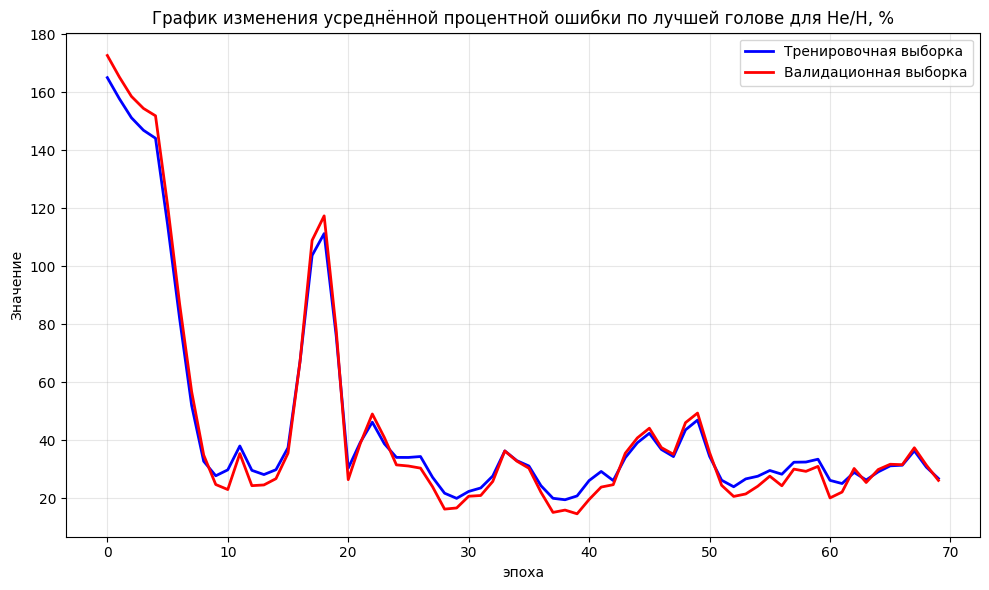

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

sns.lineplot(x=range(len(train_losses)), y=mape_train, label='Тренировочная выборка', color='blue', linewidth=2)
sns.lineplot(x=range(len(val_losses)), y=mape_val, label='Валидационная выборка', color='red', linewidth=2)

plt.title('График изменения усреднённой процентной ошибки по лучшей голове для He/H, %')
plt.xlabel('эпоха')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

sns.lineplot(x=range(len(train_losses)), y=mape_train, label='Тренировочная выборка', color='blue', linewidth=2)
sns.lineplot(x=range(len(val_losses)), y=mape_val, label='Валидационная выборка', color='red', linewidth=2)

plt.title('График изменения усреднённой процентной ошибки по лучшей голове для He/H, %')
plt.xlabel('эпоха')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Инференс параметрических моделей

In [ ]:
from utils import load_model_with_architecture
import torch
import numpy as np
from typing import Tuple, Union

def run_chronos_inference(
    model: torch.nn.Module,
    spectra: Union[np.ndarray, torch.Tensor],
    device: str = None,
    return_conf: bool = True
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Инференс MultiHeadChronosRegressor.
    Возвращает предсказания и оценки уверенности для ВСЕХ голов.
    
    Args:
        model: модель в режиме eval()
        spectra: np.array или torch.Tensor формы [batch, seq_len] или [seq_len]
        device: 'cuda'/'cpu'. Если None, берётся из весов модели
        return_conf: если False, возвращает только preds
        
    Returns:
        preds: torch.Tensor [batch, num_heads, output_dim]
        confs: torch.Tensor [batch, num_heads] (если return_conf=True)
    """
    if device is None:
        device = next(model.parameters()).device
        
    # 1. Нормализация входа
    if isinstance(spectra, np.ndarray):
        spectra = torch.from_numpy(spectra).float()
    if spectra.ndim == 1:
        spectra = spectra.unsqueeze(0)  # [1, seq_len]
        
    # 2. Перенос на устройство модели
    spectra = spectra.to(device)
    
    # 3. Инференс
    model.eval()
    with torch.no_grad():
        # Форсируем возврат всех голов, игнорируя легаси-ветку
        preds, confs = model(spectra, return_all=True, return_conf=return_conf)
        
    # 4. Возврат на CPU для дальнейшей обработки (matching, сохранение и т.д.)
    if return_conf:
        return preds.cpu(), confs.cpu()
    return preds.cpu(), None

# датасет и обучение scoring модели

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel

from chronos import ChronosPipeline
import torch
import torch.nn as nn

def parse_parameters(file_path):
    """
    Читает файл parameters.txt и возвращает словарь с нужными параметрами
    """
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                key = parts[0]
                value = ' '.join(parts[1:])  # на случай, если значение содержит пробелы
                params[key] = value
    # Извлекаем нужные параметры
    result = {}
    for param in ['PName', 'Msw', 'XUVInt', 'H2a', 'Helium']:
        result[param] = params.get(param)
    return result

def process_files_in_folder_with_params(root_folder):
    """
    Рекурсивно проходит по папке, читает параметры и файлы с данными
    Возвращает список словарей, где каждый словарь — это один файл
    """
    dataset = []
    root = Path(root_folder)
    for data_file_path in root.rglob('*[.txt,.dat]'):
        if data_file_path.name == 'parameters.txt':
            continue  # Пропускаем файл параметров

        # Ищем файл parameters.txt в той же папке
        param_file_path = data_file_path.parent / 'parameters.txt'

        if param_file_path.exists():
            params = parse_parameters(param_file_path)
            # print(f"Файл: {data_file_path}")
            # print(f"Параметры: {params}")
        else:
            # print(f"Файл parameters.txt не найден для {data_file_path}")
            params = {}

        # Читаем V и FullAbs из data файла
        try:
            V, FullAbs = np.loadtxt(data_file_path, usecols=(0, 1), unpack=True, skiprows=1)
            entry = {
                'V': V,
                'FullAbs': FullAbs,
                'PName': params.get('PName'),
                'Msw': params.get('Msw'),
                'XUVInt': params.get('XUVInt'),
                'H2a': params.get('H2a'),
                'Helium': params.get('Helium'),
                # 'File': str(data_file_path)  # можно убрать, если не нужно
            }
            dataset.append(entry)
        except Exception as e:
            print(f"Ошибка при загрузке данных из {data_file_path}: {e}")
        # print("-" * 50)

    return dataset

def pad_or_truncate(seq, target_len=101, pad_value=0.0):
    seq = np.array(seq, dtype=np.float32)
    if len(seq) > target_len:
        # Берём последние target_len значений
        return seq[-target_len:]
    elif len(seq) < target_len:
        # Дополняем СЛЕВА (чтобы "настоящие" данные были справа)
        padding = np.full(target_len - len(seq), pad_value, dtype=np.float32)
        return np.concatenate([padding, seq])
    else:
        return seq



# folder_path = 'new_dataset'  # Укажите путь к вашей папке
folder_path = "new_dataset_V3"
dataset = process_files_in_folder_with_params(folder_path)

df = pd.DataFrame(dataset)
# Применяем к каждой строке
df['FullAbs_fixed'] = df['FullAbs'].apply(lambda x: pad_or_truncate(x, target_len=101))
# Теперь все последовательности длиной 101
X = np.stack(df['FullAbs_fixed'].values)  # [N, 100]

# XXX пробуем только XUV, известно что скаллирование данных
# XXX делаем msw
Y = df[['XUVInt']].values.astype(np.float32)
# Y = df[['Helium']].values.astype(np.float32)

# Целевые переменные
# Y = df[['XUVInt', 'Msw', 'Helium']].values.astype(np.float32)  # [N,3]
# Y = df[['XUVInt', 'Helium']].values.astype(np.float32)  # [N,3]

# логарифмируем
Y_log = Y.copy()

# Логарифмируем ТОЛЬКО Msw (индекс 1)
# Msw - скорость солнечного ветра, положительная величина
# Y_log[:, 1] = np.log1p(Y[:, 1])  # log(1 + Msw)
# Нормализация
y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y_log)  # теперь ~ N(0,1) по каждой колонке

split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y_scaled[:split], Y_scaled[split:]
scaler_X = StandardScaler()

# # XXX добавление скалирования
X_train_scaled = scaler_X.fit_transform(X_train)  # shape (n, 101)
X_val_scaled = scaler_X.transform(X_val)
BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val)),
    batch_size=BATCH_SIZE
)


In [4]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

# =============================================================================
# 1. ЧТЕНИЕ И ПАРСИНГ
# =============================================================================
def parse_parameters(file_path):
    """Читает parameters.txt и возвращает словарь с float-значениями."""
    params = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                key = parts[0]
                val_str = parts[1]
                try:
                    params[key] = float(val_str)
                except ValueError:
                    params[key] = val_str  # оставляем как строку, если не число
    return params

def collect_dataset(root_folder, param_a='Msw', param_b='XUVInt'):
    """Собирает спектры и два выбранных параметра. Гарантирует порядок и float-типы."""
    root = Path(root_folder)
    # ✅ Фиксируем порядок файлов для воспроизводимости
    data_files = sorted([f for f in root.rglob('*') if f.suffix.lower() in {'.txt', '.dat'}])
    
    records = []
    for f in data_files:
        if f.name == 'parameters.txt':
            continue
            
        param_file = f.parent / 'parameters.txt'
        if not param_file.exists():
            continue
            
        p = parse_parameters(param_file)
        if param_a not in p or param_b not in p:
            continue  # пропускаем, если нужных параметров нет
            
        try:
            # Пропускаем 1 строку (заголовок), берём колонки 0 и 1
            V, FullAbs = np.loadtxt(f, usecols=(0, 1), unpack=True, skiprows=1)
            records.append({
                'spectrum': FullAbs,
                param_a: p[param_a],
                param_b: p[param_b]
            })
        except Exception as e:
            print(f"⚠️ Ошибка чтения {f.name}: {e}")
            
    print(f"✅ Загружено {len(records)} валидных спектров (параметры: {param_a}, {param_b})")
    return pd.DataFrame(records)

# =============================================================================
# 2. ПОДГОТОВКА И СКАЛИРОВАНИЕ
# =============================================================================
def pad_or_truncate(seq, target_len=101, pad_value=0.0):
    seq = np.asarray(seq, dtype=np.float32)
    if len(seq) > target_len:
        return seq[-target_len:]
    elif len(seq) < target_len:
        padding = np.full(target_len - len(seq), pad_value, dtype=np.float32)
        return np.concatenate([padding, seq])
    return seq

def prepare_loaders(df, test_size=0.2, random_state=42, 
                    param_a="Helium", param_b="XUVInt"):
    # Фиксируем длину спектров
    df['spectrum_fixed'] = df['spectrum'].apply(lambda x: pad_or_truncate(x, 101))
    
    X = np.stack(df['spectrum_fixed'].values)  # (N, 101)
    A = df[param_a].values.astype(np.float32)  # (N,)
    B = df[param_b].values.astype(np.float32)  # (N,)
    
    # ✅ Воспроизводимое разбиение
    X_train, X_val, A_train, A_val, B_train, B_val = train_test_split(
        X, A, B, test_size=test_size, random_state=random_state, shuffle=True
    )
    
    # 📏 Скалирование параметров (fit ТОЛЬКО на train!)
    scaler_ab = StandardScaler()
    
    # Объединяем A и B для корректного совместного скейлинга
    AB_train = scaler_ab.fit_transform(np.column_stack((A_train, B_train)))
    AB_val   = scaler_ab.transform(np.column_stack((A_val, B_val)))
    
    # Разделяем обратно
    A_train_scaled = AB_train[:, 0]
    B_train_scaled = AB_train[:, 1]
    A_val_scaled   = AB_val[:, 0]
    B_val_scaled   = AB_val[:, 1]
    
    # ✅ Возвращаем: спектры (сырые) + отмасштабированные параметры + сам скейлер
    return X_train, X_val, A_train_scaled, A_val_scaled, B_train_scaled, B_val_scaled, scaler_ab

# =============================================================================
# 3. PYTORCH DATASET & DATALOADER
# =============================================================================

def normalize_spectrum(S, method='area'):
    """
    S: (B, 101) или (101,)
    method: 'area' (интеграл=1) или 'max' (амплитуда=1)
    """
    if method == 'area':
        return S / (torch.sum(torch.abs(S), dim=-1, keepdim=True) + 1e-8)
    elif method == 'max':
        return S / (torch.max(torch.abs(S), dim=-1, keepdim=True).values + 1e-8)
    return S

class SpectralPairDataset(Dataset):
    """Возвращает (спектр, param_a, param_b) для обучения автоэнкодера/скорера."""
    def __init__(self, X_scaled, A, B):
        self.X = torch.tensor(X_scaled, dtype=torch.float32)
        self.A = torch.tensor(A, dtype=torch.float32)
        self.B = torch.tensor(B, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return normalize_spectrum(self.X[idx]), self.A[idx], self.B[idx]


In [5]:
PARAM_A = 'Helium'
PARAM_B = 'XUVInt'

folder_path = "new_dataset_V3"
df = collect_dataset(folder_path, param_a=PARAM_A, param_b=PARAM_B)
X_train_sc, X_val_sc, A_train, A_val, B_train, B_val, _scaler = prepare_loaders(df)
train_ds = SpectralPairDataset(X_train_sc, A_train, B_train)
val_ds   = SpectralPairDataset(X_val_sc, A_val, B_val)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


✅ Загружено 614 валидных спектров (параметры: Helium, XUVInt)


### Модель для скоринга пар 1 - на основе conditional autoencoder

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class ConditionalReconstructor(nn.Module):
    def __init__(self, seq_len=101, hidden_z=32, hidden_p=64, hidden_dec=128, dropout=0.25):
        super().__init__()
        # 🔹 Энкодер: S → z (контекст спектра)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.AdaptiveAvgPool1d(1)  # → (B, 32)
        )
        self.z_proj = nn.Linear(32, hidden_z)
        
        # 🔹 Проекция параметров: (a, b) → p
        self.param_proj = nn.Sequential(
            nn.Linear(2, hidden_p),
            nn.SiLU(),
            nn.Dropout(dropout)  # Dropout здесь важен для MC
        )
        
        # 🔹 Декодер: [z, p] → S_recon
        self.decoder = nn.Sequential(
            nn.Linear(hidden_z + hidden_p, hidden_dec),
            nn.ReLU(),
            # Разворачиваем в "псевдо-изображение" для 1D conv
            nn.Unflatten(1, (1, hidden_dec)),
            # 1D свёртки для локальных признаков
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 1, kernel_size=5, padding=2),  # выход: (B, 1, hidden_dec)
            nn.Flatten(),
            nn.Linear(hidden_dec, seq_len)  # финальная проекция
        )

    def forward(self, seq, a, b):
        """
        seq: (B, 101)
        a, b: (B,)
        return: (B, 101) → восстановленный спектр
        """
        z = self.encoder(seq.unsqueeze(1)).squeeze(-1)  # (B, 32)
        z = self.z_proj(z)                              # (B, hidden_z)
        
        params = torch.stack([a, b], dim=-1)            # (B, 2)
        p = self.param_proj(params)                     # (B, hidden_p)
        
        combined = torch.cat([z, p], dim=-1)            # (B, hidden_z+hidden_p)
        return self.decoder(combined)                   # (B, 101)

    def score_with_uncertainty(self, seq, a, b, n_mc=5):
        """
        Возвращает среднюю схожесть и её дисперсию по MC-проходам.
        Высокая дисперсия = зона вырождения.
        """
        self.train()  # Включаем dropout
        scores = []
        with torch.no_grad():
            for _ in range(n_mc):
                rec = self.forward(seq, a, b)
                # Косинусная схожесть формы (инвариантна к амплитуде)
                sim = F.cosine_similarity(rec.view(rec.size(0), -1), 
                                          seq.view(seq.size(0), -1), dim=1)
                scores.append(sim)
        self.eval()
        
        stacked = torch.stack(scores, dim=1)  # (B, n_mc)
        return stacked.mean(dim=1), stacked.std(dim=1)  # (B,), (B,)
    

class FiLMConditionalReconstructor(nn.Module):
    def __init__(self, seq_len=101, hidden_z=32, hidden_p=64, hidden_dec=128, dropout=0.25):
        super().__init__()
        # Энкодер (без изменений)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, padding=2), nn.ReLU(),
            nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.z_proj = nn.Linear(32, hidden_z)
        
        # FiLM-генератор: параметры → (gamma, beta) для каждого слоя декодера
        self.film_gen = nn.Sequential(
            nn.Linear(2, hidden_p),
            nn.SiLU(),
            nn.Linear(hidden_p, hidden_p)
        )
        # Для каждого из 3 слоёв декодера: 2 параметра (gamma, beta) × hidden_dec
        self.film_layers = nn.ModuleList([
            nn.Linear(hidden_p, hidden_dec * 2) for _ in range(3)
        ])
        
        # Декодер с FiLM-слоями
        self.dec_base = nn.Linear(hidden_z, hidden_dec)
        self.dec_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dec, hidden_dec),
                nn.ReLU(),
                nn.Dropout(dropout)
            ) for _ in range(3)
        ])
        self.dec_out = nn.Linear(hidden_dec, seq_len)

    def _apply_film(self, x, film_params):
        """Применяет адаптивную нормализацию: x' = gamma * x + beta"""
        gamma, beta = film_params.chunk(2, dim=-1)
        return gamma * x + beta

    def forward(self, seq, a, b):
        # Энкодинг
        z = self.encoder(seq.unsqueeze(1)).squeeze(-1)  # (B, 32)
        z = self.z_proj(z)                              # (B, hidden_z)
        
        # Генерация FiLM-параметров
        p_emb = self.film_gen(torch.stack([a, b], dim=-1))  # (B, hidden_p)
        
        # Декодер с кондиционированием
        x = self.dec_base(z)  # (B, hidden_dec)
        for i, (block, film_proj) in enumerate(zip(self.dec_blocks, self.film_layers)):
            x = block(x)
            film_params = film_proj(p_emb)  # (B, 2*hidden_dec)
            x = self._apply_film(x, film_params)
            
        return self.dec_out(x)  # (B, seq_len)
    

class ConvConditionalReconstructor(nn.Module):
    """
    Улучшенная архитектура: свёртки + остаточные связи + кондиционирование через FiLM.
    Индуктивное смещение для 1D сигналов.
    """
    def __init__(self, seq_len=101, hidden_z=64, hidden_p=64, 
                 base_channels=32, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        
        # 🔹 Энкодер (без изменений)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.z_proj = nn.Linear(32, hidden_z)
        
        # 🔹 FiLM-генератор для параметров
        self.film_gen = nn.Sequential(
            nn.Linear(2, hidden_p),
            nn.SiLU(),
            nn.Linear(hidden_p, hidden_p)
        )
        
        # 🔹 Декодер: Linear → Residual Conv1D Blocks → Output
        self.init_proj = nn.Linear(hidden_z, base_channels * seq_len)
        
        # Остаточные свёрточные блоки (3 блока с увеличением receptive field)
        self.conv_blocks = nn.ModuleList([
            ResidualConvBlock(base_channels, base_channels, kernel_size=5, 
                             dilation=1, dropout=dropout) for _ in range(2)
        ])
        self.conv_blocks.append(
            ResidualConvBlock(base_channels, base_channels, kernel_size=7, 
                             dilation=2, dropout=dropout)  # Больший receptive field
        )
        
        # Финальная проекция в спектр
        self.final_conv = nn.Sequential(
            nn.Conv1d(base_channels, 1, kernel_size=3, padding=1),
            nn.Sigmoid()  # Если спектры нормализованы к [0, 1]
        )
        
        # Позиционные эмбеддинги (помогают модели "понимать" положение в спектре)
        self.pos_emb = nn.Parameter(
            torch.randn(1, base_channels, seq_len) * 0.02
        )
        
    def forward(self, seq, a, b):
        B = seq.size(0)
        
        # Энкодинг
        z = self.encoder(seq.unsqueeze(1)).squeeze(-1)  # (B, 32)
        z = self.z_proj(z)                               # (B, hidden_z)
        
        # FiLM-параметры
        p_emb = self.film_gen(torch.stack([a, b], dim=-1))  # (B, hidden_p)
        
        # Инициализация декодера
        x = self.init_proj(z)                    # (B, base_channels * seq_len)
        x = x.view(B, -1, self.seq_len)          # (B, base_channels, seq_len)
        x = x + self.pos_emb.expand_as(x)        # + позиционные эмбеддинги
        
        # Применение кондиционирования (FiLM) к первому слою
        film_params = self.film_gen(torch.stack([a, b], dim=-1))
        gamma, beta = film_params.chunk(2, dim=-1)
        x = gamma.view(B, -1, 1) * x + beta.view(B, -1, 1)
        
        # Свёрточные блоки
        for block in self.conv_blocks:
            x = block(x)
            
        # Финальный выход
        return self.final_conv(x).squeeze(1)  # (B, seq_len)


class ResidualConvBlock(nn.Module):
    """Остаточный 1D-свёрточный блок с кондиционированием"""
    def __init__(self, in_ch, out_ch, kernel_size=5, dilation=1, dropout=0.1):
        super().__init__()
        padding = (kernel_size * dilation - dilation) // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_ch),
        )
        self.residual = nn.Identity() if in_ch == out_ch else nn.Conv1d(in_ch, out_ch, 1)
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        return self.act(self.dropout(self.conv(x) + self.residual(x)))

## трансформерный энкодер

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=101):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) # (1, L, D)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SpectralTransformerReconstructor(nn.Module):
    def __init__(self, seq_len=101, d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # 1. Входной проектор спектра
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, seq_len)
        
        # 2. Проекция параметров (Condition)
        self.param_proj = nn.Sequential(
            nn.Linear(2, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model)
        )
        
        # 3. Transformer Encoder Layer (Self-Attention для спектра)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Cross-Attention Decoder (Связывает спектр и параметры)
        # Мы используем тот же механизм, но Query - это скрытые состояния спектра, 
        # а Key/Value - это эмбеддинг параметров, расширенный по длине序列
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=2)
        
        # 5. Выходной проектор
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, 1)
        )

    def forward(self, seq, a, b):
        """
        seq: (B, 101)
        a, b: (B,)
        """
        B, L = seq.shape
        
        # 1. Embedding спектра + Pos Encoding
        x = self.input_proj(seq.unsqueeze(-1))  # (B, 101, d_model)
        x = self.pos_encoder(x)
        
        # 2. Self-Attention (улавливаем глобальные зависимости в спектре)
        memory = self.transformer_encoder(x)    # (B, 101, d_model)
        
        # 3. Embedding параметров
        p_emb = self.param_proj(torch.stack([a, b], dim=-1)) # (B, d_model)
        # Расширяем параметры до длины последовательности для Cross-Attention
        p_expanded = p_emb.unsqueeze(1).expand(-1, L, -1)    # (B, 101, d_model)
        
        # 4. Cross-Attention: Spectrum attends to Parameters
        # Query = memory (спектр), Key/Value = p_expanded (параметры)
        out = self.transformer_decoder(tgt=memory, memory=p_expanded) # (B, 101, d_model)
        
        # 5. Projection to output
        return self.output_proj(out).squeeze(-1) # (B, 101)

### ютилсичи

In [ ]:
def compute_spectral_metrics(S_pred, S_true, threshold=0.98, eps=1e-6):
    S_p = S_pred.view(S_pred.size(0), -1)
    S_t = S_true.view(S_true.size(0), -1)
    
    # 1. MSE
    mse = F.mse_loss(S_p, S_t).item()
    
    # 2. Cosine Similarity (форма)
    cos_sim = F.cosine_similarity(S_p, S_t, dim=1)
    avg_cos = cos_sim.mean().item()
    
    # 3. R² Score (стабильная версия)
    ss_res = torch.sum((S_p - S_t)**2, dim=1)
    ss_tot = torch.sum((S_t - torch.mean(S_t, dim=1, keepdim=True))**2, dim=1)
    # Защита от деления на ноль + ограничение снизу
    r2 = 1 - ss_res / (ss_tot + eps)
    r2 = torch.clamp(r2, min=-100, max=1).mean().item()  # обрезаем выбросы
    
    # 4. Shape Accuracy
    acc = (cos_sim > threshold).float().mean().item()
    
    # 5. НОВАЯ: Peak Relative Error (физически значимая для профилей)
    # Находим индекс пика в истинном спектре и сравниваем значения
    peak_idx = torch.argmax(S_t, dim=1)
    pred_at_peak = torch.gather(S_p, 1, peak_idx.unsqueeze(1)).squeeze()
    true_at_peak = torch.gather(S_t, 1, peak_idx.unsqueeze(1)).squeeze()
    peak_err = torch.abs(pred_at_peak - true_at_peak) / (true_at_peak + eps)
    avg_peak_err = peak_err.mean().item()
    
    return mse, avg_cos, r2, acc, avg_peak_err

class VoigtCompositeLoss(nn.Module):
    def __init__(self, alpha_mse=0.5, alpha_cos=1.5, alpha_peak=1.0, alpha_grad=0.3):
        super().__init__()
        self.alpha_mse = alpha_mse
        self.alpha_cos = alpha_cos
        self.alpha_peak = alpha_peak
        self.alpha_grad = alpha_grad  # Новый: штраф за размытие градиентов
        
    def forward(self, pred, target, eps=1e-8):
        p = pred.view(pred.size(0), -1)
        t = target.view(target.size(0), -1)
        
        # 1. MSE (базовый)
        l_mse = F.mse_loss(p, t)
        
        # 2. Cosine loss (форма) - УСИЛЕН
        l_cos = 1 - F.cosine_similarity(p, t, dim=1).mean()
        
        # 3. Peak loss (точность пика)
        peak_idx = torch.argmax(t, dim=1)
        p_peak = torch.gather(p, 1, peak_idx.unsqueeze(1)).squeeze()
        t_peak = torch.gather(t, 1, peak_idx.unsqueeze(1)).squeeze()
        l_peak = F.l1_loss(p_peak, t_peak) / (t_peak.abs().mean() + eps)
        
        # 4. НОВОЕ: Gradient loss (сохраняет резкие переходы/крылья)
        # Вычисляем градиенты вдоль спектральной оси
        grad_p = p[:, 1:] - p[:, :-1]
        grad_t = t[:, 1:] - t[:, :-1]
        l_grad = F.l1_loss(grad_p, grad_t)
        
        return (self.alpha_mse * l_mse + 
                self.alpha_cos * l_cos + 
                self.alpha_peak * l_peak +
                self.alpha_grad * l_grad)
    
class VoigtPhysicsLoss(nn.Module):
    def __init__(self, seq_len=101, alpha_mse=0.3, alpha_cos=1.0, 
                 alpha_peak=0.5, alpha_fwhm=0.3):
        super().__init__()
        self.alpha_mse = alpha_mse
        self.alpha_cos = alpha_cos
        self.alpha_peak = alpha_peak
        self.alpha_fwhm = alpha_fwhm
        # Позиционные эмбеддинги для расчёта "центра масс" спектра
        self.register_buffer('positions', torch.linspace(0, 1, seq_len))
        
    def _compute_fwhm(self, S):
        """Приблизительная оценка FWHM через порог 0.5 от максимума"""
        B = S.size(0)
        max_val = torch.max(S, dim=1, keepdim=True).values
        threshold = max_val * 0.5
        # Находим первый и последний индекс выше порога
        above = (S >= threshold).float()
        indices = torch.arange(S.size(1), device=S.device).unsqueeze(0).expand(B, -1)
        first = torch.sum(above * indices, dim=1) / (torch.sum(above, dim=1) + 1e-8)
        last = torch.sum(above * indices.flip(dims=[1]), dim=1) / (torch.sum(above, dim=1) + 1e-8)
        return (last - first).abs() / S.size(1)  # нормализованная ширина
        
    def forward(self, pred, target, eps=1e-8):
        p = pred.view(pred.size(0), -1)
        t = target.view(target.size(0), -1)
        
        # 1. Базовые метрики
        l_mse = F.mse_loss(p, t)
        l_cos = 1 - F.cosine_similarity(p, t, dim=1).mean()
        
        # 2. Peak loss (точность амплитуды и положения пика)
        peak_idx_t = torch.argmax(t, dim=1)
        peak_idx_p = torch.argmax(p, dim=1)
        l_peak_pos = F.l1_loss(peak_idx_p.float(), peak_idx_t.float()) / p.size(1)
        l_peak_val = F.l1_loss(
            torch.gather(p, 1, peak_idx_t.unsqueeze(1)).squeeze(),
            torch.gather(t, 1, peak_idx_t.unsqueeze(1)).squeeze()
        )
        l_peak = l_peak_pos + l_peak_val
        
        # 3. FWHM loss (сохранение ширины профиля)
        fwhm_p = self._compute_fwhm(p)
        fwhm_t = self._compute_fwhm(t)
        l_fwhm = F.l1_loss(fwhm_p, fwhm_t)
        
        return (self.alpha_mse * l_mse + 
                self.alpha_cos * l_cos + 
                self.alpha_peak * l_peak +
                self.alpha_fwhm * l_fwhm)

class NormalizedSpectralLoss(nn.Module):
    """
    Loss с автоматической нормализацией компонентов по их масштабу.
    Акцент на форму, а не на абсолютную ошибку.
    """
    def __init__(self, alpha_cos=1.0, alpha_peak=0.5, alpha_fwhm=0.3, 
                 alpha_acc=0.2, eps=1e-8):
        super().__init__()
        self.alpha_cos = alpha_cos
        self.alpha_peak = alpha_peak
        self.alpha_fwhm = alpha_fwhm
        self.alpha_acc = alpha_acc
        self.eps = eps
        
        # 🔹 Инициализация буферов с типом и устройством (важно для lerp_)
        # Начальные значения подобраны так, чтобы градиенты были ~1.0 на старте
        self.register_buffer('cos_scale', torch.tensor(0.1))      # 1-cos ~ 0.1
        self.register_buffer('peak_scale', torch.tensor(0.3))     # peak_err ~ 0.3
        self.register_buffer('fwhm_scale', torch.tensor(0.2))     # fwhm_err ~ 0.2
        
    def _compute_fwhm(self, S):
        """Оценка FWHM через порог 0.5 от максимума"""
        B = S.size(0)
        max_val = torch.max(S, dim=1, keepdim=True).values + self.eps
        threshold = max_val * 0.5
        above = (S >= threshold).float()
        indices = torch.arange(S.size(1), device=S.device).float().unsqueeze(0).expand(B, -1)
        
        first = torch.sum(above * indices, dim=1) / (torch.sum(above, dim=1) + self.eps)
        last = torch.sum(above * torch.flip(indices, dims=[1]), dim=1) / (torch.sum(above, dim=1) + self.eps)
        return torch.abs(last - first) / S.size(1)
    
    def _soft_accuracy(self, cos_sim, threshold=0.98, temperature=10.0):
        """Дифференцируемая аппроксимация Accuracy@threshold"""
        return torch.sigmoid((cos_sim - threshold) * temperature).mean()
    
    def forward(self, pred, target):
        p = pred.view(pred.size(0), -1)
        t = target.view(target.size(0), -1)
        
        # 1. Cosine loss (форма)
        cos_sim = F.cosine_similarity(p, t, dim=1)  # [B]
        l_cos_raw = 1 - cos_sim.mean()
        l_cos = l_cos_raw / (self.cos_scale + self.eps)
        
        # 2. Peak loss
        peak_idx_t = torch.argmax(t, dim=1)
        peak_idx_p = torch.argmax(p, dim=1)
        
        l_peak_pos = F.l1_loss(peak_idx_p.float() / p.size(1), 
                               peak_idx_t.float() / t.size(1))
        p_peak = torch.gather(p, 1, peak_idx_t.unsqueeze(1)).squeeze()
        t_peak = torch.gather(t, 1, peak_idx_t.unsqueeze(1)).squeeze()
        l_peak_val = F.l1_loss(p_peak, t_peak) / (t_peak.abs().mean() + self.eps)
        l_peak_raw = l_peak_pos + l_peak_val
        l_peak = l_peak_raw / (self.peak_scale + self.eps)
        
        # 3. FWHM loss
        fwhm_p = self._compute_fwhm(p)
        fwhm_t = self._compute_fwhm(t)
        l_fwhm_raw = F.l1_loss(fwhm_p, fwhm_t)
        l_fwhm = l_fwhm_raw / (self.fwhm_scale + self.eps)
        
        # 4. Soft Accuracy loss
        l_acc = 1 - self._soft_accuracy(cos_sim, threshold=0.98)
        
        # 🔹 ИСПРАВЛЕННОЕ ОБНОВЛЕНИЕ МАСШТАБОВ (в no_grad, с правильным lerp_)
        with torch.no_grad():
            momentum = 0.99
            # lerp_(end, weight) вычисляет: self + weight * (end - self)
            # Для EMA с моментом 0.99: weight = 1 - 0.99 = 0.01
            
            # Конвертируем скаляры в тензоры на том же устройстве!
            self.cos_scale.lerp_(
                torch.tensor(l_cos_raw.item(), device=self.cos_scale.device), 
                1 - momentum
            )
            self.peak_scale.lerp_(
                torch.tensor(l_peak_raw.item(), device=self.peak_scale.device), 
                1 - momentum
            )
            self.fwhm_scale.lerp_(
                torch.tensor(l_fwhm_raw.item(), device=self.fwhm_scale.device), 
                1 - momentum
            )
        
        # Итоговый loss
        return (self.alpha_cos * l_cos + 
                self.alpha_peak * l_peak + 
                self.alpha_fwhm * l_fwhm +
                self.alpha_acc * l_acc)

def augment_spectrum(S, max_shift=3, noise_std=0.01):
    """
    S: (B, 101)
    max_shift: максимальный сдвиг в точках (±)
    noise_std: уровень гауссова шума
    """
    B, L = S.shape
    S_aug = S.clone()
    
    for i in range(B):
        # 1. Случайный сдвиг
        shift = np.random.randint(-max_shift, max_shift+1)
        if shift != 0:
            S_aug[i] = torch.roll(S[i], shifts=shift, dims=0)
            # Обнуляем "выехавшие" края
            if shift > 0:
                S_aug[i, :shift] = 0
            else:
                S_aug[i, shift:] = 0
        
        # 2. Гауссов шум (физически мотивированный)
        noise = torch.randn_like(S_aug[i]) * noise_std * S_aug[i].abs().mean()
        S_aug[i] = S_aug[i] + noise
        
    return S_aug

def augment_parameters(A, B, rel_noise=0.2, mode='uniform', eps=1e-6):
    """
    Добавляет относительный шум ±rel_noise к параметрам.
    mode: 'uniform' (равномерный в [-20%, +20%]) или 'gaussian' (~95% в пределах ±20%)
    eps: защита от деления на ноль и отрицательных значений (физические параметры > 0)
    """
    A, B = A.float().view(-1), B.float().view(-1)
    
    # Физические параметры не могут быть ≤ 0
    A_safe = torch.clamp(A, min=eps)
    B_safe = torch.clamp(B, min=eps)
    
    if mode == 'uniform':
        noise_A = torch.rand_like(A_safe) * 2 * rel_noise - rel_noise
        noise_B = torch.rand_like(B_safe) * 2 * rel_noise - rel_noise
    elif mode == 'gaussian':
        # std = rel_noise / 2 → ~95% значений попадут в ±20%
        noise_A = torch.randn_like(A_safe) * (rel_noise / 2.0)
        noise_B = torch.randn_like(B_safe) * (rel_noise / 2.0)
    else:
        raise ValueError("mode должен быть 'uniform' или 'gaussian'")
        
    return A_safe * (1 + noise_A), B_safe * (1 + noise_B)

def augment_scaled_parameters(A_scaled, B_scaled, scaler_ab, rel_noise=0.2, mode='uniform'):
    """
    Корректно добавляет ±20% шум к параметрам, уже отмасштабированным StandardScaler.
    """
    device = A_scaled.device
    
    # 1. Обратное преобразование в физические значения
    AB_scaled = torch.stack([A_scaled, B_scaled], dim=1).cpu().numpy()
    AB_orig = scaler_ab.inverse_transform(AB_scaled)
    
    # 2. Аугментация в физическом пространстве
    A_orig, B_orig = torch.from_numpy(AB_orig[:, 0]), torch.from_numpy(AB_orig[:, 1])
    A_aug, B_aug = augment_parameters(A_orig, B_orig, rel_noise, mode)
    
    # 3. Снова масштабируем и возвращаем на GPU
    AB_aug = torch.stack([A_aug, B_aug], dim=1).numpy()
    AB_aug_scaled = scaler_ab.transform(AB_aug)
    
    return (torch.tensor(AB_aug_scaled[:, 0], device=device, dtype=torch.float32),
            torch.tensor(AB_aug_scaled[:, 1], device=device, dtype=torch.float32))



def voigt_physical_similarity(pred, target, eps=1e-8):
    """
    Возвращает схожесть на основе физических характеристик:
    - положение пика
    - амплитуда пика  
    - ширина на полувысоте (FWHM)
    - затухание крыльев
    """
    B, L = pred.size()
    
    # 1. Положение пика (нормализованное к [0, 1])
    peak_idx_p = torch.argmax(pred, dim=1).float() / L
    peak_idx_t = torch.argmax(target, dim=1).float() / L
    sim_pos = 1 - torch.abs(peak_idx_p - peak_idx_t)  # [0, 1]
    
    # 2. Амплитуда пика
    p_peak = torch.gather(pred, 1, torch.argmax(target, dim=1, keepdim=True)).squeeze()
    t_peak = torch.gather(target, 1, torch.argmax(target, dim=1, keepdim=True)).squeeze()
    sim_amp = 1 - torch.abs(p_peak - t_peak) / (t_peak.abs().mean() + eps)
    sim_amp = torch.clamp(sim_amp, 0, 1)
    
    # 3. FWHM (упрощённо)
    def estimate_fwhm(spec):
        max_val = torch.max(spec, dim=1, keepdim=True).values
        threshold = max_val * 0.5
        above = (spec >= threshold).float()
        width = above.sum(dim=1) / L  # нормализованная ширина
        return width
    
    fwhm_p = estimate_fwhm(pred)
    fwhm_t = estimate_fwhm(target)
    sim_fwhm = 1 - torch.abs(fwhm_p - fwhm_t)
    
    # 4. Затухание крыльев (сравнение хвостов)
    # Берём 10% точек с каждого края
    wing_len = L // 10
    left_p, right_p = pred[:, :wing_len], pred[:, -wing_len:]
    left_t, right_t = target[:, :wing_len], target[:, -wing_len:]
    sim_wings = 1 - (F.mse_loss(left_p, left_t) + F.mse_loss(right_p, right_t)) / 2
    sim_wings = torch.clamp(sim_wings, 0, 1)
    
    # Итоговая взвешенная схожесть
    return (0.3 * sim_pos + 0.3 * sim_amp + 0.25 * sim_fwhm + 0.15 * sim_wings)

class InfoNCEVoigtLoss(nn.Module):
    def __init__(self, similarity_fn, alpha_cos=2.0, alpha_contrast=0.4, temperature=0.20):
        super().__init__()
        self.alpha_cos = alpha_cos
        self.alpha_contrast = alpha_contrast
        self.temperature = temperature  # 🔑 Ключевой параметр для 20% шума
        self.similarity = similarity_fn
    def forward(self, S, recon_pos, recon_neg):
        # Схожести (чем больше, тем лучше)
        sim_pos = self.similarity(S, recon_pos)  # (B,)
        sim_neg = self.similarity(S, recon_neg)  # (B,)
        
        # 1. Лосс на качество восстановления (минимизируем 1 - sim)
        l_recon = 1.0 - sim_pos.mean()
        
        # 2. InfoNCE контрастивный лосс
        pos_exp = torch.exp(sim_pos / self.temperature)
        neg_exp = torch.exp(sim_neg / self.temperature)
        l_contrast = -torch.log(pos_exp / (pos_exp + neg_exp + 1e-8)).mean()
        
        return l_recon + self.alpha_contrast * l_contrast

class ContrastiveVoigtLoss(nn.Module):
    def __init__(self, alpha_cos=2.0, alpha_peak=0.7, alpha_fwhm=0.7, 
                 alpha_contrast=0.5, margin=0.4):
        super().__init__()
        self.alpha_cos = alpha_cos
        self.alpha_peak = alpha_peak
        self.alpha_fwhm = alpha_fwhm
        self.alpha_contrast = alpha_contrast
        self.margin = margin

    def _cosine(self, p, t):
        return F.cosine_similarity(p.view(p.size(0), -1), t.view(t.size(0), -1), dim=1)

    def _peak_fwhm_loss(self, pred, target):
        peak_idx_t = torch.argmax(target, dim=1)
        p_peak = torch.gather(pred, 1, peak_idx_t.unsqueeze(1)).squeeze()
        t_peak = torch.gather(target, 1, peak_idx_t.unsqueeze(1)).squeeze()
        l_peak = F.l1_loss(p_peak, t_peak) / (t_peak.abs().mean() + 1e-8)
        
        # Упрощённая FWHM (для скорости)
        B = pred.size(0)
        thresh = target.max(dim=1, keepdim=True).values * 0.5
        mask = (target >= thresh).float()
        idx = torch.arange(pred.size(1), device=pred.device).float()
        width = (mask.sum(dim=1) / pred.size(1))  # нормализованная ширина
        return l_peak + F.l1_loss(width, (mask.sum(dim=1) / pred.size(1)))

    def forward(self, S, recon_pos, recon_neg):
        # 1. Физические метрики для ПОЗИТИВНОЙ пары
        cos_pos = self._cosine(S, recon_pos).mean()
        l_cos = 1.0 - cos_pos
        l_phys = self._peak_fwhm_loss(recon_pos, S)
        
        # 2. Контрастивная часть: sim_pos должен быть > sim_neg + margin
        sim_pos = self._cosine(S, recon_pos)
        sim_neg = self._cosine(S, recon_neg)
        l_contrast = F.relu(self.margin - (sim_pos - sim_neg)).mean()
        
        return (self.alpha_cos * l_cos + 
                self.alpha_peak * l_phys + 
                self.alpha_fwhm * l_phys +  # используем тот же термин для ширины
                self.alpha_contrast * l_contrast)
    

class HybridVoigtSimilarity(nn.Module):
    """
    Комбинация физической метрики и взвешенного косинуса.
    Даёт и интерпретируемость, и сильный градиент для обучения.
    """
    def __init__(self, alpha_phys=0.4, alpha_cos=0.6, cos_sigma=10.0):
        super().__init__()
        self.alpha_phys = alpha_phys
        self.alpha_cos = alpha_cos
        self.cos_sigma = cos_sigma
        
    def _weighted_cosine(self, pred, target):
        """Взвешенный косинус с акцентом на пик"""
        B, L = pred.size()
        peak_idx = torch.argmax(target, dim=1)
        
        positions = torch.arange(L, device=pred.device).float().unsqueeze(0)
        peak_pos = peak_idx.float().unsqueeze(1)
        weights = torch.exp(-0.5 * ((positions - peak_pos) / self.cos_sigma) ** 2)
        
        num = torch.sum(weights * pred * target, dim=1)
        denom = torch.sqrt(
            torch.sum(weights * pred ** 2, dim=1) * 
            torch.sum(weights * target ** 2, dim=1) + 1e-8
        )
        return num / denom
    
    def _physical_similarity(self, pred, target, eps=1e-8):
        """Упрощённая физическая метрика (только пик + ширина)"""
        B, L = pred.size()
        
        # 1. Положение пика
        peak_idx_p = torch.argmax(pred, dim=1).float() / L
        peak_idx_t = torch.argmax(target, dim=1).float() / L
        sim_pos = 1 - torch.abs(peak_idx_p - peak_idx_t)
        
        # 2. Амплитуда пика
        p_peak = torch.gather(pred, 1, torch.argmax(target, dim=1, keepdim=True)).squeeze()
        t_peak = torch.gather(target, 1, torch.argmax(target, dim=1, keepdim=True)).squeeze()
        sim_amp = 1 - torch.abs(p_peak - t_peak) / (t_peak.abs().mean() + eps)
        sim_amp = torch.clamp(sim_amp, 0, 1)
        
        # 3. Упрощённая ширина (доля точек выше 50% максимума)
        def width_fraction(spec):
            max_val = torch.max(spec, dim=1, keepdim=True).values
            threshold = max_val * 0.5
            return ((spec >= threshold).sum(dim=1).float() / L).clamp(0, 1)
        
        sim_width = 1 - torch.abs(width_fraction(pred) - width_fraction(target))
        
        # Взвешенная сумма (упрощено для скорости)
        return 0.4 * sim_pos + 0.4 * sim_amp + 0.2 * sim_width
    
    def forward(self, pred, target):
        cos_sim = self._weighted_cosine(pred, target)
        phys_sim = self._physical_similarity(pred, target)
        return self.alpha_cos * cos_sim + self.alpha_phys * phys_sim

import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score

def validate_contrastive(model, val_loader, similarity_fn, 
                         device='cuda', threshold=0.7, compute_mse=True):
    """
    Универсальная валидация для контрастивного обучения.
    
    Args:
        similarity_fn: функция (pred, target) -> Tensor(B,) с метрикой схожести (чем больше, тем лучше)
        threshold: порог отвержения негативов (зависит от диапазона метрики!)
    """
    model.eval()
    
    sim_pos_list, sim_neg_list = [], []
    mse_pos_list = []
    labels_list, scores_list = [], []
    
    with torch.no_grad():
        for S_batch, a_batch, b_batch in val_loader:
            S_batch, a_batch, b_batch = S_batch.to(device), a_batch.to(device), b_batch.to(device)
            
            # 1. Реконструкции
            recon_pos = model(S_batch, a_batch, b_batch)
            a_neg, b_neg = make_negative_pairs(a_batch, b_batch)
            recon_neg = model(S_batch, a_neg, b_neg)
            
            # 2. Схожести через переданную метрику
            sim_pos = similarity_fn(recon_pos, S_batch).view(-1).cpu().numpy()
            sim_neg = similarity_fn(recon_neg, S_batch).view(-1).cpu().numpy()
            
            sim_pos_list.extend(sim_pos)
            sim_neg_list.extend(sim_neg)
            
            if compute_mse:
                mse_pos = F.mse_loss(recon_pos, S_batch, reduction='none').mean(dim=1).cpu().numpy()
                mse_pos_list.extend(mse_pos)
                
            # Для ROC-AUC
            labels_list.extend([1] * len(sim_pos) + [0] * len(sim_neg))
            scores_list.extend(sim_pos.tolist() + sim_neg.tolist())
            
    # Агрегация
    sim_pos_mean = np.mean(sim_pos_list)
    sim_neg_mean = np.mean(sim_neg_list)
    gap = sim_pos_mean - sim_neg_mean
    
    # Доля негативов ниже порога (чем выше, тем лучше модель их отсекает)
    neg_rejected = np.mean(np.array(sim_neg_list) < threshold)
    
    try:
        auc = roc_auc_score(labels_list, scores_list)
    except ValueError:
        auc = 0.5
        
    metrics = {
        'sim_pos': sim_pos_mean,
        'sim_neg': sim_neg_mean,
        'gap': gap,
        'neg_rejected': neg_rejected,
        'auc': auc,
        'sim_pos_std': np.std(sim_pos_list),
        'sim_neg_std': np.std(sim_neg_list),
    }
    if compute_mse:
        metrics['mse_pos'] = np.mean(mse_pos_list)
        
    return metrics

## обучение

In [24]:


N_EPOCHS = 150  # Увеличиваем, т.к. новая loss сложнее
best_val_loss = float('inf')
PATIENCE = 15
best_gap  = -1.0
# model = FiLMConditionalReconstructor(dropout=0.1).to('cuda')
# model = ConvConditionalReconstructor(dropout=0.1).to('cuda')
model = SpectralTransformerReconstructor(d_model=128, nhead=4, num_layers=3).to('cuda')


# criterion = VoigtPhysicsLoss(alpha_mse=0.01, alpha_cos=2, alpha_peak=0.7, alpha_fwhm=0.7)
# criterion = NormalizedSpectralLoss(alpha_cos=1, alpha_peak=0.7, 
#                                    alpha_fwhm=0.7, alpha_acc=0.5)
# criterion = ContrastiveVoigtLoss(alpha_cos=1.0, alpha_peak=0.7, alpha_fwhm=0.7, 
#                                  alpha_contrast=0.7, margin=0.2)
# criterion = InfoNCEVoigtLoss(alpha_cos=1, alpha_contrast=0.7, temperature=0.2)
sim_metric = HybridVoigtSimilarity(alpha_phys=0.4, alpha_cos=0.6, cos_sigma=10.0)

criterion = InfoNCEVoigtLoss(
    alpha_contrast=0.4, 
    temperature=0.10,  # 🔹 Было 0.20, ставим 0.10 для более резкого разделения
    similarity_fn=sim_metric
)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10, verbose=True, min_lr=1e-6
)

# sim_metric = voigt_physical_similarity()

for epoch in range(N_EPOCHS):
    # === TRAIN ===
    model.train()
    train_loss = 0.0
    for S_batch, a_batch, b_batch in train_loader:
        S_batch, a_batch, b_batch = S_batch.to('cuda'), a_batch.to('cuda'), b_batch.to('cuda')
        # S_batch = augment_spectrum(S_batch, max_shift=2, noise_std=0.02)
        a_batch, b_batch = augment_scaled_parameters(a_batch, b_batch, _scaler, 
                                                        rel_noise=0.1, mode='gaussian')
        
        a_neg, b_neg = make_negative_pairs(a_batch, b_batch)

        optimizer.zero_grad()

        # S_recon = model(S_batch, a_batch, b_batch)
        recon_pos = model(S_batch, a_batch, b_batch)  # правильные параметры
        recon_neg = model(S_batch, a_neg, b_neg)      # перемешанные параметры
        # loss = criterion(S_recon, S_batch)
        loss = criterion(S_batch, recon_pos, recon_neg)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # === VAL +==
    model.eval()
    val_metrics = validate_contrastive(
                                        model=model,
                                        val_loader=val_loader,
                                        similarity_fn=lambda p, t: sim_metric(p, t),
                                        threshold=0.75,  # Подстроено под Hybrid
                                        device='cuda'
                                    )
    
    # Scheduler по зазору (gap) — это главная метрика контрастивного обучения
    scheduler.step(val_metrics['gap'])
    
    # Логирование
    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
          f"Sim⁺: {val_metrics['sim_pos']:.4f} | Sim⁻: {val_metrics['sim_neg']:.4f} | "
      f"Gap: {val_metrics['gap']:.4f} | NegRej: {val_metrics['neg_rejected']:.4f} | AUC: {val_metrics['auc']:.4f}")
    
    # Сохранение по зазору (gap) + качеству позитивов
    if val_metrics['gap'] > best_gap and val_metrics['sim_pos'] > 0.95:
        best_gap = val_metrics['gap']
        # torch.save(model.state_dict(), 'best_contrastive_recon.pt')
        save_model_with_architecture(model, f"best_voigt_reconstructor_{best_gap}.pkl")

        print(f"✅ Saved Best: Gap={val_metrics['gap']:.4f}, sim⁺={val_metrics['sim_pos']:.4f}")
        
    # # Early stopping: если зазор большой и позитивы качественные
    # if val_metrics['gap'] > 0.25 and val_metrics['cos_pos'] > 0.96:
    #     print("🎯 Target contrastive quality reached!")
    #     break



    # === VAL === (legacy)
    # model.eval()
    # val_mse, val_cos, val_r2, val_acc, val_peak_err = 0, 0, 0, 0, 0
    # with torch.no_grad():
    #     for S_batch, a_batch, b_batch in val_loader:
    #         S_batch, a_batch, b_batch = S_batch.to('cuda'), a_batch.to('cuda'), b_batch.to('cuda')
    #         S_recon = model(S_batch, a_batch, b_batch)
    #         m, c, r, a, p = compute_spectral_metrics(S_recon, S_batch)
    #         val_mse += m; val_cos += c; val_r2 += r; val_acc += a; val_peak_err += p
            
    # n = len(val_loader)
    # val_mse, val_cos, val_r2, val_acc, val_peak_err = [x/n for x in [val_mse, val_cos, val_r2, val_acc, val_peak_err]]
    
    # # Scheduler по косинусной схожести (важнее для формы!)
    # val_cos_improved = val_cos > 0.95  # Целевой порог
    # scheduler.step(val_cos)  # Мониторим косинус
    
    # print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
    #       f"Val MSE: {val_mse:.5f} | Cos: {val_cos:.4f} | R²: {val_r2:.2f} | "
    #       f"Acc@0.98: {val_acc:.4f} | PeakErr: {val_peak_err:.4f}")
    # i = 0
    # # Сохраняем по косинусной схожести, а не MSE!
    # if val_cos > 0.97 and val_acc > 0.7:  # Пороги качества
    #     # torch.save(model.state_dict(), 'best_voigt_reconstructor.pt')
    #     save_model_with_architecture(model, f"best_voigt_reconstructor_{i}.pkl")
    #     i+=1
    #     print("✅ Quality checkpoint saved")
        
    # if (1 - val_cos) < 0.03:  # Early stopping по форме
    #     print("⏹ Target shape quality reached")
    #     break

/home/kirill/diploma/venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 000 | Train Loss: 0.7106 | Sim⁺: 0.7731 | Sim⁻: 0.7648 | Gap: 0.0083 | NegRej: 0.1138 | AUC: 0.5457
Epoch 001 | Train Loss: 0.4935 | Sim⁺: 0.7665 | Sim⁻: 0.7662 | Gap: 0.0003 | NegRej: 0.2520 | AUC: 0.4970
Epoch 002 | Train Loss: 0.4788 | Sim⁺: 0.7729 | Sim⁻: 0.7414 | Gap: 0.0316 | NegRej: 0.1789 | AUC: 0.5297
Epoch 003 | Train Loss: 0.4615 | Sim⁺: 0.8004 | Sim⁻: 0.7965 | Gap: 0.0038 | NegRej: 0.1220 | AUC: 0.5263
Epoch 004 | Train Loss: 0.4506 | Sim⁺: 0.8008 | Sim⁻: 0.7940 | Gap: 0.0069 | NegRej: 0.1382 | AUC: 0.5732
Epoch 005 | Train Loss: 0.4610 | Sim⁺: 0.7936 | Sim⁻: 0.7840 | Gap: 0.0096 | NegRej: 0.1463 | AUC: 0.5978
Epoch 006 | Train Loss: 0.4497 | Sim⁺: 0.7996 | Sim⁻: 0.7949 | Gap: 0.0047 | NegRej: 0.1545 | AUC: 0.5846
Epoch 007 | Train Loss: 0.4490 | Sim⁺: 0.7904 | Sim⁻: 0.7699 | Gap: 0.0206 | NegRej: 0.1545 | AUC: 0.5778
Epoch 008 | Train Loss: 0.4393 | Sim⁺: 0.7767 | Sim⁻: 0.7591 | Gap: 0.0176 | NegRej: 0.2195 | AUC: 0.5555
Epoch 009 | Train Loss: 0.4348 | Sim⁺: 0.7833 

## пробуем сравнивать не спектры, а эмбеддинги

ютилсичи

In [1]:
from sklearn.metrics import roc_auc_score
import torch
def sharpen_spectrum(signal, amount=0.5, kernel_size=3):
    """
    Заострение спектра (unsharp mask) для 1D сигнала.
    Делает пики более выраженными и узкими.
    
    Args:
        signal: (B, L) или (L,)
        amount: сила заострения (0.2-0.8 оптимально)
        kernel_size: размер ядра сглаживания (3 или 5)
    """
    original_shape = signal.shape
    if signal.dim() == 1:
        signal = signal.unsqueeze(0)  # (1, L)
    
    B, L = signal.shape
    signal_unsqueezed = signal.unsqueeze(1)  # (B, 1, L)
    
    # Сглаживание
    blur = torch.nn.functional.avg_pool1d(
        signal_unsqueezed, kernel_size, stride=1, padding=kernel_size//2
    ).squeeze(1)  # (B, L)
    
    # Unsharp mask: sharpened = original + amount * (original - blur)
    sharpened = signal + amount * (signal - blur)
    
    if len(original_shape) == 1:
        sharpened = sharpened.squeeze(0)
    
    return sharpened

def sharpen_spectrum_adaptive(signal, percentile=90, max_amount=0.8):
    """
    Адаптивное заострение: сильнее для сигналов с острыми пиками.
    
    Args:
        signal: (B, L)
        percentile: процентиль для оценки "остроконечности"
        max_amount: максимальная сила заострения
    """
    # Оценка остроты пиков (отношение максимума к среднему)
    max_val = signal.max(dim=-1, keepdim=True)[0]
    mean_val = signal.abs().mean(dim=-1, keepdim=True)
    sharpness_ratio = max_val / (mean_val + 1e-8)
    
    # Нормируем силу заострения
    amount = (sharpness_ratio / sharpness_ratio.max()) * max_amount
    amount = amount.clamp(0.1, max_amount)
    
    return sharpen_spectrum(signal, amount=amount.mean().item(), kernel_size=3)

def add_realistic_noise(signal, snr_db=40):
    """Добавляет белый шум с заданным SNR."""
    signal_power = (signal ** 2).mean(dim=-1, keepdim=True)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise_std = torch.sqrt(noise_power)
    return signal + noise_std * torch.randn_like(signal)


def augment_spectrum_noise_and_sharpen(S, 
                                       snr_db=40,
                                       sharpen_prob=0.5,
                                       sharpen_amount=0.5,
                                       scale_range=(0.95, 1.05)):
    """
    Аугментация: шум (SNR) + заострение + масштабирование.
    """
    B, L = S.shape
    device = S.device
    S_aug = S.clone()
    
    # 1. Белый шум
    S_aug = add_realistic_noise(S_aug, snr_db=snr_db)
    
    # 2. Заострение
    if torch.rand(1) < sharpen_prob:
        S_aug = sharpen_spectrum_adaptive(S_aug, max_amount=sharpen_amount)
    
    # 3. Масштабирование
    scale = scale_range[0] + torch.rand(B, 1, device=device) * (scale_range[1] - scale_range[0])
    S_aug = S_aug * scale
    
    return S_aug

def make_hard_negative_pairs_soft_tradeoff(a, b, tradeoff_strength=0.3, n_bins=5):
    """
    Мягкий учет tradeoff: не жесткое правило, а взвешенная метрика.
    
    Args:
        tradeoff_strength: 0-1, насколько сильно учитывать корреляцию
        0 =完全不 учитывать (стандартное бинирование)
        1 = полностью учитывать (a*b ≈ const)
    """
    B = a.size(0)
    device = a.device
    
    # Нормализуем
    a_norm = (a - a.min()) / (a.max() - a.min() + 1e-8)
    b_norm = (b - b.min()) / (b.max() - b.min() + 1e-8)
    
    # 1. Стандартное расстояние в пространстве параметров
    param_dist = torch.abs(a_norm.unsqueeze(1) - a_norm.unsqueeze(0)) + \
                 torch.abs(b_norm.unsqueeze(1) - b_norm.unsqueeze(0))
    
    # 2. Штраф за "подозрительные" пары (которые могли бы быть эквивалентны из-за tradeoff)
    # Чем ближе a1*b1 к a2*b2, тем больше штраф
    product1 = a_norm * b_norm
    product2 = product1.unsqueeze(1)
    product_similarity = 1 - torch.abs(product1.unsqueeze(1) - product2) / (product1.max() - product1.min() + 1e-8)
    
    # 3. Комбинированная метрика
    # Для пар с похожим произведением УМЕНЬШАЕМ расстояние (они менее "hard")
    tradeoff_penalty = 1 - tradeoff_strength * product_similarity
    effective_dist = param_dist * tradeoff_penalty
    
    # 4. Исключаем слишком похожие (другой параметрический бин - опционально)
    if n_bins > 0:
        a_bin = (a_norm * (n_bins - 1)).long().clamp(0, n_bins - 1)
        b_bin = (b_norm * (n_bins - 1)).long().clamp(0, n_bins - 1)
        same_bin = (a_bin.unsqueeze(1) == a_bin.unsqueeze(0)) & \
                   (b_bin.unsqueeze(1) == b_bin.unsqueeze(0))
        same_bin.fill_diagonal_(False)
        effective_dist[same_bin] = 0  # штрафуем одинаковые бины
    
    # 5. Выбираем farthest с учетом tradeoff
    effective_dist.fill_diagonal_(-1)
    hardest_idx = effective_dist.argmax(dim=1)
    
    return a[hardest_idx], b[hardest_idx]

def make_hard_negative_pairs(a, b, n_bins=5):
    """
    Делит батч на бины по параметрам и берёт негативы из других бинов.
    Гарантирует, что негатив имеет существенно другие параметры.
    """
    B = a.size(0)
    device = a.device
    
    # Нормализуем для бинирования
    a_norm = (a - a.min()) / (a.max() - a.min() + 1e-8)
    b_norm = (b - b.min()) / (b.max() - b.min() + 1e-8)
    
    # Создаём 2D бины (n_bins × n_bins)
    a_bin = (a_norm * (n_bins - 1)).long().clamp(0, n_bins - 1)
    b_bin = (b_norm * (n_bins - 1)).long().clamp(0, n_bins - 1)
    bin_id = a_bin * n_bins + b_bin  # уникальный ID бина
    
    perm_indices = torch.zeros(B, dtype=torch.long, device=device)
    
    for i in range(B):
        my_bin = bin_id[i]
        # Кандидаты: все из ДРУГИХ бинов
        other_bins = bin_id != my_bin
        # И не сам себя
        other_bins[i] = False
        
        if other_bins.sum() > 0:
            # Случайный пример из другого бина
            candidates = torch.where(other_bins)[0]
            perm_indices[i] = candidates[torch.randint(0, len(candidates), (1,), device=device)]
        else:
            # Все в одном бине — берём farthest по расстоянию
            a_dist = (a_norm[i] - a_norm).abs()
            b_dist = (b_norm[i] - b_norm).abs()
            total_dist = a_dist + b_dist
            total_dist[i] = -1  # исключаем себя
            perm_indices[i] = total_dist.argmax()
    
    return a[perm_indices], b[perm_indices]


@torch.no_grad()
def validate_with_negatives(model, loader, device, neg_type='shuffle', margin=None):
    model.eval()
    cos = nn.CosineSimilarity(dim=-1)
    all_sim_pos = []
    all_sim_neg = []
    
    for S, a, b in loader:
        S, a, b = S.to(device), a.to(device), b.to(device)
        a, b = augment_scaled_parameters(a, b, _scaler, 
                                                        rel_noise=0.1, mode='gaussian')
        B = S.size(0)
        
        # Позитивные эмбеддинги
        z_spec, z_param_pos,_,_  = model(S, a, b)   # (B, D) each
        
        # Генерация негативных параметров
        if neg_type == 'shuffle':
            a_neg, b_neg = make_hard_negative_pairs(a, b)
        else:
            raise ValueError(f"Unknown neg_type: {neg_type}")
        
        # Эмбеддинги негативных параметров (спектр тот же)
        _, z_param_neg,_,_  = model(S, a_neg, b_neg)   # (B, D)
        
        # Косинусные сходства
        sim_pos = cos(z_spec, z_param_pos)   # (B,)
        sim_neg = cos(z_spec, z_param_neg)   # (B,)
        
        all_sim_pos.append(sim_pos.cpu())
        all_sim_neg.append(sim_neg.cpu())
    
    all_sim_pos = torch.cat(all_sim_pos)   # (N,)
    all_sim_neg = torch.cat(all_sim_neg)   # (N,)
    
    # Метрики
    sim_pos_mean = all_sim_pos.mean().item()
    sim_neg_mean = all_sim_neg.mean().item()
    gap = sim_pos_mean - sim_neg_mean
    
    # Доля отвергнутых негативов (по порогу)
    threshold = 0.75   # можно передавать параметром
    neg_rejected = (all_sim_neg < threshold).float().mean().item()
    
    # AUC: позитивы vs негативы
    scores = torch.cat([all_sim_pos, all_sim_neg]).numpy()
    labels = np.concatenate([np.ones(len(all_sim_pos)), np.zeros(len(all_sim_neg))])
    auc = roc_auc_score(labels, scores)
    
    return {
        'sim_pos': sim_pos_mean,
        'sim_neg': sim_neg_mean,
        'gap': gap,
        'neg_rejected': neg_rejected,
        'auc': auc
    }

def augment_parameters(A, B, rel_noise=0.2, mode='uniform', eps=1e-6):
    """
    Добавляет относительный шум ±rel_noise к параметрам.
    mode: 'uniform' (равномерный в [-20%, +20%]) или 'gaussian' (~95% в пределах ±20%)
    eps: защита от деления на ноль и отрицательных значений (физические параметры > 0)
    """
    A, B = A.float().view(-1), B.float().view(-1)
    
    # Физические параметры не могут быть ≤ 0
    A_safe = torch.clamp(A, min=eps)
    B_safe = torch.clamp(B, min=eps)
    
    if mode == 'uniform':
        noise_A = torch.rand_like(A_safe) * 2 * rel_noise - rel_noise
        noise_B = torch.rand_like(B_safe) * 2 * rel_noise - rel_noise
    elif mode == 'gaussian':
        # std = rel_noise / 2 → ~95% значений попадут в ±20%
        noise_A = torch.randn_like(A_safe) * (rel_noise / 2.0)
        noise_B = torch.randn_like(B_safe) * (rel_noise / 2.0)
    else:
        raise ValueError("mode должен быть 'uniform' или 'gaussian'")
        
    return A_safe * (1 + noise_A), B_safe * (1 + noise_B)

def augment_scaled_parameters(A_scaled, B_scaled, scaler_ab, rel_noise=0.2, mode='uniform'):
    """
    Корректно добавляет ±20% шум к параметрам, уже отмасштабированным StandardScaler.
    """
    device = A_scaled.device
    
    # 1. Обратное преобразование в физические значения
    AB_scaled = torch.stack([A_scaled, B_scaled], dim=1).cpu().numpy()
    AB_orig = scaler_ab.inverse_transform(AB_scaled)
    
    # 2. Аугментация в физическом пространстве
    A_orig, B_orig = torch.from_numpy(AB_orig[:, 0]), torch.from_numpy(AB_orig[:, 1])
    A_aug, B_aug = augment_parameters(A_orig, B_orig, rel_noise, mode)
    
    # 3. Снова масштабируем и возвращаем на GPU
    AB_aug = torch.stack([A_aug, B_aug], dim=1).numpy()
    AB_aug_scaled = scaler_ab.transform(AB_aug)
    
    return (torch.tensor(AB_aug_scaled[:, 0], device=device, dtype=torch.float32),
            torch.tensor(AB_aug_scaled[:, 1], device=device, dtype=torch.float32))

модели и лосы

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F


import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=101):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) # (1, L, D)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]
    
    
class TripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin
        self.cos = nn.CosineSimilarity(dim=-1)

    def forward(self, anchor, positive, negative):
        pos_sim = self.cos(anchor, positive)
        neg_sim = self.cos(anchor, negative)
        # Triplet: хотим neg_sim + margin < pos_sim
        loss = torch.clamp(neg_sim - pos_sim + self.margin, min=0.0)
        return loss.mean()


def info_nce_with_negatives(anchor, positive, negatives, temperature=0.07):
    """
    anchor:   (B, D)    – z_spec
    positive: (B, D)    – z_param для правильных параметров
    negatives: (B, K, D) – z_param для K неправильных параметров
    """
    B = anchor.size(0)
    anchor = F.normalize(anchor, dim=-1)
    positive = F.normalize(positive, dim=-1)
    negatives = F.normalize(negatives, dim=-1)

    pos_logit = (anchor * positive).sum(dim=-1) / temperature          # (B,)
    neg_logits = torch.bmm(anchor.unsqueeze(1), negatives.transpose(1,2)).squeeze(1) / temperature  # (B, K)

    logits = torch.cat([pos_logit.unsqueeze(1), neg_logits], dim=1)    # (B, 1+K)
    labels = torch.zeros(B, dtype=torch.long, device=logits.device)
    return F.cross_entropy(logits, labels)

class SpectralParamContrastiveDecoder(nn.Module):
    def __init__(self, seq_len=101, d_model=128, nhead=4, num_encoder_layers=3,
                 num_decoder_layers=2, dim_feedforward=256, dropout=0.1, proj_dim=64):
        super().__init__()
        self.seq_len = seq_len
        # ---- Энкодер спектра (общий) ----
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, seq_len)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_encoder_layers)

        # ---- Проекция параметров в key/value ----
        self.param_to_kv = nn.Linear(2, d_model)   # один вектор, но мы расширим по длине

        # ---- Декодер: cross-attention к параметрам ----
        dec_layer = nn.TransformerDecoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_decoder_layers)

        # ---- Пулинг и проекционные головы ----
        self.spec_pool = nn.AdaptiveAvgPool1d(1)   # mean по времени
        self.param_pool = nn.AdaptiveAvgPool1d(1)

        self.spec_head = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim)                 # LayerNorm вместо BatchNorm – меньше коллапса
        )
        self.param_head = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim)
        )

    def forward(self, S, a, b):
        B, L = S.shape
        # 1. Кодируем спектр
        x = self.input_proj(S.unsqueeze(-1))
        x = self.pos_encoder(x)
        memory = self.encoder(x)                 # (B, L, d_model)

        # 2. Эмбеддинг спектра (не зависит от параметров)
        z_spec = self.spec_pool(memory.transpose(1,2)).squeeze(-1)   # (B, d_model)
        z_spec = self.spec_head(z_spec)                             # (B, proj_dim)

        # 3. Параметры -> key/value memory для декодера
        param_feat = self.param_to_kv(torch.stack([a, b], dim=-1))  # (B, d_model)
        # Расширяем до L по времени (каждый таймстеп видит один и тот же вектор параметров)
        kv_memory = param_feat.unsqueeze(1).expand(-1, L, -1)      # (B, L, d_model)

        # 4. Декодер: query = memory (спектр), key/value = kv_memory (параметры)
        decoded = self.decoder(tgt=memory, memory=kv_memory)        # (B, L, d_model)

        # 5. Эмбеддинг параметров = pool(decoded) + skip‑connection от param_feat
        decoded_pooled = self.param_pool(decoded.transpose(1,2)).squeeze(-1)  # (B, d_model)
        # Явно добавляем параметры, чтобы они не терялись при пулинге
        z_param = decoded_pooled + param_feat
        z_param = self.param_head(z_param)                         # (B, proj_dim)

        return z_spec, z_param
    

    class SpectralParamClip(nn.Module):
        def __init__(self, seq_len=101, d_model=128, nhead=4, num_layers=3,
                    dim_feedforward=256, dropout=0.1, proj_dim=64):
            super().__init__()
            # Энкодер спектра (Transformer)
            self.input_proj = nn.Linear(1, d_model)
            self.pos_encoder = PositionalEncoding(d_model, seq_len)
            enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
            self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
            self.spec_pool = nn.AdaptiveAvgPool1d(1)
            self.spec_head = nn.Sequential(nn.Linear(d_model, proj_dim), nn.BatchNorm1d(proj_dim))

            # Энкодер параметров (MLP)
            self.param_mlp = nn.Sequential(
                nn.Linear(2, d_model), nn.SiLU(),
                nn.Linear(d_model, d_model), nn.SiLU(),
                nn.Linear(d_model, proj_dim),
                nn.BatchNorm1d(proj_dim)
            )

        def forward(self, S, a, b):
            # Спектр
            x = self.input_proj(S.unsqueeze(-1))
            x = self.pos_encoder(x)
            x = self.encoder(x)
            z_spec = self.spec_pool(x.transpose(1,2)).squeeze(-1)
            z_spec = self.spec_head(z_spec)

            # Параметры
            p = torch.stack([a, b], dim=-1)
            z_param = self.param_mlp(p)
            return z_spec, z_param

class SpectralParamTwoTower(nn.Module):
    def __init__(self, seq_len=101, d_model=128, nhead=4, num_layers=3,
                 dim_feedforward=256, dropout=0.1, proj_dim=64):
        super().__init__()
        # Энкодер спектра (Transformer)
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, seq_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
        self.spec_pool = nn.AdaptiveAvgPool1d(1)
        self.spec_head = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

        # Энкодер параметров (чистый MLP, без спектра)
        self.param_mlp = nn.Sequential(
            nn.Linear(2, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

    def forward(self, S, a, b):
        # Кодируем спектр
        x = self.input_proj(S.unsqueeze(-1))
        x = self.pos_encoder(x)
        x = self.encoder(x)                         # (B, L, d_model)
        z_spec = self.spec_pool(x.transpose(1,2)).squeeze(-1)  # (B, d_model)
        z_spec = self.spec_head(z_spec)             # (B, proj_dim)

        # Кодируем параметры
        p = torch.stack([a, b], dim=-1)             # (B, 2)
        z_param = self.param_mlp(p)                 # (B, proj_dim)

        return z_spec, z_param
    
class RobustContrastiveLoss(nn.Module):
    def __init__(self, margin=0.2):
        super().__init__()
        self.margin = margin

    def forward(self, z_spec: torch.Tensor, z_pos: torch.Tensor, z_neg: torch.Tensor):
        # 1. Гарантируем contiguous-память (убирает баги с .transpose().squeeze())
        z_s = z_spec.contiguous()
        z_p = z_pos.contiguous()
        z_n = z_neg.contiguous()

        # 2. Явная L2-нормализация (без деления, которое иногда ломает граф в PT2)
        eps = 1e-8
        z_s = z_s / (z_s.norm(dim=1, keepdim=True) + eps)
        z_p = z_p / (z_p.norm(dim=1, keepdim=True) + eps)
        z_n = z_n / (z_n.norm(dim=1, keepdim=True) + eps)

        # 3. Косинус через скалярное произведение (самый стабильный путь для autograd)
        cos_pos = torch.sum(z_s * z_p, dim=1)
        cos_neg = torch.sum(z_s * z_n, dim=1)

        # 4. Лосс: тянем к 1, толкаем ниже margin
        loss = (1.0 - cos_pos + F.relu(cos_neg - self.margin)).mean()
        return loss
    

class SpectrumParamContrastiveLoss(nn.Module):
    """
    Явный контрастивный лосс для структуры (anchor, pos, neg) без лейблов.
    Притягивает pos к anchor, отталкивает neg от anchor до порога margin.
    """
    def __init__(self, margin=0.2, pos_weight=1.0, neg_weight=1.0):
        super().__init__()
        self.margin = margin
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight

    def forward(self, z_anchor: torch.Tensor, z_pos: torch.Tensor, z_neg: torch.Tensor):
        # 1. Фиксируем нормы = 1 для стабильного косинуса
        z_anchor = F.normalize(z_anchor, p=2, dim=1)
        z_pos    = F.normalize(z_pos,    p=2, dim=1)
        z_neg    = F.normalize(z_neg,    p=2, dim=1)

        # 2. Косинусные сходства
        cos_pos = F.cosine_similarity(z_anchor, z_pos, dim=1)
        cos_neg = F.cosine_similarity(z_anchor, z_neg, dim=1)

        # 3. Разделённые потери (нет конкуренции градиентов)
        loss_pos = (1.0 - cos_pos)                      # тянем к 1.0
        loss_neg = F.relu(cos_neg - self.margin)        # толкаем ниже margin

        loss = self.pos_weight * loss_pos + self.neg_weight * loss_neg
        return loss.mean()

class SpectrumParamContrastiveLossV2(nn.Module):
    """
    Явный контрастивный лосс для структуры (anchor, pos, neg) без лейблов.
    Притягивает pos к anchor, отталкивает neg от anchor до порога margin.
    С защитой от переобучения: штрафует слишком высокое сходство позитивов.
    """
    def __init__(self, margin=0.2, pos_weight=1.0, neg_weight=1.0, 
                 pos_target=0.85, overfit_margin=0.05, overfit_weight=2.0):
        """
        margin: порог для негативов (cos_neg должен быть < margin)
        pos_weight: вес позитивной компоненты
        neg_weight: вес негативной компоненты
        pos_target: целевое сходство для позитивов (не 1.0, обычно 0.80-0.90)
        overfit_margin: допустимое отклонение от pos_target выше целевого
        overfit_weight: штраф за превышение pos_target + overfit_margin
        """
        super().__init__()
        self.margin = margin
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight
        self.pos_target = pos_target
        self.overfit_margin = overfit_margin
        self.overfit_weight = overfit_weight

    def forward(self, z_anchor: torch.Tensor, z_pos: torch.Tensor, z_neg: torch.Tensor):
        # 1. Фиксируем нормы = 1 для стабильного косинуса
        z_anchor = F.normalize(z_anchor, p=2, dim=1)
        z_pos    = F.normalize(z_pos,    p=2, dim=1)
        z_neg    = F.normalize(z_neg,    p=2, dim=1)

        # 2. Косинусные сходства
        cos_pos = F.cosine_similarity(z_anchor, z_pos, dim=1)
        cos_neg = F.cosine_similarity(z_anchor, z_neg, dim=1)

        # 3. Разделённые потери с защитой от переобучения
        
        # 3a. Позитивная компонента: тянем к pos_target, а не к 1.0
        # Используем гладкую L1 (Huber) — линейна вблизи цели, квадратична вдали
        pos_error = cos_pos - self.pos_target
        loss_pos = torch.where(
            pos_error.abs() < 0.1,
            0.5 * pos_error ** 2,           # квадратично для малых ошибок
            0.1 * (pos_error.abs() - 0.05)  # линейно для больших
        )
        
        # 3b. Штраф за переобучение: если cos_pos > pos_target + overfit_margin
        # Используем мягкий штраф (SoftPlus) вместо жёсткого ReLU для плавности
        overfit = cos_pos - (self.pos_target + self.overfit_margin)
        loss_overfit = F.softplus(overfit * self.overfit_weight) / self.overfit_weight
        
        # 3c. Негативная компонента: толкаем ниже margin
        loss_neg = F.relu(cos_neg - self.margin)
        
        # 4. Собираем всё вместе
        loss = (self.pos_weight * loss_pos + 
               self.overfit_weight * loss_overfit + 
               self.neg_weight * loss_neg)
        
        return loss.mean()
    
class SpectralParamTwoTowerBalanced(nn.Module):
    def __init__(self, seq_len=101, d_model=128, nhead=4, num_layers=5,
                 dim_feedforward=256, dropout=0.1, proj_dim=128):
        super().__init__()
        # Энкодер спектра (без изменений)
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, seq_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
        self.spec_pool = nn.AdaptiveAvgPool1d(1)
        self.spec_head = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

        # Раздельные энкодеры для каждого параметра
        self.param_a_encoder = nn.Sequential(
            nn.Linear(1, d_model), nn.SiLU(),nn.Dropout(0.1),
            nn.Linear(d_model, d_model), nn.SiLU(),
            nn.Linear(d_model, proj_dim)
        )
        self.param_b_encoder = nn.Sequential(
            nn.Linear(1, d_model), nn.SiLU(),nn.Dropout(0.1),
            nn.Linear(d_model, d_model), nn.SiLU(),
            nn.Linear(d_model, proj_dim)
        )
        
        # Важно: конкатенируем и нормализуем вместе
        self.param_bn = nn.BatchNorm1d(proj_dim * 2)  # 2 * proj_dim
        self.param_proj = nn.Linear(proj_dim * 2, proj_dim)  # сжатие обратно

    def forward(self, S, a, b):
        # Спектр
        x = self.input_proj(S.unsqueeze(-1))
        x = self.pos_encoder(x)
        x = self.encoder(x)
        z_spec = self.spec_pool(x.transpose(1,2)).squeeze(-1)
        z_spec = self.spec_head(z_spec)

        # Каждый параметр кодируется независимо
        z_a = self.param_a_encoder(a.unsqueeze(-1))
        z_b = self.param_b_encoder(b.unsqueeze(-1))
        
        # Конкатенация и нормализация
        z_param = torch.cat([z_a, z_b], dim=-1)
        z_param = self.param_bn(z_param)
        z_param = self.param_proj(z_param)  # (B, proj_dim)

        return z_spec, z_param, z_a, z_b
    

class BalancedSpectrumParamLoss(nn.Module):
    def __init__(self, margin=0.2, pos_weight=1.0, neg_weight=1.0, balance_weight=0.1):
        super().__init__()
        self.base_loss = SpectrumParamContrastiveLoss(margin, pos_weight, neg_weight)
        self.balance_weight = balance_weight

    def forward(self, z_anchor, z_pos, z_neg, z_a_pos, z_b_pos, z_a_neg, z_b_neg):
        # Основной лосс без изменений
        loss_contrastive = self.base_loss(z_anchor, z_pos, z_neg)
        
        # Балансировочный лосс: требуем, чтобы изменение a или b 
        # по отдельности давало сравнимый эффект
        z_anchor_n = F.normalize(z_anchor, dim=-1)
        
        # Влияние a (через половину эмбеддинга)
        z_a_only = F.normalize(z_a_pos - z_a_neg, dim=-1)
        z_b_only = F.normalize(z_b_pos - z_b_neg, dim=-1)
        
        # Штрафуем, если влияния сильно различаются по норме
        balance_loss = F.mse_loss(
            torch.norm(z_a_only, dim=-1),
            torch.norm(z_b_only, dim=-1)
        )
        
        return loss_contrastive + self.balance_weight * balance_loss
    


class SpectralParamTwoTowerBalancedV2(nn.Module):
    def __init__(self, seq_len=101, d_model=128, nhead=4, num_layers=5,
                 dim_feedforward=256, dropout=0.1, proj_dim=128):
        super().__init__()
        self.proj_dim = proj_dim
        half_dim = proj_dim // 2
        
        # Энкодер спектра
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, seq_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
        self.spec_pool = nn.AdaptiveAvgPool1d(1)
        
        # Голова спектра — сразу в half_dim * 2
        self.spec_head = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim)  # ← LayerNorm вместо BatchNorm
        )

        # Раздельные энкодеры для каждого параметра
        self.param_a_encoder = nn.Sequential(
            nn.Linear(1, d_model), nn.SiLU(), nn.Dropout(0.1),
            nn.Linear(d_model, d_model), nn.SiLU(), nn.Dropout(0.1),
            nn.Linear(d_model, half_dim)
        )
        self.param_b_encoder = nn.Sequential(
            nn.Linear(1, d_model), nn.SiLU(), nn.Dropout(0.1),
            nn.Linear(d_model, d_model), nn.SiLU(), nn.Dropout(0.1),
            nn.Linear(d_model, half_dim)
        )
        
        # ВАЖНО: отдельные LayerNorm для каждой ветки
        self.param_a_norm = nn.LayerNorm(half_dim)
        self.param_b_norm = nn.LayerNorm(half_dim)

    def forward(self, S, a, b):
        # Спектр
        x = self.input_proj(S.unsqueeze(-1))
        x = self.pos_encoder(x)
        x = self.encoder(x)
        z_spec = self.spec_pool(x.transpose(1,2)).squeeze(-1)
        z_spec = self.spec_head(z_spec)  # (B, proj_dim)

        # Каждый параметр кодируется независимо
        z_a = self.param_a_encoder(a.unsqueeze(-1))  # (B, half_dim)
        z_b = self.param_b_encoder(b.unsqueeze(-1))  # (B, half_dim)
        
        # Отдельная нормализация
        z_a = self.param_a_norm(z_a)
        z_b = self.param_b_norm(z_b)
        
        # Конкатенация БЕЗ дополнительного Linear
        z_param = torch.cat([z_a, z_b], dim=-1)  # (B, proj_dim)

        return z_spec, z_param, z_a, z_b
    
class BalancedContrastiveLossV3(nn.Module):
    """
    Контрастивный лосс с гарантией использования обоих параметров.
    Минимальные изменения относительно SpectrumParamContrastiveLoss.
    """
    def __init__(self, margin=0.2, pos_weight=1.0, neg_weight=1.0, 
                 separate_weight=0.3):
        super().__init__()
        self.margin = margin
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight
        self.separate_weight = separate_weight

    def forward(self, z_anchor, z_pos, z_neg, z_a=None, z_b=None):
        """Все аргументы кроме первых трёх — опциональны для обратной совместимости"""
        
        # 1. Основной контрастивный лосс (КАК РАНЬШЕ — работает!)
        z_anchor_n = F.normalize(z_anchor, p=2, dim=1)
        z_pos_n = F.normalize(z_pos, p=2, dim=1)
        z_neg_n = F.normalize(z_neg, p=2, dim=1)

        cos_pos = F.cosine_similarity(z_anchor_n, z_pos_n, dim=1)
        cos_neg = F.cosine_similarity(z_anchor_n, z_neg_n, dim=1)

        loss_pos = (1.0 - cos_pos)
        loss_neg = F.relu(cos_neg - self.margin)
        loss_main = (self.pos_weight * loss_pos + self.neg_weight * loss_neg).mean()

        # 2. Раздельный лосс (только если переданы z_a, z_b)
        loss_separate = torch.tensor(0.0, device=z_anchor.device)
        
        if z_a is not None and z_b is not None:
            half_dim = z_anchor.size(-1) // 2
            z_spec_a = z_anchor_n[:, :half_dim]
            z_spec_b = z_anchor_n[:, half_dim:]
            
            z_a_n = F.normalize(z_a, dim=-1)
            z_b_n = F.normalize(z_b, dim=-1)
            
            # Каждая половина спектра тянется к своему параметру
            loss_a = (1.0 - (z_spec_a * z_a_n).sum(dim=-1)).mean()
            loss_b = (1.0 - (z_spec_b * z_b_n).sum(dim=-1)).mean()
            
            loss_separate = loss_a + loss_b

        return loss_main + self.separate_weight * loss_separate

In [5]:
for S, _ in val_loader:
    print(S)

tensor([[2.5806e-03, 4.8863e-03, 5.9967e-03,  ..., 2.3301e-04, 2.0639e-04,
         1.8277e-04],
        [1.6444e-03, 1.9509e-03, 2.3006e-03,  ..., 4.5819e-04, 4.0303e-04,
         3.5506e-04],
        [6.0265e-03, 7.1022e-03, 8.4051e-03,  ..., 3.0781e-04, 2.6150e-04,
         2.2164e-04],
        ...,
        [1.4574e-03, 2.6211e-03, 3.0592e-03,  ..., 1.4312e-04, 1.2427e-04,
         1.0766e-04],
        [2.8643e-03, 3.2727e-03, 3.7002e-03,  ..., 6.5181e-04, 6.0803e-04,
         5.6597e-04],
        [1.9338e-03, 2.1775e-03, 2.4739e-03,  ..., 3.2476e-05, 2.7363e-05,
         2.3018e-05]])
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.5248e-04, 1.4214e-04,
         7.6824e-05],
        [8.5304e-04, 8.7807e-04, 9.0824e-04,  ..., 2.8118e-07, 2.4476e-07,
         2.1303e-07],
        [5.6446e-03, 6.5102e-03, 7.5476e-03,  ..., 1.6320e-04, 1.4016e-04,
         1.2026e-04],
        ...,
        [1.4953e-03, 2.6480e-03, 2.9321e-03,  ..., 1.1097e-04, 9.4812e-05,
         8.1620e-05],
   

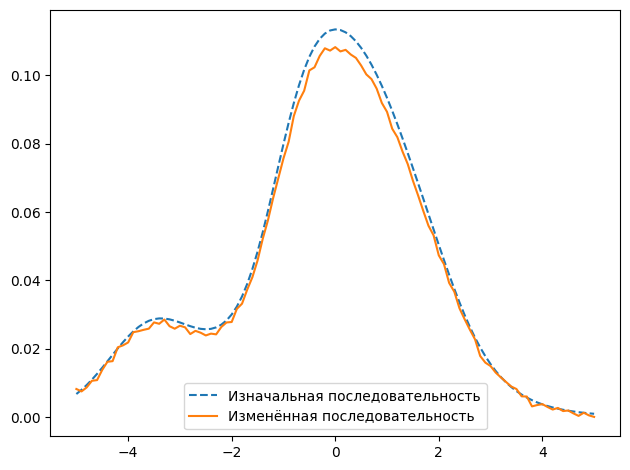

In [80]:
import matplotlib.pyplot as plt

i = 23
X = X = torch.arange(-5.0, 5.1, 0.1)  
plt.plot(X, S[i], label="Изначальная последовательность", linestyle='--')
plt.plot(X, augment_spectrum_noise_and_sharpen(S)[i], label="Изменённая последовательность")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
from utils import save_model_with_architecture
model = SpectralParamTwoTowerBalanced().to('cuda')
# model = SpectralParamTwoTowerBalancedV2().to('cuda')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10, verbose=True
)
best_gap = -1
N_EPOCHS = 200
criterion = SpectrumParamContrastiveLoss(margin=0.2)
# criterion = BalancedContrastiveLossV3()
# criterion = BalancedSpectrumParamLoss()
# criterion = nn.TripletMarginLoss()

# criterion = TripletLoss(margin=0.2)   # можно подобрать 0.1–0.3



for epoch in range(N_EPOCHS):
    model.train()
    train_loss = 0.0
    for S_batch, a_batch, b_batch in train_loader:
        S = S_batch.to('cuda')
        S = augment_spectrum_noise_and_sharpen(S)
        a, b = a_batch.to('cuda'), b_batch.to('cuda')
        a, b = augment_scaled_parameters(a, b, _scaler, 
                                                        rel_noise=0.2, mode='gaussian')
        # Генерируем негативные пары (перемешивание)
        a_neg, b_neg = make_hard_negative_pairs_soft_tradeoff(a, b, n_bins=8)

        optimizer.zero_grad()

        # Прямой проход: один и тот же спектр, разные параметры
        z_spec, z_param_pos, z_a_pos, z_b_pos = model(S, a, b)
        _, z_param_neg, z_a_neg, z_b_neg = model(S, a_neg, b_neg)
        # loss = criterion(z_spec, z_param_pos, z_param_neg)
        loss = criterion(z_spec, z_param_pos, z_param_neg )

        # loss = criterion(z_spec, z_param_pos, z_param_neg)
        # loss = info_nce_with_negatives(z_spec, z_param_pos, z_param_neg, temperature=0.07)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Валидация (можно использовать тот же triplet или gap)
    model.eval()
    val_metrics = validate_with_negatives(model, val_loader, 'cuda')
    scheduler.step(val_metrics['gap'])

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
          f"Sim⁺: {val_metrics['sim_pos']:.4f} | Sim⁻: {val_metrics['sim_neg']:.4f} | "
          f"Gap: {val_metrics['gap']:.4f} | AUC: {val_metrics['auc']:.4f}")

    if val_metrics['gap'] > best_gap and val_metrics['gap']>0.25:
        best_gap = val_metrics['gap']
        save_model_with_architecture(model, f"best_voigt_reconstructor_{epoch}.pkl")
        print(f"✅ сохранена модель с параметрами Sim⁺: {val_metrics['sim_pos']:.4f} | Sim⁻: {val_metrics['sim_neg']:.4f} | "
          f"Gap: {val_metrics['gap']:.4f} | AUC: {val_metrics['auc']:.4f} в файл best_voigt_reconstructor_{epoch}.pkl")


/home/kirill/diploma/venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 000 | Train Loss: 1.0006 | Sim⁺: -0.0041 | Sim⁻: -0.0236 | Gap: 0.0194 | AUC: 0.5367
Epoch 001 | Train Loss: 1.0110 | Sim⁺: -0.0978 | Sim⁻: -0.0948 | Gap: -0.0031 | AUC: 0.5017
Epoch 002 | Train Loss: 1.0058 | Sim⁺: -0.1423 | Sim⁻: -0.1450 | Gap: 0.0027 | AUC: 0.5041
Epoch 003 | Train Loss: 1.0064 | Sim⁺: -0.1248 | Sim⁻: -0.1355 | Gap: 0.0107 | AUC: 0.5152
Epoch 004 | Train Loss: 1.0007 | Sim⁺: -0.0417 | Sim⁻: -0.0359 | Gap: -0.0058 | AUC: 0.4915
Epoch 005 | Train Loss: 0.9979 | Sim⁺: 0.0101 | Sim⁻: 0.0073 | Gap: 0.0028 | AUC: 0.5078
Epoch 006 | Train Loss: 0.9873 | Sim⁺: -0.0160 | Sim⁻: -0.0192 | Gap: 0.0032 | AUC: 0.5050
Epoch 007 | Train Loss: 0.9925 | Sim⁺: -0.0201 | Sim⁻: 0.0218 | Gap: -0.0420 | AUC: 0.4544
Epoch 008 | Train Loss: 0.9905 | Sim⁺: 0.0402 | Sim⁻: 0.0515 | Gap: -0.0114 | AUC: 0.4729
Epoch 009 | Train Loss: 0.9782 | Sim⁺: 0.1593 | Sim⁻: 0.1575 | Gap: 0.0018 | AUC: 0.5028
Epoch 010 | Train Loss: 0.9099 | Sim⁺: 0.1250 | Sim⁻: 0.1242 | Gap: 0.0008 | AUC: 0.5028
Epoc

## Инференс итогового алгоритма

In [ ]:
from utils import load_model_with_architecture

model_He = load_model_with_architecture('')
model_scoring = load_model_with_architecture('/home/kirill/diploma/best_voigt_reconstructor_.pkl')


✅ Модель со всей архитектурой загружена из /home/kirill/diploma/best_voigt_reconstructor_.pkl


In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy  as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
def read_txt_to_dataframe_v2(file_path, column_names=None):
    """
    Альтернативная версия с использованием read_csv и регулярного выражения
    """
    
    if column_names is None:
        column_names = ['VV', 'FullAbs', 'CI']
    elif len(column_names) != 3:
        raise ValueError("Должно быть ровно 3 имени столбцов")
    
    try:
        # Используем регулярное выражение для разделителя: 
        # пробел или табуляция, один или более раз
        df = pd.read_csv(
            file_path,
            sep=r'[ \t]+',  # регулярное выражение для пробелов и табуляций
            header=None,
            names=column_names,
            engine='python',  # python engine поддерживает regex разделители
            encoding='utf-8',
            skip_blank_lines=True
        )
        
        # Очистка строковых значений
        if df['CI'].isna().all(): df['CI'] = df['CI'].fillna(0)
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].str.strip()
        
        # print(f"Файл успешно прочитан")
        # print(f"Размер DataFrame: {df.shape}")
        
        return df
        
    except Exception as e:
        raise Exception(f"Ошибка при чтении файла: {e}")
    
def get_real_observations(path_to_folder:str | Path):
    path_to_folder = Path(path_to_folder)
    answer = {}
    for file in list(path_to_folder.rglob("*.txt")): 
        df_Wasp52 = read_txt_to_dataframe_v2(str(file))
        print(file)
        # Удаляем строки с NaN (если были ошибки преобразования)
        df_Wasp52_clean = df_Wasp52.dropna()

        df_Wasp52_clean["VV"] = (
            df_Wasp52_clean["VV"]
            .astype(str)                      # гарантируем строковый тип
            .str.replace(',', '.')            # заменяем запятые на точки
            .str.replace(' ', '')             # удаляем пробелы если есть
        )
        df_Wasp52_clean["FullAbs"] = (
            df_Wasp52_clean["FullAbs"]
            .astype(str)                      # гарантируем строковый тип
            .str.replace(',', '.')            # заменяем запятые на точки
            .str.replace(' ', '')             # удаляем пробелы если есть
        )
        # Теперь можно преобразовывать в numpy float32
        VV = df_Wasp52_clean["VV"].to_numpy(np.float32)
        X = df_Wasp52_clean["FullAbs"].to_numpy(np.float32)
        pname = Path(file).stem
        if pname!="Wasp-121b":
            X /= 100
        VV /= 10.07
        
        # Исходные данные (возрастающие x)
        x_orig = VV
        y_orig = X   # последний отрезок резко вверх

        # Запросы: внутри и вне диапазона
        x_query = np.linspace(-5,5,101)
        
        # --- Вариант 1: линейная интерполяция с экстраполяцией по последнему отрезку ---
        f_linear_ext = interp1d(x_orig, y_orig,
                                kind='linear',
                                fill_value='extrapolate')   # ключевой параметр
    
        # print(df_Wasp52)
        y_linear_ext = f_linear_ext(x_query)

        

        # --- Вариант 2: более безопасная экстраполяция (постоянные значения на краях) ---
        f_const_ext = interp1d(x_orig, y_orig,
                            kind='linear',
                            fill_value=(y_orig[0], y_orig[-1]),   # задать явно
                            bounds_error=False)

        y_const_ext = f_const_ext(x_query)
        answer[pname] = {
            "V_orig":VV,
            "FullAbs_orig":X,
            "V_interp":x_query,
            "FullAbs_interp":y_const_ext
        }
    return answer

answer = get_real_observations("real_observations")
# import seaborn as sns
# plt.figure(figsize=(10, 6))

# sns.lineplot(x=VV, y=X, label='Wasp-52b', color='blue', linewidth=2)
# # sns.lineplot(x=range(len(val_losses)), y=val_losses, label='val', color='red', linewidth=2)

# plt.title('Профиль поглощения Wasp52b)')
# plt.xlabel('V')
# plt.ylabel('abs')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


real_observations/HD189733b_B.txt
real_observations/HD209458.txt
real_observations/HD189733b_A.txt
real_observations/Wasp-52b.txt
real_observations/Wasp-107b.txt
real_observations/Wasp-121b.txt
real_observations/Wasp-69b_A.txt
real_observations/Hat-P-32b.txt
real_observations/Wasp-69b_B.txt


/tmp/ipykernel_1932954/3640314896.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Wasp52_clean["VV"] = (
/tmp/ipykernel_1932954/3640314896.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Wasp52_clean["FullAbs"] = (


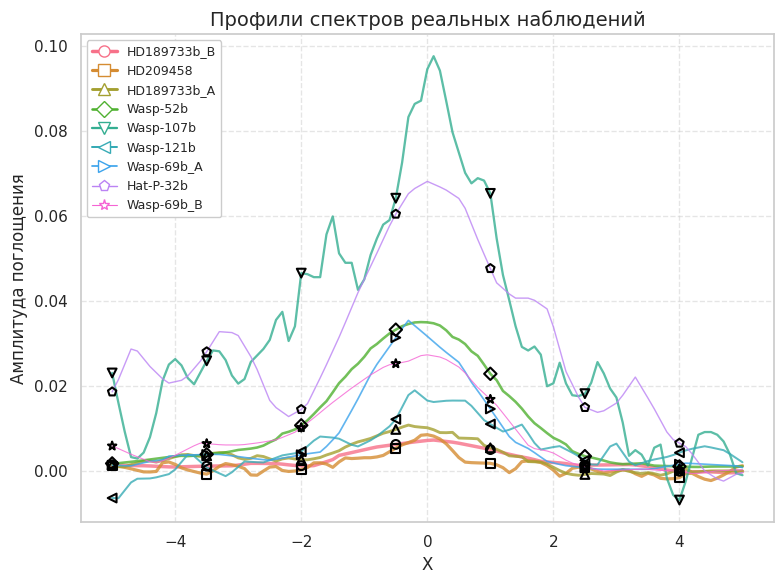

In [12]:
param_names = []
x_data = []
y_data = []
import seaborn as sns
from matplotlib.lines import Line2D

for planet_name, planet_dict in answer.items() :
    # x = np.linspace(-5, 5, 101)  # общий X (замените на ваши реальные x, если они разные)
    y = planet_dict['FullAbs_interp']    # ваши данные
    x = planet_dict['V_interp']
    x_data.append(x)
    y_data.append(y)
    param_names.append(str(planet_name))
    

# ============================================================
# 2. НАСТРОЙКИ
# ============================================================
num_curves = len(answer)
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*'][:num_curves]
linewidths = np.linspace(2.5, 0.8, num_curves)
colors = sns.color_palette("husl", num_curves)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# ============================================================
# 3. РИСУЕМ ГРАФИКИ
# ============================================================
legend_elements = []  # для сбора объектов легенды

for i in range(num_curves):
    x = x_data[i]
    y = y_data[i]
    marker = markers[i%len(markers)]
    lw = linewidths[i%len(linewidths)]
    color = colors[i%len(colors)]
    # Основная линия
    try:
        plt.plot(x, y, color=color, linewidth=lw, alpha=0.8)
    except Exception as e:
        continue
    # Маркеры с шагом
    step = 15
    indices = np.arange(0, len(x), step)
    plt.scatter(x[indices], y[indices], marker=marker, s=40,
                facecolors='none', edgecolors='black', linewidths=1.5, zorder=5)
    
    # Добавляем элемент в легенду (линия + маркер)
    legend_elements.append(
        Line2D([0], [0], marker=marker, color=color, linewidth=lw,
               linestyle='-', markersize=8, markerfacecolor='white',
               label=param_names[i])
    )

# plt.plot(x_query, y_const_ext, color="blue")
# legend_elements.append(
#         Line2D([0], [0], color='blue',
#                linestyle='-', markersize=8,
#                label="Hat-P-32b (Czesla et al 2021)")
#     )
# ============================================================
# 4. ЛЕГЕНДА И ОФОРМЛЕНИЕ
# ============================================================
plt.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=1)

plt.xlabel("X", fontsize=12)
plt.ylabel("Амплитуда поглощения", fontsize=12)
plt.title("Профили спектров реальных наблюдений", fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [48]:
print(f"x_orig shape: {x_orig.shape if hasattr(x_orig, 'shape') else len(x_orig)}")
print(f"y_orig shape: {y_orig.shape if hasattr(y_orig, 'shape') else len(y_orig)}")
print(f"x_query shape: {x_query.shape if hasattr(x_query, 'shape') else len(x_query)}")
print(f"Unique x_orig: {np.unique(x_orig).size}")

x_orig shape: (41,)
y_orig shape: (41,)
x_query shape: (101,)
Unique x_orig: 40


=== Линейная экстраполяция ===
x = -5.0 → y =     0.0194
x = -4.9 → y =     0.0227
x = -4.8 → y =     0.0263
x = -4.7 → y =     0.0295
x = -4.6 → y =     0.0277
x = -4.5 → y =     0.0258
x = -4.4 → y =     0.0242
x = -4.3 → y =     0.0227
x = -4.2 → y =     0.0213
x = -4.1 → y =     0.0208
x = -4.0 → y =     0.0211
x = -3.9 → y =     0.0214
x = -3.8 → y =     0.0228
x = -3.7 → y =     0.0246
x = -3.6 → y =     0.0263
x = -3.5 → y =     0.0286
x = -3.4 → y =     0.0310
x = -3.3 → y =     0.0328
x = -3.2 → y =     0.0327
x = -3.1 → y =     0.0326
x = -3.0 → y =     0.0314
x = -2.9 → y =     0.0289
x = -2.8 → y =     0.0265
x = -2.7 → y =     0.0232
x = -2.6 → y =     0.0196
x = -2.5 → y =     0.0160
x = -2.4 → y =     0.0147
x = -2.3 → y =     0.0137
x = -2.2 → y =     0.0129
x = -2.1 → y =     0.0138
x = -2.0 → y =     0.0146
x = -1.9 → y =     0.0163
x = -1.8 → y =     0.0193
x = -1.7 → y =     0.0222
x = -1.6 → y =     0.0254
x = -1.5 → y =     0.0286
x = -1.4 → y =     0.0318
x = -1.

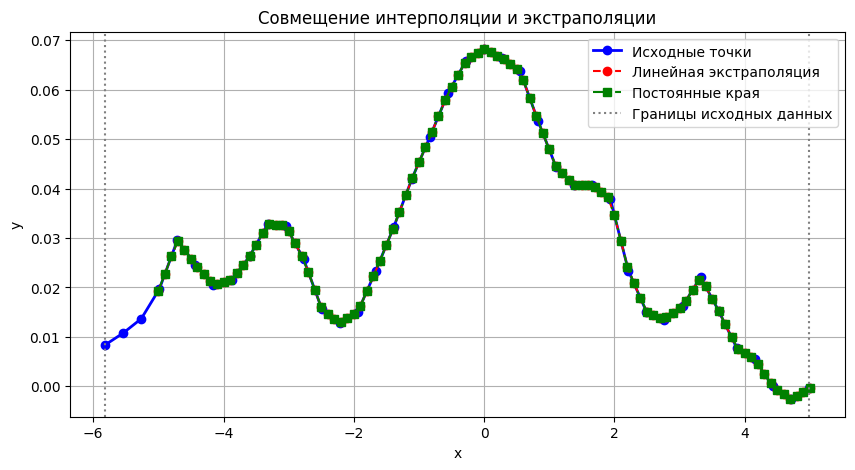

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Исходные данные (возрастающие x)
x_orig = VV
y_orig = X   # последний отрезок резко вверх

# Запросы: внутри и вне диапазона
x_query = np.linspace(-5,5,101)

# --- Вариант 1: линейная интерполяция с экстраполяцией по последнему отрезку ---
f_linear_ext = interp1d(x_orig, y_orig,
                        kind='linear',
                        fill_value='extrapolate')   # ключевой параметр

y_linear_ext = f_linear_ext(x_query)

print("=== Линейная экстраполяция ===")
for x, y in zip(x_query, y_linear_ext):
    print(f"x = {x:4.1f} → y = {y:10.4f}")

# --- Вариант 2: более безопасная экстраполяция (постоянные значения на краях) ---
f_const_ext = interp1d(x_orig, y_orig,
                       kind='linear',
                       fill_value=(y_orig[0], y_orig[-1]),   # задать явно
                       bounds_error=False)

y_const_ext = f_const_ext(x_query)

print("\n=== Экстраполяция постоянными крайними значениями ===")
for x, y in zip(x_query, y_const_ext):
    print(f"x = {x:4.1f} → y = {y:10.4f}")

# --- График ---
plt.figure(figsize=(10, 5))
plt.plot(x_orig, y_orig, 'bo-', label='Исходные точки', linewidth=2)

plt.plot(x_query, y_linear_ext, 'ro--', label='Линейная экстраполяция', markersize=6)
plt.plot(x_query, y_const_ext, 'gs-.', label='Постоянные края', markersize=6)

plt.axvline(x_orig[0], color='gray', linestyle=':', label='Границы исходных данных')
plt.axvline(x_orig[-1], color='gray', linestyle=':')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.title('Совмещение интерполяции и экстраполяции')
plt.show()

/tmp/ipykernel_2602837/2444030922.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


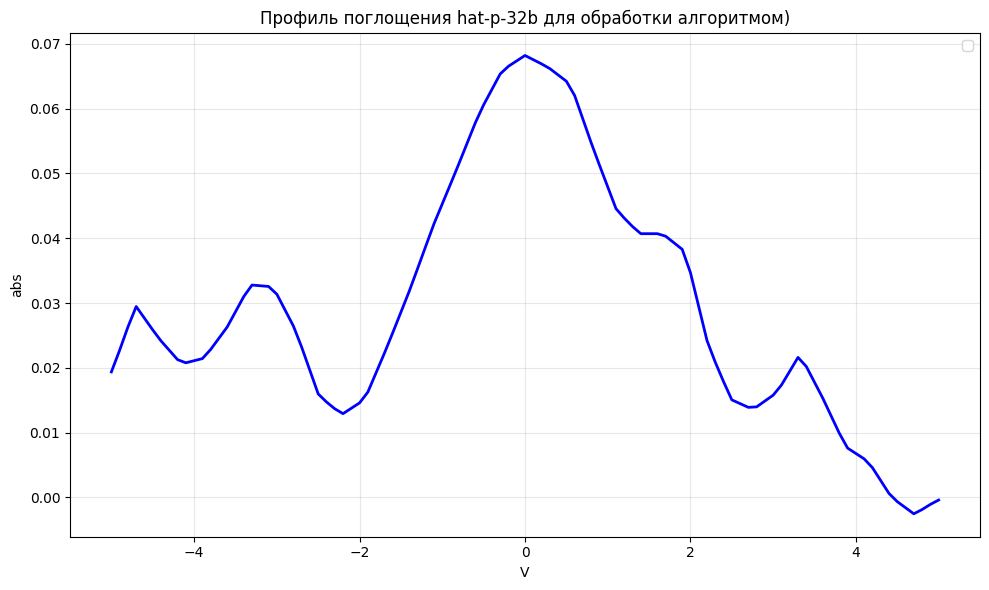

In [11]:
plt.figure(figsize=(10, 6))

sns.lineplot(x=x_query, y=y_const_ext, label='', color='blue', linewidth=2)
# sns.lineplot(x=range(len(val_losses)), y=val_losses, label='val', color='red', linewidth=2)

plt.title('Профиль поглощения hat-p-32b для обработки алгоритмом)')
plt.xlabel('V')
plt.ylabel('abs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [201]:
import torch
import numpy as np
from typing import Tuple, Union
import torch
import torch.nn as nn
import torch.nn.functional as F
def normalize_spectrum(S, method='area'):
    """
    S: (B, 101) или (101,)
    method: 'area' (интеграл=1) или 'max' (амплитуда=1)
    """
    if method == 'area':
        return S / (torch.sum(torch.abs(S), dim=-1, keepdim=True) + 1e-8)
    elif method == 'max':
        return S / (torch.max(torch.abs(S), dim=-1, keepdim=True).values + 1e-8)
    return S

def get_validation_calibrated_top5(scores, threshold=0.8, n=5):
    """
    Простой вариант: penalize за отклонение от медианы валидации.
    Предпочитает scores, похожие на те, что модель реально выдаёт на валидации.
    """
    val_median = threshold
    
    calibrated_scores = {}
    for score, params in scores.items():
        # Близость к медиане валидации — это хорошо
        # Отклонение вверх (переобучение) штрафуется сильнее, чем вниз
        if score > val_median:
            penalty = (score - val_median) * 2.0  # сильный штраф за переобучение
        else:
            penalty = (val_median - score) * 0.5  # слабый штраф за недообучение
        
        calibrated = score - penalty
        calibrated_scores[calibrated] = params
    
    sorted_calibrated = sorted(calibrated_scores.items(), key=lambda x: x[0], reverse=True)
    return sorted_calibrated[:n], calibrated_scores

def compute_pair_score(model, spectrum, param_a, param_b, device=None):
    """
    Вычисляет cosine similarity между эмбеддингами спектра и параметров.
    
    Args:
        model: SpectralParamTwoTower
        spectrum: torch.Tensor [seq_len] или [1, seq_len]
        param_a, param_b: float или torch.Tensor [1]
    
    Returns:
        score: float
    """
    if device is None:
        device = next(model.parameters()).device
    model.to(device)
    model.eval()
    
    if isinstance(spectrum, np.ndarray):
        spectrum = torch.from_numpy(spectrum).float()
    if isinstance(param_a, np.ndarray):
        param_a = torch.from_numpy(param_a).float()
    if isinstance(param_b, np.ndarray):
        param_b = torch.from_numpy(param_b).float()
    # Подготовка спектра
    if spectrum.ndim == 1:
        spectrum = spectrum.unsqueeze(0)  # [1, seq_len]
    spectrum = normalize_spectrum(spectrum).to(device)
    # Подготовка параметров
    if isinstance(param_a, (float, int)):
        param_a = torch.tensor([param_a], device=device)
    if isinstance(param_b, (float, int)):
        param_b = torch.tensor([param_b], device=device)
    
    # Инференс + cosine similarity
    with torch.no_grad():
        z_spec, z_param, _, _ = model(spectrum, param_a, param_b)
        z_spec = F.normalize(z_spec, p=2, dim=-1)
        z_param = F.normalize(z_param, p=2, dim=-1)
        score = F.cosine_similarity(z_spec, z_param).item()
    
    return score

def run_chronos_multimodal_inference(
    model: torch.nn.Module,
    scaler,
    spectra: Union[np.ndarray, torch.Tensor],
    device: str = None,
    return_conf: bool = True
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Инференс MultiHeadChronosRegressor.
    Возвращает предсказания и оценки уверенности для ВСЕХ голов.
    
    Args:
        model: модель в режиме eval()
        scaler: обученный StandardScaler для денормализации предсказаний
        spectra: np.array или torch.Tensor формы [batch, seq_len] или [seq_len]
        device: 'cuda'/'cpu'. Если None, берётся из весов модели
        return_conf: если False, возвращает только preds
        
    Returns:
        preds: torch.Tensor [batch, num_heads, output_dim] (денормализованные)
        confs: torch.Tensor [batch, num_heads] (если return_conf=True)
    """
    if device is None:
        device = next(model.parameters()).device
        if device == torch.device('cpu') and torch.cuda.is_available():
            device = 'cuda'
    
    # Переносим модель на нужное устройство
    model = model.to(device)
    
    # ВАЖНО: Сохраняем ссылку на токенизатор и его boundaries
    tokenizer = None
    original_boundaries = None
    if hasattr(model, 'tokenizer'):
        tokenizer = model.tokenizer
        if hasattr(tokenizer, 'boundaries'):
            original_boundaries = tokenizer.boundaries
            # Убеждаемся, что boundaries на CPU
            tokenizer.boundaries = original_boundaries.cpu()
    
    # 1. Нормализация входа
    if isinstance(spectra, np.ndarray):
        spectra = torch.from_numpy(spectra).float()
    if spectra.ndim == 1:
        spectra = spectra.unsqueeze(0)  # [1, seq_len]
        
    # 2. Перенос на устройство модели
    spectra = spectra.to(device)
    
    # 3. Инференс
    model.eval()
    with torch.no_grad():
        preds, confs = model(spectra, return_all=True, return_conf=return_conf)
    
    # Восстанавливаем boundaries после инференса (на всякий случай)
    if original_boundaries is not None:
        tokenizer.boundaries = original_boundaries
        
    # 4. Возврат на CPU и денормализация
    preds = preds.cpu()
    if confs is not None:
        confs = confs.cpu()
    
    # Денормализация preds
    batch_size, num_heads, output_dim = preds.shape
    preds_flat = preds.reshape(-1, output_dim).numpy()  # [batch * num_heads, output_dim]
    preds_flat_denorm = scaler.inverse_transform(preds_flat)
    preds_denorm = torch.from_numpy(preds_flat_denorm).reshape(batch_size, num_heads, output_dim).float()
    
    return preds, preds_denorm

### шаг 1 - Инициализация скалеров и моделей 

In [236]:
from utils import load_model_with_architecture
import pickle

# загружаем скалеры для инференса
with open('inference_ready_weights_all_planets/scaler_xuv.pkl', 'rb') as f:
    scaler_xuv = pickle.load(f)
with open('inference_ready_weights_all_planets/scaler_he.pkl', 'rb') as f:
    scaler_he = pickle.load(f)
with open('inference_ready_weights_all_planets/scaler_msw.pkl', 'rb') as f:
    scaler_msw = pickle.load(f)
# загружаем модели для параметрического определения
model_xuv = load_model_with_architecture("inference_ready_weights_all_planets/best_xuv_all_planets.pkl")
model_he = load_model_with_architecture("inference_ready_weights_all_planets/best_helium_hard_conv.pkl")
model_msw = load_model_with_architecture("inference_ready_weights_all_planets/best_msw_all_planet.pkl")
# TODO сохранить xgboost для H2a

# скоринговая модель
# хорошо работает на посчитаных планетах
# model_scoring = load_model_with_architecture("best_voigt_reconstructor_101.pkl")
model_scoring = load_model_with_architecture("best_voigt_reconstructor_bal1.pkl")



✅ Модель со всей архитектурой загружена из inference_ready_weights_all_planets/best_xuv_all_planets.pkl
✅ Модель со всей архитектурой загружена из inference_ready_weights_all_planets/best_helium_hard_conv.pkl
✅ Модель со всей архитектурой загружена из inference_ready_weights_all_planets/best_msw_all_planet.pkl
✅ Модель со всей архитектурой загружена из best_voigt_reconstructor_bal1.pkl


In [237]:
def get_xuv_and_he_prediction(spectra, model_xuv, scaler_xuv, model_he, scaler_he, model_scoring):
    y_const_ext = spectra
    xuv_candidates, xuv_candidates_denormalized = run_chronos_multimodal_inference(model=model_xuv,
                                    scaler=scaler_xuv,
                                    spectra=y_const_ext,
                                    device='cpu')

    he_candidates, he_candidates_denormalized = run_chronos_multimodal_inference(model=model_he,
                                    scaler=scaler_he,
                                    spectra=y_const_ext,
                                    device='cpu')

    grid_i, grid_j = torch.meshgrid(torch.arange(len(xuv_candidates.squeeze(0))), torch.arange(len(he_candidates.squeeze(0))), indexing='ij')

    # Индексируем тензоры по сетке

    combinations = torch.stack([he_candidates.squeeze(0)[grid_i.flatten()], xuv_candidates.squeeze(0)[grid_j.flatten()]], dim=1)
    # combinations.shape
    scores = {}
    for pair in combinations:
        score = compute_pair_score(model_scoring, y_const_ext, pair[0], pair[1], device='cpu')
        ans = []
        for pred, scaler in zip((pair[0], pair[1]), (scaler_he, scaler_xuv)):
            
            preds_flat = pred.reshape(-1, 1).numpy()  # [batch * num_heads, output_dim]
            preds_flat_denorm = scaler.inverse_transform(preds_flat)
            # preds_denorm = torch.from_numpy(preds_flat_denorm).float()
            ans.append(preds_flat_denorm[0][0])
        scores[score] = ans
        # print(ans, score)

    # sorted_items, calibrated_scores = get_validation_calibrated_top5(scores,0.85)
    sorted_items = sorted(scores.items(), key=lambda x: x[0], reverse=True)
    top5 = sorted_items[:5]
    

    # for score, params in top5:
    #     print(f"Score: {score:.4f}, Params: He/H={params[0]:.6f}, XUVInt={params[1]:.6f}")
    return top5, scores

In [238]:
sdasd = {}
for pname, p_info in answer.items():
    top5, scores = get_xuv_and_he_prediction(p_info['FullAbs_interp'], model_xuv, scaler_xuv, model_he, scaler_he, model_scoring)
    print(f"========================== Planet - {pname} ============================")
    print(" ")
    print(" ")
    for score, params in top5:
        print(f"Score: {score:.4f}, Params: He/H={params[0]:.6f}, XUVInt={params[1]:.6f}")
    # print(scores)
    sdasd[pname] = scores
    print(" ")
    print(" ")
    

========================== Planet - HD189733b_B ============================
 
 
Score: 0.9839, Params: He/H=0.011218, XUVInt=20.442768
Score: 0.9703, Params: He/H=0.011218, XUVInt=28.343458
Score: 0.9396, Params: He/H=0.030397, XUVInt=20.442768
Score: 0.9297, Params: He/H=0.011218, XUVInt=37.780037
Score: 0.9222, Params: He/H=0.011218, XUVInt=45.146130
 
 
========================== Planet - HD209458 ============================
 
 
Score: 0.9833, Params: He/H=0.011276, XUVInt=1.610689
Score: 0.9544, Params: He/H=0.029800, XUVInt=1.610689
Score: 0.9412, Params: He/H=0.011276, XUVInt=10.002524
Score: 0.8636, Params: He/H=0.053851, XUVInt=1.610689
Score: 0.8635, Params: He/H=0.029800, XUVInt=10.002524
 
 
========================== Planet - HD189733b_A ============================
 
 
Score: 0.9068, Params: He/H=0.199030, XUVInt=22.547380
Score: 0.8926, Params: He/H=0.199030, XUVInt=32.059273
Score: 0.8573, Params: He/H=0.199030, XUVInt=44.065674
Score: 0.7715, Params: He/H=0.199030, XU

In [200]:
sdasd["Hat-P-32b"]

{-0.7684262990951538: [0.016452588, 12.273355],
 -0.8580865263938904: [0.016452588, 38.813828],
 -0.8434881567955017: [0.016452588, 31.249414],
 -0.7904583215713501: [0.016452588, 22.306261],
 -0.8237273097038269: [0.016452588, 46.924553],
 0.5258869528770447: [0.105082564, 12.273355],
 0.7175394296646118: [0.105082564, 38.813828],
 0.7047113180160522: [0.105082564, 31.249414],
 0.6303604245185852: [0.105082564, 22.306261],
 0.6786977052688599: [0.105082564, 46.924553],
 -0.1244078129529953: [0.05766046, 12.273355],
 0.29258066415786743: [0.05766046, 38.813828],
 0.255326509475708: [0.05766046, 31.249414],
 0.11961625516414642: [0.05766046, 22.306261],
 0.25140380859375: [0.05766046, 46.924553],
 0.8913927674293518: [0.2103526, 12.273355],
 0.9091421365737915: [0.2103526, 38.813828],
 0.9131323099136353: [0.2103526, 31.249414],
 0.9006004333496094: [0.2103526, 22.306261],
 0.8897534608840942: [0.2103526, 46.924553],
 -0.4238831698894501: [0.042529378, 12.273355],
 -0.12894432246685028:

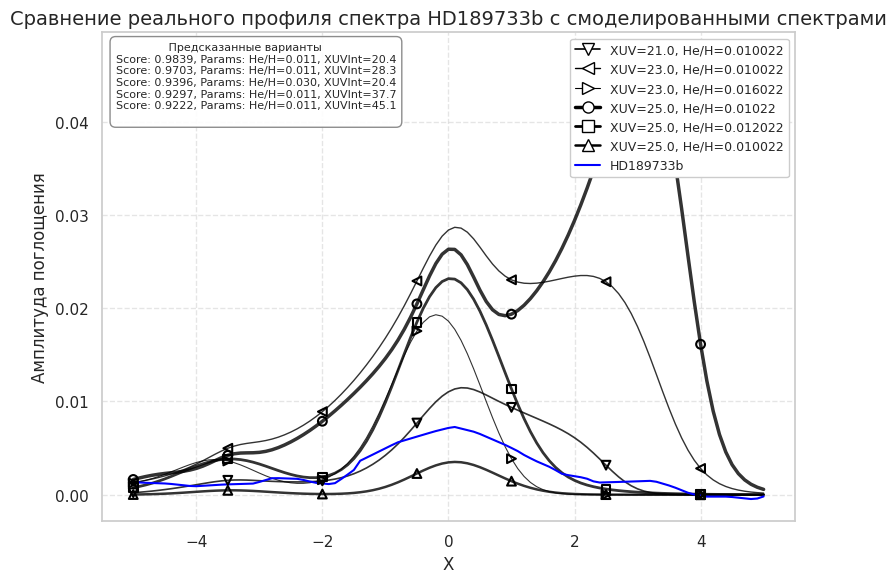

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
dataset = df
need_dataset = dataset[(dataset["Helium"]>0.01) & (dataset["Helium"] <0.02) & (((dataset["XUVInt"] >=20 ) & (dataset["XUVInt"] < 30)) | ((dataset["XUVInt"] > 20) & (dataset["XUVInt"] < 30)) )]
# ============================================================
# 1. ВАШИ ДАННЫЕ (замените на реальные)
# ============================================================
# Предполагается, что df уже загружен и содержит нужные колонки

x_data = []
y_data = []

for j in list(need_dataset.index):
    # x = np.linspace(-5, 5, 101)  # общий X (замените на ваши реальные x, если они разные)
    y = need_dataset["spectrum"][j]    # ваши данные
    x = np.linspace(-5,5,len(y))
    x_data.append(x)
    y_data.append(y)

param_names = [
    f"XUV={need_dataset['XUVInt'][i]}, He/H={need_dataset['Helium'][i]}"
    for i in list(need_dataset.index)
]

# ============================================================
# 2. НАСТРОЙКИ
# ============================================================
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linewidths = [2.5, 2.0, 1.8, 1.5, 1.2, 1.0, 0.8]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# ============================================================
# 3. РИСУЕМ ГРАФИКИ
# ============================================================
legend_elements = []  # для сбора объектов легенды

for i in range(4,10):
    x = x_data[i]
    y = y_data[i]
    marker = markers[i%len(markers)]
    lw = linewidths[i%len(linewidths)]
    
    # Основная линия
    try:
        plt.plot(x, y, color='black', linewidth=lw, alpha=0.8)
    except Exception as e:
        continue
    # Маркеры с шагом
    step = 15
    indices = np.arange(0, len(x), step)
    plt.scatter(x[indices], y[indices], marker=marker, s=40,
                facecolors='none', edgecolors='black', linewidths=1.5, zorder=5)
    
    # Добавляем элемент в легенду (линия + маркер)
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='black', linewidth=lw,
               linestyle='-', markersize=8, markerfacecolor='white',
               label=param_names[i])
    )

plt.plot(answer['HD189733b_B']['V_interp'],answer['HD189733b_B']['FullAbs_interp'], color="blue")
legend_elements.append(
        Line2D([0], [0], color='blue',
               linestyle='-', markersize=8,
               label="HD189733b")
    )

predictions_text =( "               Предсказанные варианты\n"
                   "Score: 0.9839, Params: He/H=0.011, XUVInt=20.4\n"
                    "Score: 0.9703, Params: He/H=0.011, XUVInt=28.3\n"
                    "Score: 0.9396, Params: He/H=0.030, XUVInt=20.4\n"
                    "Score: 0.9297, Params: He/H=0.011, XUVInt=37.7\n"
                    "Score: 0.9222, Params: He/H=0.011, XUVInt=45.1\n"
                    )

plt.text(
    0.02, 0.98,                    # позиция (относительные координаты: 0-1)
    predictions_text,              # текст
    transform=plt.gca().transAxes, # относительные координаты осей
    fontsize=8,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)
# ============================================================
# 4. ЛЕГЕНДА И ОФОРМЛЕНИЕ
# ============================================================
plt.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=1)

plt.xlabel("X", fontsize=12)
plt.ylabel("Амплитуда поглощения", fontsize=12)
plt.title("Сравнение реального профиля спектра HD189733b с смоделированными спектрами", fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [294]:
need_dataset

,spectrum,Helium,XUVInt,spectrum_fixed
145,"[0.00345208, 0.00388153, 0.00431815, 0.0047557...",0.010022,21.0,"[0.00345208, 0.00388153, 0.00431815, 0.0047557..."
147,"[0.00446793, 0.00506488, 0.00567732, 0.0062948...",0.013022,21.0,"[0.00446793, 0.00506488, 0.00567732, 0.0062948..."
148,"[0.00109291, 0.00126789, 0.00147995, 0.0017319...",0.018022,21.0,"[0.00109291, 0.00126789, 0.00147995, 0.0017319..."
150,"[0.00228578, 0.00256206, 0.00286419, 0.0031888...",0.017022,21.0,"[0.00228578, 0.00256206, 0.00286419, 0.0031888..."
162,"[0.00022124, 0.000270939, 0.000329149, 0.00039...",0.010022,21.0,"[0.00022124, 0.000270939, 0.000329149, 0.00039..."
167,"[0.00129814, 0.00141661, 0.00154591, 0.0016878...",0.010022,23.0,"[0.00129814, 0.00141661, 0.00154591, 0.0016878..."
185,"[0.00126682, 0.00139458, 0.0015509, 0.00173687...",0.016022,23.0,"[0.00126682, 0.00139458, 0.0015509, 0.00173687..."
194,"[0.00163845, 0.00180537, 0.00195733, 0.0020884...",0.010220,25.0,"[0.00163845, 0.00180537, 0.00195733, 0.0020884..."
196,"[0.000762163, 0.00089454, 0.00105378, 0.001241...",0.012022,25.0,"[0.000762163, 0.00089454, 0.00105378, 0.001241..."
199,"[2.49493e-05, 3.48439e-05, 4.80558e-05, 6.5266...",0.010022,25.0,"[2.49493e-05, 3.48439e-05, 4.80558e-05, 6.5266..."


In [48]:
type(model_xuv)

__main__.MultiHeadChronosRegressor

# По очереди прогоняем моедели регрессоры